# Week-25

ecosystem_palette = {
    "Lakes": "#00A6D6",                    # bright cyan-blue
    "Streams": "#006D2C",                  # dark forest green
    "Marine": "#08306B",                   # deep navy
    "Terrestrial aboveground": "#7AC943",  # bright leaf green
    "Terrestrial belowground": "#6B3A19",  # dark soil brown
}

metric_palette = {
    "ROC-AUC": "#7B3294",   # purple
    "PR-AUC": "#C51B7D",    # magenta
    "F1": "#E6AB02",        # mustard
    "MCC": "#B2182B",       # deep red / burgundy
    "Precision": "#FE6100", # orange
    "Recall": "#CAB2D6",    # violet
    "TSS": "#666666",       # dark gray
    "TPR": "#1B9E77",       # teal-green
}

version_palette = {
    "Original": "#bab6f2",
    "Directed": "#6edeed",
    "Directed-Negative": "#1f78b4",
}

network_type_palette = {
    "Empirical": "#3A7D44",
    "Pseudo": "#C6923A",
}

Using LOG_DIR: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_kfold_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs
Found 870 CSV files matching pattern: *tax_mass_results_random_wlnm_dir_neg_kfold*.csv

df_runs shape:
(104400, 11)

Foodweb count per CvK:
CvK
3     290
5     290
10    290
Name: Foodweb, dtype: int64

Validation-row count per CvK:
CvK
3     17400
5     29000
10    58000
dtype: int64

Expected validation-row count per CvK:
290 food webs x 20 repetitions = 5800

Repeated-validation count per food web and CvK:
     count   mean  std    min    25%    50%    75%    max
CvK                                                      
3    290.0   60.0  0.0   60.0   60.0   60.0   60.0   60.0
5    290.0  100.0  0.0  100.0  100.0  100.0  100.0  100.0
10   290.0  200.0  0.0  200.0  200.0  200.0  200.0  200.0

[CHECK] CvK=3: found 17400 rows, expected 5800. This may indicate missing food webs, fewer/more repetitions, or that each

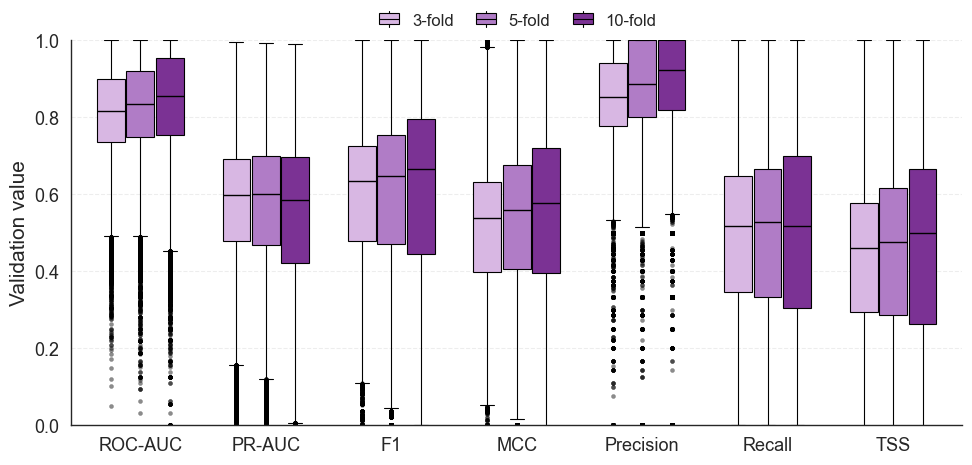

In [35]:
import glob
import re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase
from matplotlib.ticker import MaxNLocator

sns.set_context("paper", font_scale=1.15)
sns.set_style("white")

# -----------------------------
# Config
# -----------------------------
LOG_DIR_REL = Path(
    "src/matlab/data/result_wlnm_dir_neg_kfold_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs"
)

PATTERN = "*tax_mass_results_random_wlnm_dir_neg_kfold*.csv"

K_TARGET = 10
cvk_order = [3, 5, 10]

EXPECTED_FOODWEBS = 290
EXPECTED_REPEATS = 20
EXPECTED_POINTS_PER_CVK = EXPECTED_FOODWEBS * EXPECTED_REPEATS

METRIC_SOURCES = {
    "ROC_AUC": ["ROC_AUC"],
    "PR_AUC": ["PR_AUC"],
    "F1Score": ["F1Score", "TestF1Score", "PseudoF1Score"],
    "TestMCC": ["TestMCC", "PseudoMCC"],
    "Precision": ["Precision", "TestPrecision", "PseudoPrecision"],
    "Recall": ["Recall", "TestRecall", "PseudoRecall"],
    "TestTSS": ["TestTSS", "PseudoTSS"],
}

METRICS = list(METRIC_SOURCES.keys())

plot_metrics = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]


def resolve_log_dir(rel_path: Path) -> Path:
    rel_path = Path(rel_path)

    if rel_path.is_absolute():
        return rel_path

    for base in (Path.cwd(), *Path.cwd().parents):
        candidate = base / rel_path
        if candidate.is_dir():
            return candidate.resolve()

    return (Path.cwd() / rel_path).resolve()


LOG_DIR = resolve_log_dir(LOG_DIR_REL)


def cvk_label(k: int) -> str:
    return f"{k}-fold"


def foodweb_name_from_path(p: str) -> str:
    name = Path(p).name
    return re.sub(
        r"_tax_mass_results_random_wlnm_dir_neg_kfold(?:_cvK\d+)?\.csv$",
        "",
        name,
    )


def find_metric_columns(df: pd.DataFrame):
    selected = {}
    missing = []

    for metric, candidates in METRIC_SOURCES.items():
        source_col = next((col for col in candidates if col in df.columns), None)

        if source_col is None:
            missing.append(f"{metric} ({' / '.join(candidates)})")
        else:
            selected[metric] = source_col

    return selected, missing


def collect_foodweb_validation_runs(log_dir: Path, pattern: str) -> pd.DataFrame:
    expected_cols = [
        "CvK",
        "CvK_label",
        "Foodweb",
        "RunIndexWithinFoodwebCvK",
        *METRICS,
    ]

    rows = []
    csv_files = sorted(glob.glob(str(Path(log_dir) / pattern)))

    print(f"Using LOG_DIR: {log_dir}")
    print(f"Found {len(csv_files)} CSV files matching pattern: {pattern}")

    if not csv_files:
        return pd.DataFrame(columns=expected_cols)

    for csv_path in csv_files:
        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"[SKIP] {Path(csv_path).name} read error: {e}")
            continue

        if "CvK" not in df.columns:
            print(f"[SKIP] {Path(csv_path).name} missing column: CvK")
            continue

        metric_sources, missing_metrics = find_metric_columns(df)

        if missing_metrics:
            print(f"[SKIP] {Path(csv_path).name} missing metrics: {missing_metrics}")
            continue

        df = df.copy()
        df["CvK"] = pd.to_numeric(df["CvK"], errors="coerce")

        if "K" in df.columns:
            df["K"] = pd.to_numeric(df["K"], errors="coerce")
            df = df[df["K"] == K_TARGET].copy()

        df = df[df["CvK"].isin(cvk_order)].copy()

        if df.empty:
            print(f"[SKIP] {Path(csv_path).name} no rows after K/CvK filtering.")
            continue

        for metric, source_col in metric_sources.items():
            df[metric] = pd.to_numeric(df[source_col], errors="coerce")

        df["CvK"] = df["CvK"].astype("Int64")
        df["Foodweb"] = foodweb_name_from_path(csv_path)

        rows.append(df[["CvK", "Foodweb", *METRICS]])

    if not rows:
        return pd.DataFrame(columns=expected_cols)

    out = pd.concat(rows, ignore_index=True)

    cvk_to_label = {k: cvk_label(k) for k in cvk_order}
    out["CvK_label"] = out["CvK"].map(cvk_to_label)

    out["RunIndexWithinFoodwebCvK"] = (
        out.groupby(["Foodweb", "CvK"]).cumcount() + 1
    )

    return out[expected_cols]


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans,
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


def plot_validation_runs_boxplots(df_runs: pd.DataFrame) -> None:
    if df_runs.empty:
        print("No data to plot.")
        return

    present_cvks = [k for k in cvk_order if (df_runs["CvK"] == k).any()]

    if len(present_cvks) < 2:
        print("Not enough CV regimes present to plot.")
        return

    cvk_palette = {
        3: "#D8B7E3",
        5: "#B07CC6",
        10: "#7B3294",
    }

    label_map = {
        3: "3-fold",
        5: "5-fold",
        10: "10-fold",
    }

    fig, ax = plt.subplots(figsize=(11.5, 5))

    group_gap = 1.45
    group_centers = 1.0 + np.arange(len(plot_metrics)) * group_gap

    offsets = np.linspace(-0.34, 0.34, len(present_cvks))
    box_width = 0.32

    for j, cvk in enumerate(present_cvks):
        data_for_cvk = []
        positions_for_cvk = []

        for i, (metric, _) in enumerate(plot_metrics):
            vals = df_runs.loc[df_runs["CvK"] == cvk, metric].dropna().values

            if len(vals) == 0:
                continue

            data_for_cvk.append(vals)
            positions_for_cvk.append(group_centers[i] + offsets[j])

        if not data_for_cvk:
            continue

        bp = ax.boxplot(
            data_for_cvk,
            positions=positions_for_cvk,
            widths=box_width,
            patch_artist=True,
            manage_ticks=False,
            showfliers=True,
            boxprops=dict(edgecolor="black", linewidth=0.8),
            medianprops=dict(color="black", linewidth=1.0),
            whiskerprops=dict(color="black", linewidth=0.8),
            capprops=dict(color="black", linewidth=0.8),
            flierprops=dict(
                marker="o",
                markersize=3,
                markerfacecolor="black",
                markeredgecolor="black",
                markeredgewidth=0.2,
                alpha=0.45,
            ),
        )

        for box in bp["boxes"]:
            box.set_facecolor(cvk_palette[cvk])

    legend_handles = [
        {
            "facecolor": cvk_palette[k],
            "edgecolor": "black",
            "linewidth": 0.8,
        }
        for k in present_cvks
    ]

    ax.set_xlim(group_centers[0] - 0.8, group_centers[-1] + 0.8)
    ax.set_ylim(0, 1.0)

    ax.set_xticks(group_centers)
    ax.set_xticklabels(
        [label for _, label in plot_metrics],
        ha="center",
        fontsize=13,
    )

    ax.set_ylabel("Validation value", fontsize=15)
    ax.set_xlabel("")

    ax.tick_params(axis="y", labelsize=13)
    ax.yaxis.set_major_locator(MaxNLocator(6))
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)

    sns.despine(ax=ax)

    ax.legend(
        handles=legend_handles,
        labels=[label_map[k] for k in present_cvks],
        handler_map={dict: HandlerMiniBoxplot()},
        loc="lower center",
        bbox_to_anchor=(0.5, 1),
        ncol=len(present_cvks),
        frameon=False,
        fontsize=12,
        handlelength=1.5,
        handleheight=0.9,
        handletextpad=0.6,
        borderpad=0.2,
        labelspacing=0.2,
        columnspacing=1.2,
    )

    # plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


# -----------------------------
# Run
# -----------------------------
df_runs = collect_foodweb_validation_runs(LOG_DIR, PATTERN)

print("\ndf_runs shape:")
print(df_runs.shape)

if df_runs.empty:
    print(
        "\nNo data collected. Check LOG_DIR, PATTERN, K_TARGET, "
        "CvK values, and skipped-file messages above."
    )
else:
    print("\nFoodweb count per CvK:")
    print(df_runs.groupby("CvK")["Foodweb"].nunique())

    print("\nValidation-row count per CvK:")
    row_counts = df_runs.groupby("CvK").size()
    print(row_counts)

    print("\nExpected validation-row count per CvK:")
    print(
        f"{EXPECTED_FOODWEBS} food webs x {EXPECTED_REPEATS} repetitions "
        f"= {EXPECTED_POINTS_PER_CVK}"
    )

    print("\nRepeated-validation count per food web and CvK:")
    repeat_summary = (
        df_runs.groupby(["CvK", "Foodweb"])
        .size()
        .groupby("CvK")
        .describe()
    )
    print(repeat_summary)

    for cvk, count in row_counts.items():
        if count != EXPECTED_POINTS_PER_CVK:
            print(
                f"\n[CHECK] CvK={cvk}: found {count} rows, "
                f"expected {EXPECTED_POINTS_PER_CVK}. "
                "This may indicate missing food webs, fewer/more repetitions, "
                "or that each CSV row does not correspond exactly to one repeated validation."
            )

    plot_validation_runs_boxplots(df_runs)

/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_74340/353091667.py:102: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Foodweb"] = os.path.basename(file).split("_results_")[0]


Filtered results by TrainRatio: kept only TrainRatio = 90.

=== Raw validation-row count before metadata merge ===
Rows after TrainRatio filtering: 5800
Expected rows: 290 food webs x 20 repetitions = 5800

Repeated-validation rows per food web before metadata merge:
count    290.0
mean      20.0
std        0.0
min       20.0
25%       20.0
50%       20.0
75%       20.0
max       20.0
dtype: float64

Unique Iteration values per food web:
count    290.0
mean      20.0
std        0.0
min       20.0
25%       20.0
50%       20.0
75%       20.0
max       20.0
Name: Iteration, dtype: float64

Filtered food webs by size: kept 290 / 290 (>= 0 nodes).

=== Validation-row count after metadata merge and node filtering ===
Rows available for plotting: 5800

=== Precision median and variance by ecosystem using all validation rows ===
          EcosystemType  n_foodwebs  n_validation_values  Precision_Median  Precision_Variance
                  lakes          55                 1100            1.0

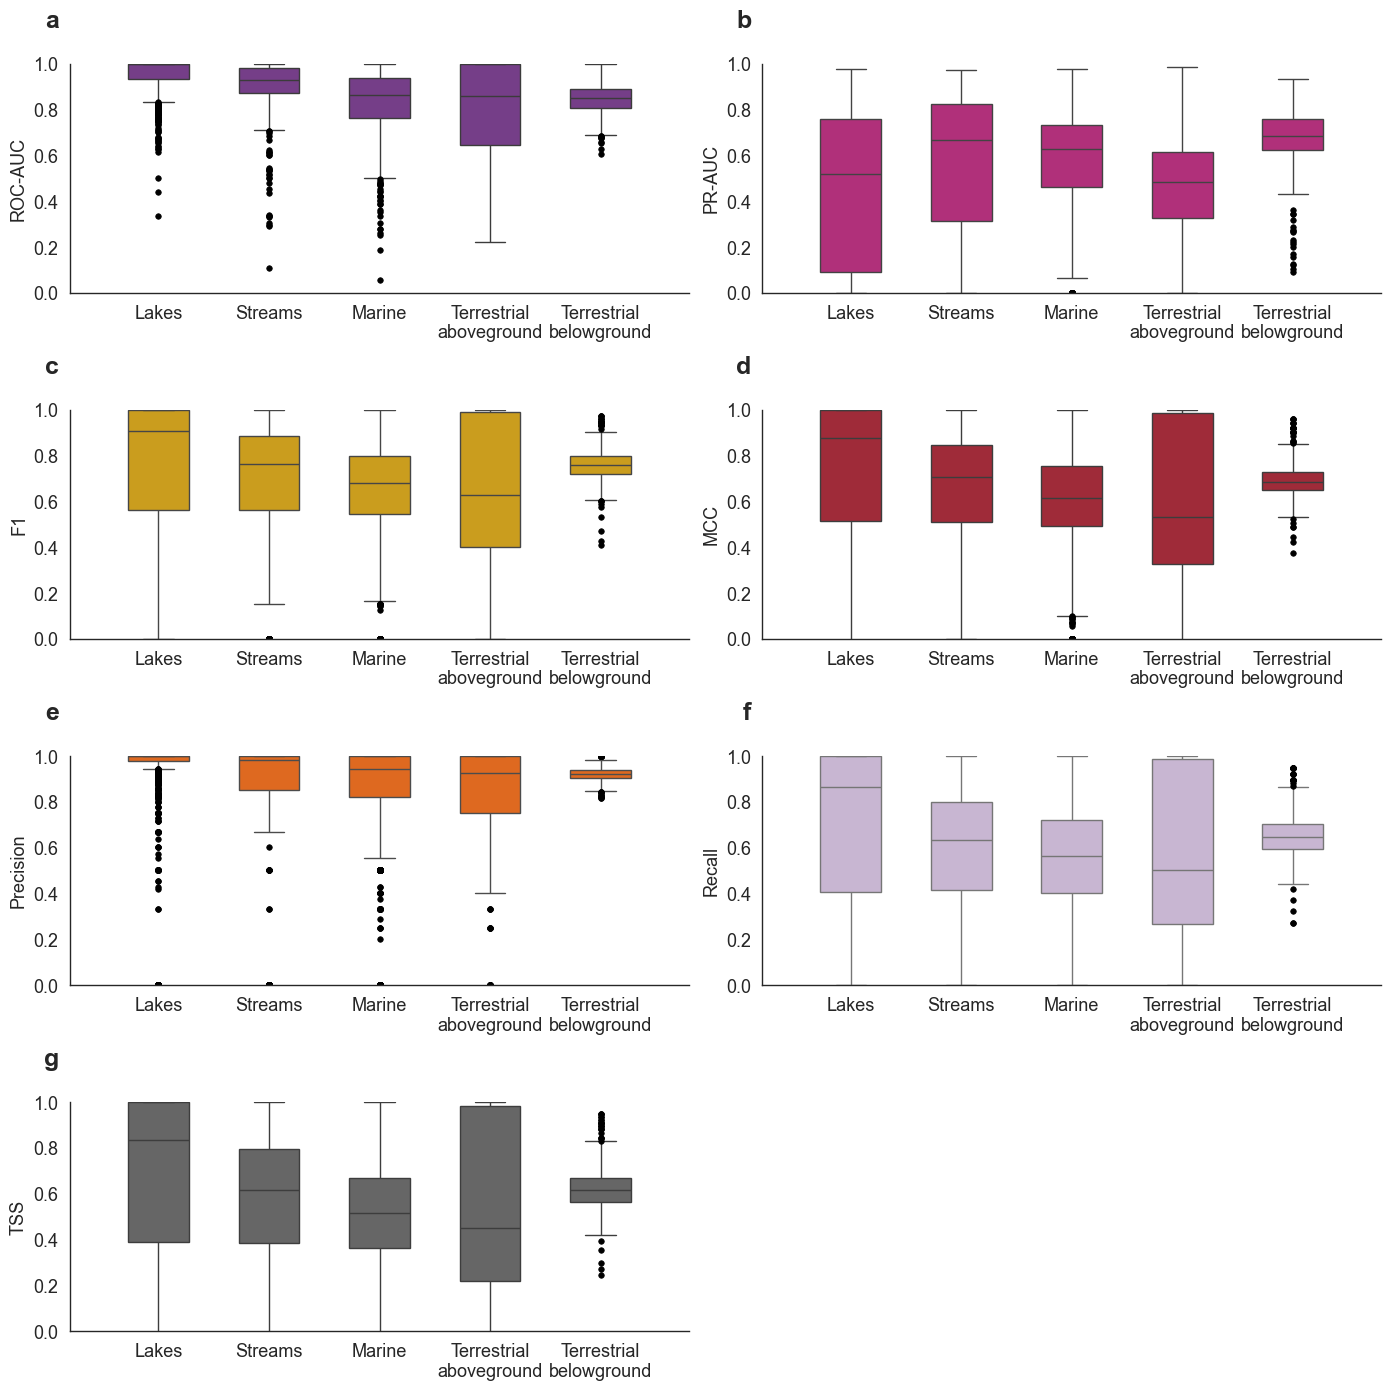

In [37]:
import os
import glob
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")
sns.set_style("white")

# === Paths ===
results_dir = "../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs"
ecosystem_file = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

# === Config ===
METRIC_ORDER = [
    "ROC_AUC",
    "PR_AUC",
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

xtick_labels = [
    "ROC-AUC",
    "PR-AUC",
    "F1",
    "MCC",
    "Precision",
    "Recall",
    "TSS",
]

MIN_NODES = 0
TRAIN_RATIO_TARGET = 90
TRAIN_RATIO_COL = "TrainRatio"

EXPECTED_FOODWEBS = 290
EXPECTED_REPEATS = 20
EXPECTED_POINTS_PER_METRIC = EXPECTED_FOODWEBS * EXPECTED_REPEATS

Y_PADDING = 0.02
Y_MIN_FLOOR = 0.5
Y_MAX_CAP = 1.0

metric_palette = {
    "ROC_AUC": "#7B3294",     # purple
    "PR_AUC": "#C51B7D",      # magenta
    "F1Score": "#E6AB02",     # mustard
    "TestMCC": "#B2182B",     # deep red / burgundy
    "Precision": "#FE6100",   # orange
    "Recall": "#CAB2D6",      # violet
    "TestTSS": "#666666",     # dark gray
}

metric_label_map = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "F1Score": "F1",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
}


# === Load ecosystem metadata ===
df_ecosystem = pd.read_csv(ecosystem_file)


def normalize_colname(s: str) -> str:
    return (
        s.strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


# Detect node-count column robustly
node_candidates = {"n_nodes", "num_nodes", "nodes", "nodecount", "n", "s"}
norm_map = {normalize_colname(c): c for c in df_ecosystem.columns}
node_col = next((norm_map[k] for k in node_candidates if k in norm_map), None)

if node_col is None:
    raise RuntimeError(
        "Could not find a node-count column in ecosystem metadata. "
        "Please add one, e.g. 'S', 'nodes', 'num_species', or 'node_count'."
    )


# === Load result CSVs and stack ===
csv_files = glob.glob(os.path.join(results_dir, "*_mass_results_random_wlnm_dir_neg.csv"))
dfs = []

for file in csv_files:
    df = pd.read_csv(file)
    df["Foodweb"] = os.path.basename(file).split("_results_")[0]
    dfs.append(df)

if not dfs:
    raise RuntimeError("No result CSV found. Check the path or pattern.")

df_all = pd.concat(dfs, ignore_index=True)


# === Validate required columns ===
required_cols = [TRAIN_RATIO_COL, "Foodweb", *METRIC_ORDER]

missing_required_cols = [col for col in required_cols if col not in df_all.columns]

if missing_required_cols:
    raise RuntimeError(
        f"The following required columns are missing from result CSVs: {missing_required_cols}"
    )

if "Foodweb" not in df_ecosystem.columns:
    raise RuntimeError("Column 'Foodweb' not found in ecosystem metadata.")

if "EcosystemType" not in df_ecosystem.columns:
    raise RuntimeError("Column 'EcosystemType' not found in ecosystem metadata.")


# === Filter target TrainRatio ===
df_all[TRAIN_RATIO_COL] = pd.to_numeric(df_all[TRAIN_RATIO_COL], errors="coerce")
df_all = df_all[df_all[TRAIN_RATIO_COL] == TRAIN_RATIO_TARGET].copy()

if df_all.empty:
    raise RuntimeError(
        f"No rows found for {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}. "
        "Check how TrainRatio is stored in the CSV files."
    )

print(f"Filtered results by TrainRatio: kept only {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}.")


# === Keep every validation row as one data point ===
# No groupby mean is applied here.
# Therefore, if each food web has 20 validation rows, each metric has 290 x 20 = 5800 values.

print("\n=== Raw validation-row count before metadata merge ===")
print(f"Rows after TrainRatio filtering: {len(df_all)}")
print(f"Expected rows: {EXPECTED_FOODWEBS} food webs x {EXPECTED_REPEATS} repetitions = {EXPECTED_POINTS_PER_METRIC}")

if "Iteration" in df_all.columns:
    repeat_summary_before_merge = (
        df_all.groupby("Foodweb")
        .size()
        .describe()
    )

    print("\nRepeated-validation rows per food web before metadata merge:")
    print(repeat_summary_before_merge)

    iteration_count_summary = (
        df_all.groupby("Foodweb")["Iteration"]
        .nunique()
        .describe()
    )

    print("\nUnique Iteration values per food web:")
    print(iteration_count_summary)


# === Merge metrics with ecosystem metadata ===
df_merged = pd.merge(
    df_all,
    df_ecosystem[["Foodweb", "EcosystemType", node_col]],
    on="Foodweb",
    how="left",
)


# === Apply node-count filter ===
before_n = df_merged["Foodweb"].nunique()
df_merged = df_merged[df_merged[node_col] >= MIN_NODES].copy()
after_n = df_merged["Foodweb"].nunique()

print(f"\nFiltered food webs by size: kept {after_n} / {before_n} (>= {MIN_NODES} nodes).")

print("\n=== Validation-row count after metadata merge and node filtering ===")
print(f"Rows available for plotting: {len(df_merged)}")

if len(df_merged) != EXPECTED_POINTS_PER_METRIC:
    print(
        f"[CHECK] Found {len(df_merged)} rows after filtering, "
        f"but expected {EXPECTED_POINTS_PER_METRIC}. "
        "This may indicate missing food webs, missing metadata, fewer/more iterations, "
        "or duplicated rows introduced during the metadata merge."
    )


# ============================================================
# Precision median by ecosystem: all validation rows
# ============================================================

if "Precision" not in df_merged.columns:
    raise RuntimeError("Column 'Precision' not found in df_merged.")

precision_summary = (
    df_merged
    .dropna(subset=["EcosystemType", "Precision"])
    .groupby("EcosystemType", as_index=False)
    .agg(
        n_foodwebs=("Foodweb", "nunique"),
        n_validation_values=("Precision", "size"),
        Precision_Median=("Precision", "median"),
        Precision_Variance=("Precision", lambda x: x.var(ddof=1)),
    )
)

precision_summary["Precision_Median"] = precision_summary["Precision_Median"].round(4)
precision_summary["Precision_Variance"] = precision_summary["Precision_Variance"].round(6)

print("\n=== Precision median and variance by ecosystem using all validation rows ===")
print(precision_summary.to_string(index=False))

lowest_precision = precision_summary.loc[precision_summary["Precision_Median"].idxmin()]
highest_precision = precision_summary.loc[precision_summary["Precision_Median"].idxmax()]

lowest_variance = precision_summary.loc[precision_summary["Precision_Variance"].idxmin()]
highest_variance = precision_summary.loc[precision_summary["Precision_Variance"].idxmax()]

print("\n=== Ecosystems with lowest/highest median precision and variance ===")

print(
    f"Lowest median precision:  {lowest_precision['EcosystemType']} "
    f"(median = {lowest_precision['Precision_Median']}, "
    f"variance = {lowest_precision['Precision_Variance']})"
)

print(
    f"Highest median precision: {highest_precision['EcosystemType']} "
    f"(median = {highest_precision['Precision_Median']}, "
    f"variance = {highest_precision['Precision_Variance']})"
)

print(
    f"Lowest variance:          {lowest_variance['EcosystemType']} "
    f"(variance = {lowest_variance['Precision_Variance']}, "
    f"median = {lowest_variance['Precision_Median']})"
)

print(
    f"Highest variance:         {highest_variance['EcosystemType']} "
    f"(variance = {highest_variance['Precision_Variance']}, "
    f"median = {highest_variance['Precision_Median']})"
)


# === Prepare long-format data ===
id_vars = ["Foodweb", TRAIN_RATIO_COL, "EcosystemType"]

if "Iteration" in df_merged.columns:
    id_vars.append("Iteration")

df_plot = df_merged.melt(
    id_vars=id_vars,
    value_vars=METRIC_ORDER,
    var_name="Metric",
    value_name="Value",
)

df_plot[TRAIN_RATIO_COL] = df_plot[TRAIN_RATIO_COL].astype(str)

df_plot["Metric"] = pd.Categorical(
    df_plot["Metric"],
    categories=METRIC_ORDER,
    ordered=True,
)

print("\n=== Non-missing values per metric after melting ===")
metric_counts = (
    df_plot
    .dropna(subset=["Value"])
    .groupby("Metric", observed=True)
    .size()
)

print(metric_counts)

for metric, count in metric_counts.items():
    if count != EXPECTED_POINTS_PER_METRIC:
        print(
            f"[CHECK] Metric {metric}: found {count} non-missing values, "
            f"expected {EXPECTED_POINTS_PER_METRIC}."
        )


# === Preferred ecosystem order ===
preferred_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystems_present = (
    df_merged["EcosystemType"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

eco_lookup = {eco.lower(): eco for eco in ecosystems_present}

ecosystem_order = [
    eco_lookup[eco]
    for eco in preferred_ecosystem_order
    if eco in eco_lookup
]

ecosystem_order += [
    eco for eco in ecosystems_present
    if eco.lower() not in set(preferred_ecosystem_order)
]


# === Panel labels ===
labels_map = (
    df_merged[["Foodweb", "EcosystemType"]]
    .drop_duplicates()
    .groupby("EcosystemType")["Foodweb"]
    .nunique()
    .to_dict()
)


def format_ecosystem_label(eco: str, n: int) -> str:
    eco_clean = str(eco).strip()
    eco_lower = eco_clean.lower()

    label_replacements = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial\naboveground",
        "terrestrial belowground": "Terrestrial\nbelowground",
    }

    label = label_replacements.get(eco_lower, eco_clean.capitalize())
    return f"{label}"


labels_map = {
    eco: format_ecosystem_label(eco, n)
    for eco, n in labels_map.items()
}


# === Data already filtered to target TrainRatio ===
subset = df_plot.copy()


# === Plot: metric panels, with ecosystems placed next to each other ===
n_panels = len(METRIC_ORDER)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 14),
    sharey=False,
)

axes = np.array(axes).reshape(-1)
panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, metric in enumerate(METRIC_ORDER):
    ax = axes[i]
    sub = subset[subset["Metric"] == metric].copy()

    if sub.empty:
        ax.set_axis_off()
        continue

    sns.boxplot(
        data=sub,
        x="EcosystemType",
        y="Value",
        order=ecosystem_order,
        color=metric_palette.get(metric, "#7B3294"),
        legend=False,
        width=0.55,
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
        ax=ax,
    )

    leg = ax.get_legend()

    if leg is not None:
        leg.remove()

    ax.set_xlabel("")
    ax.set_xticks(range(len(ecosystem_order)))
    ax.set_xticklabels(
        [labels_map.get(eco, eco) for eco in ecosystem_order],
        rotation=0,
        ha="center",
        fontsize=13,
        linespacing=1.1,
    )

    ax.set_ylabel(metric_label_map.get(metric, metric), fontsize=13)
    ax.tick_params(axis="y", labelleft=True, labelsize=13)

    ax.set_xlim(-0.8, len(ecosystem_order) - 1 + 0.8)

    ax.set_ylim(0, 1.0)

    ax.grid(False, axis="x")
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[i],
        xy=(0, 1.1),
        xycoords="axes fraction",
        xytext=(-8, 6),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )


# Hide unused axes
for j in range(n_panels, len(axes)):
    axes[j].set_axis_off()


fig.tight_layout(rect=[0, 0, 1, 1], w_pad=1, h_pad=1)
plt.show()

[INFO] Loaded paired input: 23,196 web x run x metric rows
[INFO] Loaded paired tests: 20 rows
[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/statistical_tests/eoin/run_level_boxplots_paired_p_delta_train90.png


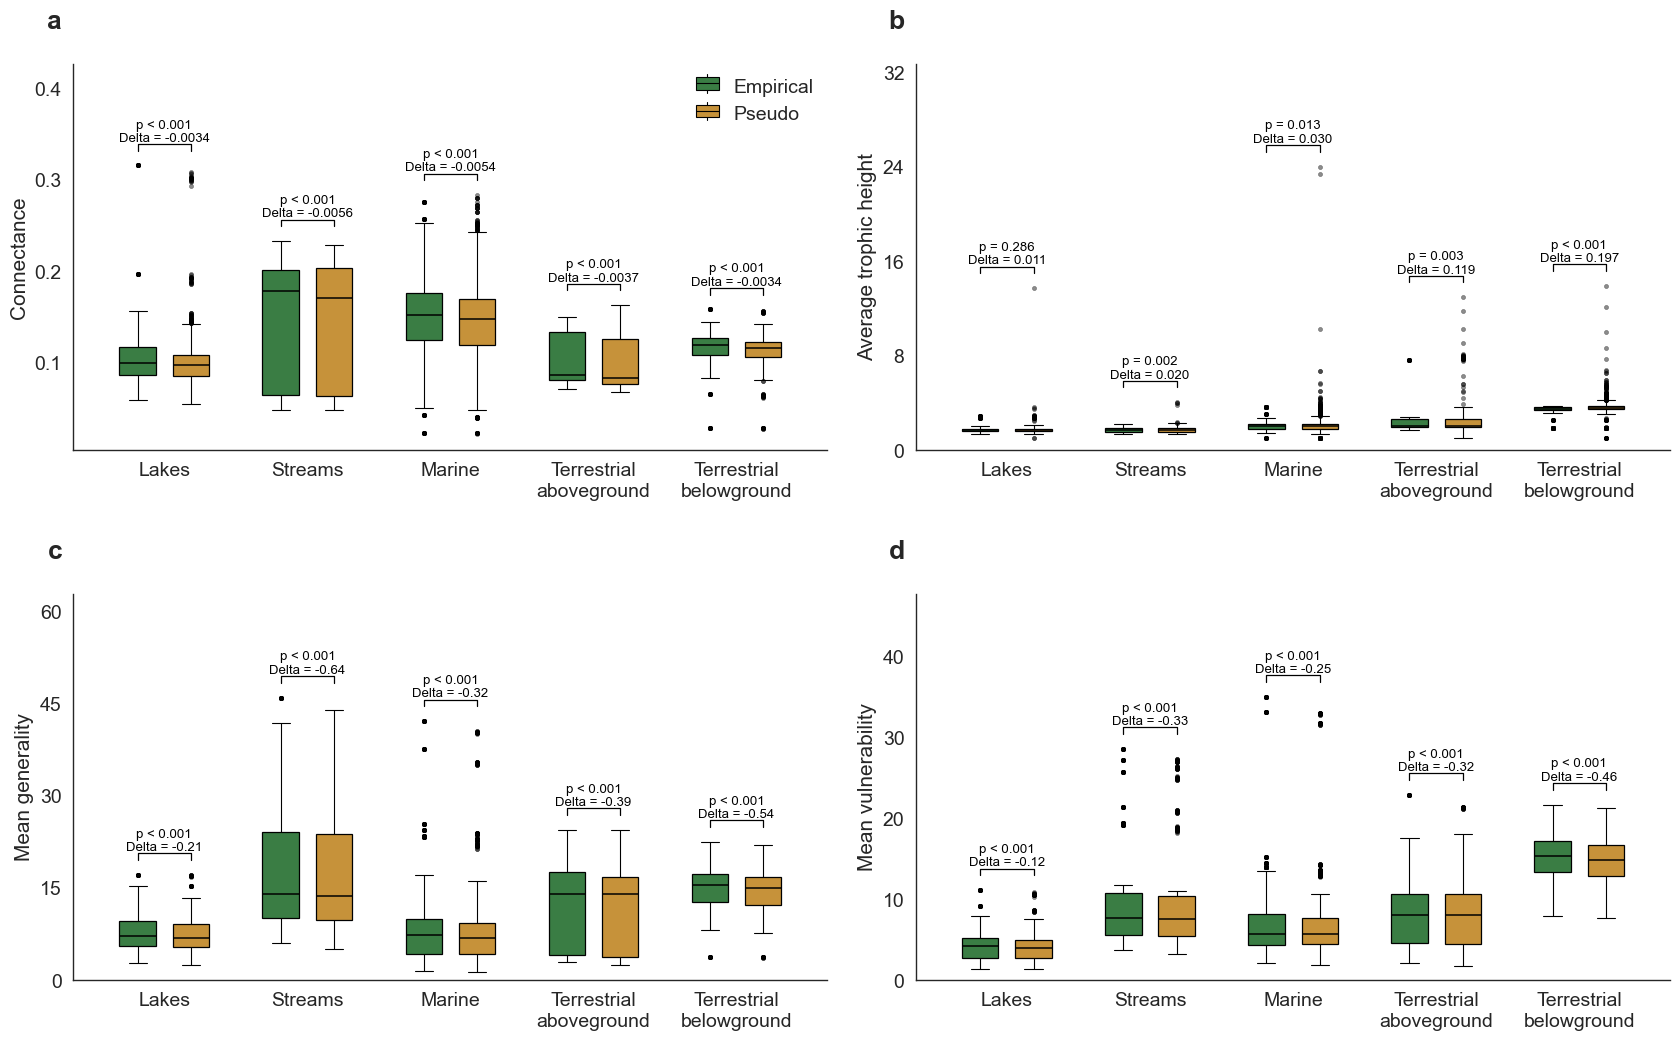

In [17]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

sns.set_theme(context="paper", style="white", font_scale=1.15)

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")

REPO_ROOT = find_repo_root()

EOIN_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita"
    / "statistical_tests/eoin"
)

PAIRED_INPUT = EOIN_DIR / "eoin_paired_input_train90.csv"
PAIRED_TESTS = EOIN_DIR / "eoin_paired_ttest_by_ecosystem_results_train90.csv"

# ============================================================
# CONFIG
# ============================================================
BOX_WIDTH = 0.30
TYPE_OFFSET = 0.22
GROUP_SPACING = 1.18

base_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial\naboveground",
    "terrestrial belowground": "Terrestrial\nbelowground",
}

metric_order = [
    "connectance",
    "average_trophic_height",
    "mean_generality",
    "mean_vulnerability",
]

metric_labels = {
    "connectance": "Connectance",
    "average_trophic_height": "Average trophic height",
    "mean_generality": "Mean generality",
    "mean_vulnerability": "Mean vulnerability",
}

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

type_palette = {
    "Empirical": "#3A7D44",
    "Pseudo": "#C6923A",
}

# ============================================================
# HELPERS
# ============================================================
def format_ecosystem_label(eco: str) -> str:
    eco_clean = str(eco).strip().lower()
    return ecosystem_labels.get(eco_clean, str(eco).strip().capitalize())

def format_p_delta(p_value, mean_delta, metric):
    if pd.isna(p_value):
        p_label = "p = n/a"
    elif p_value < 0.001:
        p_label = "p < 0.001"
    else:
        p_label = f"p = {p_value:.3f}"

    if pd.isna(mean_delta):
        delta_label = "Delta = n/a"
    elif metric == "connectance":
        delta_label = f"Delta = {mean_delta:.4f}"
    elif metric == "average_trophic_height":
        delta_label = f"Delta = {mean_delta:.3f}"
    else:
        delta_label = f"Delta = {mean_delta:.2f}"

    return f"{p_label}\n{delta_label}"

def add_ttest_bracket(ax, x1, x2, y, h, label):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        color="black",
        linewidth=0.9,
        clip_on=False,
    )
    ax.text(
        (x1 + x2) / 2,
        y + h,
        label,
        ha="center",
        va="bottom",
        fontsize=9.5,
        linespacing=1.15,
        color="black",
        clip_on=False,
    )

def draw_box(ax, values, position, facecolor):
    ax.boxplot(
        values,
        positions=[position],
        widths=BOX_WIDTH,
        patch_artist=True,
        manage_ticks=False,
        showfliers=True,
        boxprops={
            "facecolor": facecolor,
            "edgecolor": "black",
            "linewidth": 0.9,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.1,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 0.8,
        },
        capprops={
            "color": "black",
            "linewidth": 0.8,
        },
        flierprops={
            "marker": "o",
            "markersize": 3.0,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.4,
            "linestyle": "none",
            "alpha": 0.45,
        },
    )

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.8)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]

# ============================================================
# LOAD CORRECTED RUN-LEVEL DATA
# ============================================================
paired_input = pd.read_csv(PAIRED_INPUT)
paired_tests = pd.read_csv(PAIRED_TESTS)

paired_input["metric"] = paired_input["metric"].astype(str)
paired_input["ecosystem"] = paired_input["ecosystem"].astype(str)

for col in ["real", "pseudo"]:
    paired_input[col] = pd.to_numeric(paired_input[col], errors="coerce")

paired_tests["metric"] = paired_tests["metric"].astype(str)
paired_tests["ecosystem"] = paired_tests["ecosystem"].astype(str)
paired_tests["p_value"] = pd.to_numeric(paired_tests["p_value"], errors="coerce")
paired_tests["delta_pseudo_minus_real"] = pd.to_numeric(
    paired_tests["delta_pseudo_minus_real"],
    errors="coerce",
)

print(f"[INFO] Loaded paired input: {len(paired_input):,} web x run x metric rows")
print(f"[INFO] Loaded paired tests: {len(paired_tests):,} rows")

# ============================================================
# PLOT
# ============================================================
n_panels = len(metric_order)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, 10.6), sharey=False)
axes = np.array(axes).reshape(-1)

legend_handles = [
    {"facecolor": type_palette["Empirical"], "edgecolor": "black", "linewidth": 0.8},
    {"facecolor": type_palette["Pseudo"], "edgecolor": "black", "linewidth": 0.8},
]
legend_labels = ["Empirical", "Pseudo"]

for idx, (ax, metric) in enumerate(zip(axes, metric_order)):
    panel_df = paired_input[paired_input["metric"] == metric].copy()
    panel_df = panel_df.dropna(subset=["real", "pseudo", "ecosystem"])

    if panel_df.empty:
        ax.set_visible(False)
        continue

    present_ecosystems = [
        eco for eco in base_ecosystem_order
        if eco in panel_df["ecosystem"].unique()
    ]
    extra_ecosystems = [
        eco for eco in panel_df["ecosystem"].unique()
        if eco not in base_ecosystem_order
    ]
    eco_order = present_ecosystems + extra_ecosystems

    base_positions = np.arange(len(eco_order)) * GROUP_SPACING

    all_values = []
    bracket_specs = []

    for eco, base_x in zip(eco_order, base_positions):
        eco_df = panel_df[panel_df["ecosystem"] == eco]

        real_values = pd.to_numeric(eco_df["real"], errors="coerce").dropna().values
        pseudo_values = pd.to_numeric(eco_df["pseudo"], errors="coerce").dropna().values

        if len(real_values):
            draw_box(
                ax=ax,
                values=real_values,
                position=base_x - TYPE_OFFSET,
                facecolor=type_palette["Empirical"],
            )
            all_values.extend(real_values)

        if len(pseudo_values):
            draw_box(
                ax=ax,
                values=pseudo_values,
                position=base_x + TYPE_OFFSET,
                facecolor=type_palette["Pseudo"],
            )
            all_values.extend(pseudo_values)

        pair_values = np.concatenate([real_values, pseudo_values])
        if len(pair_values):
            test_row = paired_tests[
                (paired_tests["metric"] == metric)
                & (paired_tests["ecosystem"] == eco)
            ].iloc[0]

            label = format_p_delta(
                p_value=test_row["p_value"],
                mean_delta=test_row["delta_pseudo_minus_real"],
                metric=metric,
            )

            bracket_specs.append((base_x, np.nanmax(pair_values), label))

    ax.set_title("")
    ax.set_ylabel(metric_labels[metric], fontsize=15)
    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=14)

    # Independent y-axis zoom per panel, with extra headroom for brackets
    panel_vals = np.asarray(all_values, dtype=float)
    panel_vals = panel_vals[np.isfinite(panel_vals)]

    if panel_vals.size:
        local_min = np.nanmin(panel_vals)
        local_max = np.nanmax(panel_vals)
        data_range = local_max - local_min if local_max > local_min else 0.05

        local_min = max(0.0, local_min - 0.06 * data_range)
        local_max = local_max + 0.38 * data_range

        if np.isclose(local_min, local_max):
            local_min = max(0.0, local_min - 0.02)
            local_max = local_max + 0.02

        ax.set_ylim(local_min, local_max)
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))

        bracket_h = 0.025 * data_range
        bracket_pad = 0.055 * data_range

        for base_x, pair_max, p_label in bracket_specs:
            add_ttest_bracket(
                ax=ax,
                x1=base_x - TYPE_OFFSET,
                x2=base_x + TYPE_OFFSET,
                y=pair_max + bracket_pad,
                h=bracket_h,
                label=p_label,
            )

    ax.set_xlim(base_positions[0] - 0.75, base_positions[-1] + 0.75)

    ax.set_xticks(base_positions)
    ax.set_xticklabels(
        [format_ecosystem_label(eco) for eco in eco_order],
        rotation=0,
        fontsize=14,
    )

    ax.grid(False, axis="x")
    ax.grid(False, axis="y")
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[idx],
        xy=(0, 1.05),
        xycoords="axes fraction",
        xytext=(-8, 8),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=19,
        fontweight="bold",
        annotation_clip=False,
    )

    if idx == 0:
        ax.legend(
            handles=legend_handles,
            labels=legend_labels,
            handler_map={dict: HandlerMiniBoxplot()},
            loc="upper right",
            ncol=1,
            frameon=False,
            fontsize=14,
            handlelength=1.5,
            handleheight=0.9,
            handletextpad=0.6,
            borderpad=0.2,
            labelspacing=0.45,
        )

for j in range(len(metric_order), len(axes)):
    axes[j].set_visible(False)

fig.tight_layout(pad=1.3, w_pad=2.0, h_pad=2.6)

OUT_PATH = EOIN_DIR / "run_level_boxplots_paired_p_delta_train90.png"
fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"[INFO] Saved figure: {OUT_PATH}")

plt.show()

[INFO] Loaded paired input: 23,145 web x run x metric rows
[INFO] Loaded paired tests: 20 rows
[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/statistical_tests/eoin/train_ratio_60/run_level_boxplots_paired_p_delta_train60.png


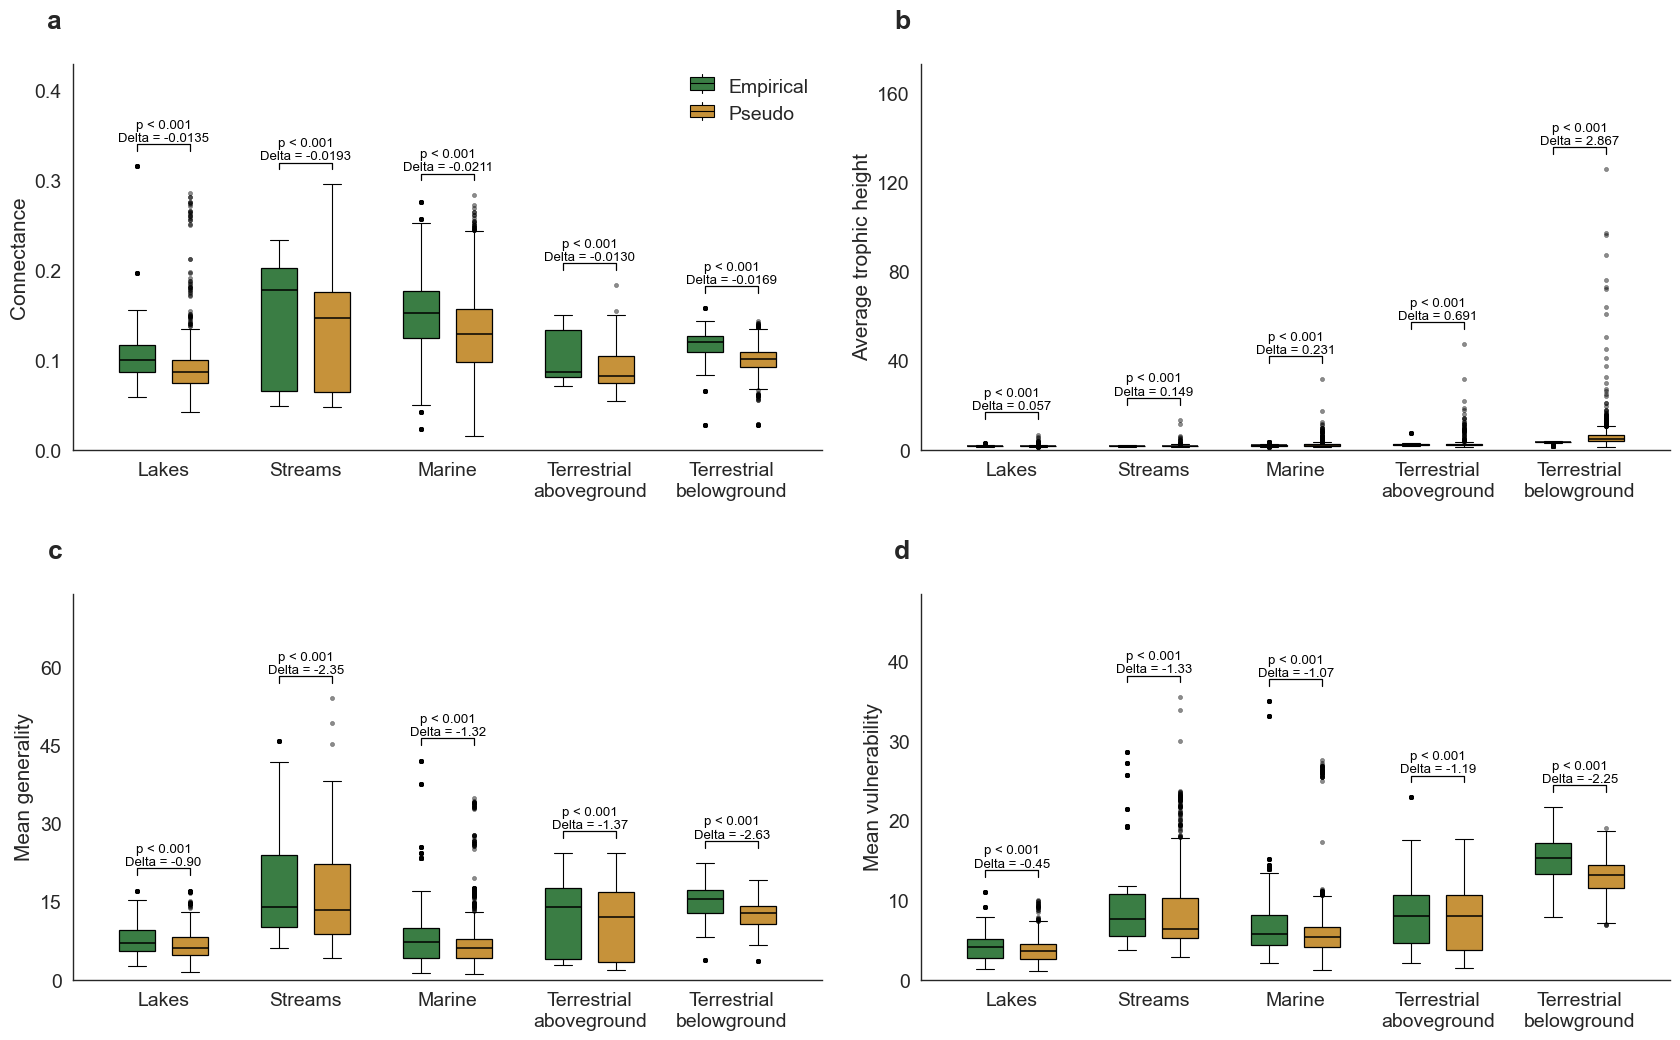

In [25]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

sns.set_theme(context="paper", style="white", font_scale=1.15)

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")

REPO_ROOT = find_repo_root()

TRAIN_RATIO = 60

EOIN_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita"
    / "statistical_tests/eoin"
    / f"train_ratio_{TRAIN_RATIO}"
)

PAIRED_INPUT = EOIN_DIR / f"eoin_paired_input_train{TRAIN_RATIO}.csv"
PAIRED_TESTS = EOIN_DIR / f"eoin_paired_ttest_by_ecosystem_results_train{TRAIN_RATIO}.csv"

# ============================================================
# CONFIG
# ============================================================
BOX_WIDTH = 0.30
TYPE_OFFSET = 0.22
GROUP_SPACING = 1.18

base_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial\naboveground",
    "terrestrial belowground": "Terrestrial\nbelowground",
}

metric_order = [
    "connectance",
    "average_trophic_height",
    "mean_generality",
    "mean_vulnerability",
]

metric_labels = {
    "connectance": "Connectance",
    "average_trophic_height": "Average trophic height",
    "mean_generality": "Mean generality",
    "mean_vulnerability": "Mean vulnerability",
}

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

type_palette = {
    "Empirical": "#3A7D44",
    "Pseudo": "#C6923A",
}

# ============================================================
# HELPERS
# ============================================================
def format_ecosystem_label(eco: str) -> str:
    eco_clean = str(eco).strip().lower()
    return ecosystem_labels.get(eco_clean, str(eco).strip().capitalize())

def format_p_delta(p_value, mean_delta, metric):
    if pd.isna(p_value):
        p_label = "p = n/a"
    elif p_value < 0.001:
        p_label = "p < 0.001"
    else:
        p_label = f"p = {p_value:.3f}"

    if pd.isna(mean_delta):
        delta_label = "Delta = n/a"
    elif metric == "connectance":
        delta_label = f"Delta = {mean_delta:.4f}"
    elif metric == "average_trophic_height":
        delta_label = f"Delta = {mean_delta:.3f}"
    else:
        delta_label = f"Delta = {mean_delta:.2f}"

    return f"{p_label}\n{delta_label}"

def add_ttest_bracket(ax, x1, x2, y, h, label):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        color="black",
        linewidth=0.9,
        clip_on=False,
    )
    ax.text(
        (x1 + x2) / 2,
        y + h,
        label,
        ha="center",
        va="bottom",
        fontsize=9.5,
        linespacing=1.15,
        color="black",
        clip_on=False,
    )

def draw_box(ax, values, position, facecolor):
    ax.boxplot(
        values,
        positions=[position],
        widths=BOX_WIDTH,
        patch_artist=True,
        manage_ticks=False,
        showfliers=True,
        boxprops={
            "facecolor": facecolor,
            "edgecolor": "black",
            "linewidth": 0.9,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.1,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 0.8,
        },
        capprops={
            "color": "black",
            "linewidth": 0.8,
        },
        flierprops={
            "marker": "o",
            "markersize": 3.0,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.4,
            "linestyle": "none",
            "alpha": 0.45,
        },
    )

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.8)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]

# ============================================================
# LOAD CORRECTED RUN-LEVEL DATA
# ============================================================
paired_input = pd.read_csv(PAIRED_INPUT)
paired_tests = pd.read_csv(PAIRED_TESTS)

paired_input["metric"] = paired_input["metric"].astype(str)
paired_input["ecosystem"] = paired_input["ecosystem"].astype(str)

for col in ["real", "pseudo"]:
    paired_input[col] = pd.to_numeric(paired_input[col], errors="coerce")

paired_tests["metric"] = paired_tests["metric"].astype(str)
paired_tests["ecosystem"] = paired_tests["ecosystem"].astype(str)
paired_tests["p_value"] = pd.to_numeric(paired_tests["p_value"], errors="coerce")
paired_tests["delta_pseudo_minus_real"] = pd.to_numeric(
    paired_tests["delta_pseudo_minus_real"],
    errors="coerce",
)

print(f"[INFO] Loaded paired input: {len(paired_input):,} web x run x metric rows")
print(f"[INFO] Loaded paired tests: {len(paired_tests):,} rows")

# ============================================================
# PLOT
# ============================================================
n_panels = len(metric_order)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, 10.6), sharey=False)
axes = np.array(axes).reshape(-1)

legend_handles = [
    {"facecolor": type_palette["Empirical"], "edgecolor": "black", "linewidth": 0.8},
    {"facecolor": type_palette["Pseudo"], "edgecolor": "black", "linewidth": 0.8},
]
legend_labels = ["Empirical", "Pseudo"]

for idx, (ax, metric) in enumerate(zip(axes, metric_order)):
    panel_df = paired_input[paired_input["metric"] == metric].copy()
    panel_df = panel_df.dropna(subset=["real", "pseudo", "ecosystem"])

    if panel_df.empty:
        ax.set_visible(False)
        continue

    present_ecosystems = [
        eco for eco in base_ecosystem_order
        if eco in panel_df["ecosystem"].unique()
    ]
    extra_ecosystems = [
        eco for eco in panel_df["ecosystem"].unique()
        if eco not in base_ecosystem_order
    ]
    eco_order = present_ecosystems + extra_ecosystems

    base_positions = np.arange(len(eco_order)) * GROUP_SPACING

    all_values = []
    bracket_specs = []

    for eco, base_x in zip(eco_order, base_positions):
        eco_df = panel_df[panel_df["ecosystem"] == eco]

        real_values = pd.to_numeric(eco_df["real"], errors="coerce").dropna().values
        pseudo_values = pd.to_numeric(eco_df["pseudo"], errors="coerce").dropna().values

        if len(real_values):
            draw_box(
                ax=ax,
                values=real_values,
                position=base_x - TYPE_OFFSET,
                facecolor=type_palette["Empirical"],
            )
            all_values.extend(real_values)

        if len(pseudo_values):
            draw_box(
                ax=ax,
                values=pseudo_values,
                position=base_x + TYPE_OFFSET,
                facecolor=type_palette["Pseudo"],
            )
            all_values.extend(pseudo_values)

        pair_values = np.concatenate([real_values, pseudo_values])
        if len(pair_values):
            test_row = paired_tests[
                (paired_tests["metric"] == metric)
                & (paired_tests["ecosystem"] == eco)
            ].iloc[0]

            label = format_p_delta(
                p_value=test_row["p_value"],
                mean_delta=test_row["delta_pseudo_minus_real"],
                metric=metric,
            )

            bracket_specs.append((base_x, np.nanmax(pair_values), label))

    ax.set_title("")
    ax.set_ylabel(metric_labels[metric], fontsize=15)
    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=14)

    panel_vals = np.asarray(all_values, dtype=float)
    panel_vals = panel_vals[np.isfinite(panel_vals)]

    if panel_vals.size:
        local_min = np.nanmin(panel_vals)
        local_max = np.nanmax(panel_vals)
        data_range = local_max - local_min if local_max > local_min else 0.05

        local_min = max(0.0, local_min - 0.06 * data_range)
        local_max = local_max + 0.38 * data_range

        if np.isclose(local_min, local_max):
            local_min = max(0.0, local_min - 0.02)
            local_max = local_max + 0.02

        ax.set_ylim(local_min, local_max)
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))

        bracket_h = 0.025 * data_range
        bracket_pad = 0.055 * data_range

        for base_x, pair_max, p_label in bracket_specs:
            add_ttest_bracket(
                ax=ax,
                x1=base_x - TYPE_OFFSET,
                x2=base_x + TYPE_OFFSET,
                y=pair_max + bracket_pad,
                h=bracket_h,
                label=p_label,
            )

    ax.set_xlim(base_positions[0] - 0.75, base_positions[-1] + 0.75)

    ax.set_xticks(base_positions)
    ax.set_xticklabels(
        [format_ecosystem_label(eco) for eco in eco_order],
        rotation=0,
        fontsize=14,
    )

    ax.grid(False, axis="x")
    ax.grid(False, axis="y")
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[idx],
        xy=(0, 1.05),
        xycoords="axes fraction",
        xytext=(-8, 8),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=19,
        fontweight="bold",
        annotation_clip=False,
    )

    if idx == 0:
        ax.legend(
            handles=legend_handles,
            labels=legend_labels,
            handler_map={dict: HandlerMiniBoxplot()},
            loc="upper right",
            ncol=1,
            frameon=False,
            fontsize=14,
            handlelength=1.5,
            handleheight=0.9,
            handletextpad=0.6,
            borderpad=0.2,
            labelspacing=0.45,
        )

for j in range(len(metric_order), len(axes)):
    axes[j].set_visible(False)

fig.tight_layout(pad=1.3, w_pad=2.0, h_pad=2.6)

OUT_PATH = EOIN_DIR / f"run_level_boxplots_paired_p_delta_train{TRAIN_RATIO}.png"
fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"[INFO] Saved figure: {OUT_PATH}")

plt.show()

In [ ]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

# ------------------------------------------------------------
# Locate repo root robustly
# ------------------------------------------------------------
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")

REPO_ROOT = find_repo_root()

EOIN_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita"
    / "statistical_tests/eoin"
)

print("Loading Eoin/Athen statistical outputs from:")
print(EOIN_DIR)

# ------------------------------------------------------------
# Load corrected run-level tables
# ------------------------------------------------------------
run_summary = pd.read_csv(EOIN_DIR / "eoin_run_summary_train90.csv")

connectance_paired_input = pd.read_csv(EOIN_DIR / "eoin_connectance_paired_input_train90.csv")
paired_input = pd.read_csv(EOIN_DIR / "eoin_paired_input_train90.csv")

mixed_model_wide = pd.read_csv(EOIN_DIR / "eoin_mixed_model_wide_train90.csv")
mixed_model_long = pd.read_csv(EOIN_DIR / "eoin_mixed_model_long_train90.csv")

paired_general = pd.read_csv(EOIN_DIR / "eoin_paired_ttest_general_results_train90.csv")
paired_by_ecosystem = pd.read_csv(EOIN_DIR / "eoin_paired_ttest_by_ecosystem_results_train90.csv")

r_paired_general_path = EOIN_DIR / "eoin_r_paired_ttest_general_results_train90.csv"
r_lme_anova_path = EOIN_DIR / "eoin_r_lme_anova_train90.csv"
r_lme_coef_path = EOIN_DIR / "eoin_r_lme_coefficients_train90.csv"
r_lme_posthoc_path = EOIN_DIR / "eoin_r_lme_posthoc_webtype_by_ecosystem_train90.csv"

r_paired_general = pd.read_csv(r_paired_general_path) if r_paired_general_path.exists() else None
r_lme_anova = pd.read_csv(r_lme_anova_path) if r_lme_anova_path.exists() else None
r_lme_coef = pd.read_csv(r_lme_coef_path) if r_lme_coef_path.exists() else None
r_lme_posthoc = pd.read_csv(r_lme_posthoc_path) if r_lme_posthoc_path.exists() else None

# ------------------------------------------------------------
# Formatting helpers
# ------------------------------------------------------------
def format_p(p):
    if pd.isna(p):
        return "n/a"
    p = float(p)
    if p < 0.001:
        return "p < 0.001"
    return f"p = {p:.3f}"

def show_rows(df):
    return f"{len(df):,} rows x {len(df.columns):,} columns"

def style_paired_table(df):
    preferred_cols = [
        "metric", "scope", "ecosystem",
        "n_pairs", "n_webs",
        "mean_real", "mean_pseudo",
        "delta_pseudo_minus_real",
        "std_delta", "t_statistic", "df",
        "p_value", "alpha", "reject_h0", "direction",
        "conf_low", "conf_high",
    ]

    show = df[[c for c in preferred_cols if c in df.columns]].copy()

    if "p_value" in show.columns:
        show["p_label"] = show["p_value"].apply(format_p)

    formatters = {
        "mean_real": "{:.4f}",
        "mean_pseudo": "{:.4f}",
        "delta_pseudo_minus_real": "{:.4f}",
        "std_delta": "{:.4f}",
        "t_statistic": "{:.3f}",
        "p_value": "{:.3e}",
        "conf_low": "{:.4f}",
        "conf_high": "{:.4f}",
    }

    style = show.style.format({k: v for k, v in formatters.items() if k in show.columns})

    if "delta_pseudo_minus_real" in show.columns:
        style = style.background_gradient(
            subset=["delta_pseudo_minus_real"],
            cmap="RdBu_r"
        )

    return style

def style_lme_anova(df):
    show = df.copy()

    if "p-value" in show.columns:
        show["p_label"] = show["p-value"].apply(format_p)

    return show.style.format({
        "F-value": "{:.3f}",
        "p-value": "{:.3e}",
    })

def style_lme_posthoc(df):
    show = df.copy()

    if "p.value" in show.columns:
        show["p_label"] = show["p.value"].apply(format_p)

    formatters = {
        "estimate": "{:.4f}",
        "DeltaPseudoMinusReal": "{:.4f}",
        "SE": "{:.4f}",
        "t.ratio": "{:.3f}",
        "p.value": "{:.3e}",
    }

    style = show.style.format({k: v for k, v in formatters.items() if k in show.columns})

    if "DeltaPseudoMinusReal" in show.columns:
        style = style.background_gradient(
            subset=["DeltaPseudoMinusReal"],
            cmap="RdBu_r"
        )

    return style

# ------------------------------------------------------------
# Display outputs
# ------------------------------------------------------------
display(Markdown("## 1. Run summary"))
display(Markdown("Confirms that the analysis unit is now `web x run`, not averaged food-web means."))
display(run_summary)

display(Markdown("## 2. Paired t-test input: connectance only"))
display(Markdown(f"`{show_rows(connectance_paired_input)}`"))
display(Markdown("One row per `web x run_id`, with the empirical web paired against one generated pseudo web."))
display(connectance_paired_input.head(20))

display(Markdown("## 3. Paired t-test input: all metrics"))
display(Markdown(f"`{show_rows(paired_input)}`"))
display(Markdown("One row per `web x run_id x metric`, with `real` and `pseudo` on the same row."))
display(paired_input.head(20))

display(Markdown("## 4. Paired t-test results: general"))
display(Markdown("These are the run-level paired t-tests requested by Athen/Eoin."))
display(style_paired_table(paired_general))

display(Markdown("## 5. Paired t-test results: by ecosystem"))
display(style_paired_table(paired_by_ecosystem))

display(Markdown("## 6. Compact p-value table by ecosystem"))
p_table = paired_by_ecosystem.copy()
p_table["p_label"] = p_table["p_value"].apply(format_p)

display(
    p_table.pivot(
        index="ecosystem",
        columns="metric",
        values="p_label"
    )
)

display(Markdown("## 7. Mean Delta table by ecosystem"))
display(Markdown("`Delta = Pseudo - Real`; negative values mean pseudo webs are lower than empirical webs."))
delta_table = paired_by_ecosystem.pivot(
    index="ecosystem",
    columns="metric",
    values="delta_pseudo_minus_real"
)

display(delta_table.style.format("{:.4f}").background_gradient(cmap="RdBu_r"))

display(Markdown("## 8. Mixed-model input: wide format"))
display(Markdown(f"`{show_rows(mixed_model_wide)}`"))
display(Markdown("This follows Eoin's suggested structure: `web`, `run_id`, `web_type`, `ecosystem`, `connectance`, plus other metrics."))
display(mixed_model_wide.head(20))

display(Markdown("## 9. Mixed-model input: long format"))
display(Markdown(f"`{show_rows(mixed_model_long)}`"))
display(Markdown("This is the input used by the R script to run the same mixed-effects model for all metrics."))
display(mixed_model_long.head(20))

if r_paired_general is not None:
    display(Markdown("## 10. R paired t-test results: general"))
    display(style_paired_table(r_paired_general))
else:
    display(Markdown("## 10. R paired t-test results: general"))
    display(Markdown("R paired t-test output not found."))

if r_lme_anova is not None:
    display(Markdown("## 11. R mixed-effects model: ANOVA"))
    display(Markdown("Model: `lme(value ~ web_type * ecosystem, random = ~1 | web)`"))
    display(style_lme_anova(r_lme_anova))
else:
    display(Markdown("## 11. R mixed-effects model: ANOVA"))
    display(Markdown("R ANOVA output not found. Run `Rscript docs/stats/eoin_mixed_effects_wlnm_dir_neg_apocrita.R` first."))

if r_lme_coef is not None:
    display(Markdown("## 12. R mixed-effects model: coefficients"))
    display(r_lme_coef)
else:
    display(Markdown("## 12. R mixed-effects model: coefficients"))
    display(Markdown("R coefficient output not found."))

if r_lme_posthoc is not None:
    display(Markdown("## 13. R mixed-effects model: post-hoc real vs pseudo by ecosystem"))
    display(Markdown("These are `real - pseudo` contrasts from `emmeans`; `DeltaPseudoMinusReal` flips the sign to match `Pseudo - Real`."))
    display(style_lme_posthoc(r_lme_posthoc))
else:
    display(Markdown("## 13. R mixed-effects model: post-hoc real vs pseudo by ecosystem"))
    display(Markdown("R post-hoc output not found. Make sure `emmeans` is installed and rerun the R script."))

Loading Eoin/Athen statistical outputs from:
/Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/statistical_tests/eoin


## 1. Run summary

Confirms that the analysis unit is now `web x run`, not averaged food-web means.

,Field,Value
0,SourceLogFiles,290
1,TotalRowsRead,52200
2,TargetTrainRatioRows,5800
3,LongRowsWritten,46396
4,MissingMetricValuesSkipped,4
5,FoodwebsMissingMetadata,0
6,MissingMetadataFoodwebs,NaN
7,AnalysisUnit,web x run
8,RunLevelPairedRows,23196
9,ConnectancePairedRows,5800


## 2. Paired t-test input: connectance only

...

## 12. R mixed-effects model: coefficients

,Metric,Coefficient,Value,Std.Error,DF,t-value,p-value
0,average_trophic_height,(Intercept),1.695778,0.068246,11297,24.847888,9.603438e-133
1,average_trophic_height,web_typepseudo,0.010974,0.017300,11297,0.634327,5.258803e-01
2,average_trophic_height,ecosystemmarine,0.308943,0.081051,285,3.811715,1.691374e-04
3,average_trophic_height,ecosystemstreams,-0.033264,0.117499,285,-0.283096,7.773085e-01
4,average_trophic_height,ecosystemterrestrial aboveground,0.705994,0.129829,285,5.437870,1.160454e-07
5,average_trophic_height,ecosystemterrestrial belowground,1.659693,0.097896,285,16.953582,4.601022e-45
6,average_trophic_height,web_typepseudo:ecosystemmarine,0.018868,0.020547,11297,0.918322,3.584697e-01
7,average_trophic_height,web_typepseudo:ecosystemstreams,0.009025,0.029777,11297,0.303073,7.618399e-01
8,average_trophic_height,web_typepseudo:ecosystemterrestrial aboveground,0.108510,0.032900,11297,3.298132,9.763130e-04
9,average_trophic_height,web_typepseudo:ecosystemterrestrial belowground,0.185682,0.024811,11297,7.484004,7.744653e-14


## 13. R mixed-effects model: post-hoc real vs pseudo by ecosystem

These are `real - pseudo` contrasts from `emmeans`; `DeltaPseudoMinusReal` flips the sign to match `Pseudo - Real`.

,Metric,ecosystem,contrast,estimate,DeltaPseudoMinusReal,SE,df,t.ratio,p.value,Direction,p_label
0,average_trophic_height,lakes,real - pseudo,-0.0110,0.0110,0.0173,11297,-0.634,5.259e-01,pseudo_higher,p = 0.526
1,average_trophic_height,marine,real - pseudo,-0.0298,0.0298,0.0111,11297,-2.692,7.108e-03,pseudo_higher,p = 0.007
2,average_trophic_height,streams,real - pseudo,-0.0200,0.0200,0.0242,11297,-0.825,4.093e-01,pseudo_higher,p = 0.409
3,average_trophic_height,terrestrial aboveground,real - pseudo,-0.1195,0.1195,0.0280,11297,-4.270,1.974e-05,pseudo_higher,p < 0.001
4,average_trophic_height,terrestrial belowground,real - pseudo,-0.1967,0.1967,0.0178,11297,-11.058,2.799e-28,pseudo_higher,p < 0.001
5,connectance,lakes,real - pseudo,0.0034,-0.0034,0.0001,11305,30.298,6.116e-194,pseudo_lower,p < 0.001
6,connectance,marine,real - pseudo,0.0054,-0.0054,0.0001,11305,74.859,0.000e+00,pseudo_lower,p < 0.001
7,connectance,streams,real - pseudo,0.0056,-0.0056,0.0002,11305,35.649,7.084e-264,pseudo_lower,p < 0.001
8,connectance,terrestrial aboveground,real - pseudo,0.0037,-0.0037,0.0002,11305,20.015,1.325e-87,pseudo_lower,p < 0.001
9,connectance,terrestrial belowground,real - pseudo,0.0034,-0.0034,0.0001,11305,29.550,6.239e-185,pseudo_lower,p < 0.001


In [ ]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

# ------------------------------------------------------------
# Locate repo root robustly
# ------------------------------------------------------------
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")

REPO_ROOT = find_repo_root()

TRAIN_RATIO = 60

EOIN_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita"
    / "statistical_tests/eoin"
    / f"train_ratio_{TRAIN_RATIO}"
)

print("Loading Eoin/Athen statistical outputs from:")
print(EOIN_DIR)

# ------------------------------------------------------------
# Load corrected run-level tables
# ------------------------------------------------------------
run_summary = pd.read_csv(EOIN_DIR / f"eoin_run_summary_train{TRAIN_RATIO}.csv")

connectance_paired_input = pd.read_csv(
    EOIN_DIR / f"eoin_connectance_paired_input_train{TRAIN_RATIO}.csv"
)
paired_input = pd.read_csv(
    EOIN_DIR / f"eoin_paired_input_train{TRAIN_RATIO}.csv"
)

mixed_model_wide = pd.read_csv(
    EOIN_DIR / f"eoin_mixed_model_wide_train{TRAIN_RATIO}.csv"
)
mixed_model_long = pd.read_csv(
    EOIN_DIR / f"eoin_mixed_model_long_train{TRAIN_RATIO}.csv"
)

paired_general = pd.read_csv(
    EOIN_DIR / f"eoin_paired_ttest_general_results_train{TRAIN_RATIO}.csv"
)
paired_by_ecosystem = pd.read_csv(
    EOIN_DIR / f"eoin_paired_ttest_by_ecosystem_results_train{TRAIN_RATIO}.csv"
)

r_paired_general_path = EOIN_DIR / f"eoin_r_paired_ttest_general_results_train{TRAIN_RATIO}.csv"
r_lme_anova_path = EOIN_DIR / f"eoin_r_lme_anova_train{TRAIN_RATIO}.csv"
r_lme_coef_path = EOIN_DIR / f"eoin_r_lme_coefficients_train{TRAIN_RATIO}.csv"
r_lme_posthoc_path = EOIN_DIR / f"eoin_r_lme_posthoc_webtype_by_ecosystem_train{TRAIN_RATIO}.csv"

r_paired_general = pd.read_csv(r_paired_general_path) if r_paired_general_path.exists() else None
r_lme_anova = pd.read_csv(r_lme_anova_path) if r_lme_anova_path.exists() else None
r_lme_coef = pd.read_csv(r_lme_coef_path) if r_lme_coef_path.exists() else None
r_lme_posthoc = pd.read_csv(r_lme_posthoc_path) if r_lme_posthoc_path.exists() else None

# ------------------------------------------------------------
# Formatting helpers
# ------------------------------------------------------------
def format_p(p):
    if pd.isna(p):
        return "n/a"
    p = float(p)
    if p < 0.001:
        return "p < 0.001"
    return f"p = {p:.3f}"

def show_rows(df):
    return f"{len(df):,} rows x {len(df.columns):,} columns"

def style_paired_table(df):
    preferred_cols = [
        "metric", "scope", "ecosystem",
        "n_pairs", "n_webs",
        "mean_real", "mean_pseudo",
        "delta_pseudo_minus_real",
        "std_delta", "t_statistic", "df",
        "p_value", "alpha", "reject_h0", "direction",
        "conf_low", "conf_high",
    ]

    show = df[[c for c in preferred_cols if c in df.columns]].copy()

    if "p_value" in show.columns:
        show["p_label"] = show["p_value"].apply(format_p)

    formatters = {
        "mean_real": "{:.4f}",
        "mean_pseudo": "{:.4f}",
        "delta_pseudo_minus_real": "{:.4f}",
        "std_delta": "{:.4f}",
        "t_statistic": "{:.3f}",
        "p_value": "{:.3e}",
        "conf_low": "{:.4f}",
        "conf_high": "{:.4f}",
    }

    style = show.style.format({k: v for k, v in formatters.items() if k in show.columns})

    if "delta_pseudo_minus_real" in show.columns:
        style = style.background_gradient(
            subset=["delta_pseudo_minus_real"],
            cmap="RdBu_r"
        )

    return style

def style_lme_anova(df):
    show = df.copy()

    if "p-value" in show.columns:
        show["p_label"] = show["p-value"].apply(format_p)

    return show.style.format({
        "F-value": "{:.3f}",
        "p-value": "{:.3e}",
    })

def style_lme_posthoc(df):
    show = df.copy()

    if "p.value" in show.columns:
        show["p_label"] = show["p.value"].apply(format_p)

    formatters = {
        "estimate": "{:.4f}",
        "DeltaPseudoMinusReal": "{:.4f}",
        "SE": "{:.4f}",
        "t.ratio": "{:.3f}",
        "p.value": "{:.3e}",
    }

    style = show.style.format({k: v for k, v in formatters.items() if k in show.columns})

    if "DeltaPseudoMinusReal" in show.columns:
        style = style.background_gradient(
            subset=["DeltaPseudoMinusReal"],
            cmap="RdBu_r"
        )

    return style

# ------------------------------------------------------------
# Display outputs
# ------------------------------------------------------------
display(Markdown(f"## 1. Run summary (train ratio {TRAIN_RATIO})"))
display(Markdown("Confirms that the analysis unit is now `web x run`, not averaged food-web means."))
display(run_summary)

display(Markdown("## 2. Paired t-test input: connectance only"))
display(Markdown(f"`{show_rows(connectance_paired_input)}`"))
display(Markdown("One row per `web x run_id`, with the empirical web paired against one generated pseudo web."))
display(connectance_paired_input.head(20))

display(Markdown("## 3. Paired t-test input: all metrics"))
display(Markdown(f"`{show_rows(paired_input)}`"))
display(Markdown("One row per `web x run_id x metric`, with `real` and `pseudo` on the same row."))
display(paired_input.head(20))

display(Markdown("## 4. Paired t-test results: general"))
display(Markdown("These are the run-level paired t-tests requested by Athen/Eoin."))
display(style_paired_table(paired_general))

display(Markdown("## 5. Paired t-test results: by ecosystem"))
display(style_paired_table(paired_by_ecosystem))

display(Markdown("## 6. Compact p-value table by ecosystem"))
p_table = paired_by_ecosystem.copy()
p_table["p_label"] = p_table["p_value"].apply(format_p)

display(
    p_table.pivot(
        index="ecosystem",
        columns="metric",
        values="p_label"
    )
)

display(Markdown("## 7. Mean Delta table by ecosystem"))
display(Markdown("`Delta = Pseudo - Real`; negative values mean pseudo webs are lower than empirical webs."))
delta_table = paired_by_ecosystem.pivot(
    index="ecosystem",
    columns="metric",
    values="delta_pseudo_minus_real"
)

display(delta_table.style.format("{:.4f}").background_gradient(cmap="RdBu_r"))

display(Markdown("## 8. Mixed-model input: wide format"))
display(Markdown(f"`{show_rows(mixed_model_wide)}`"))
display(Markdown("This follows Eoin's suggested structure: `web`, `run_id`, `web_type`, `ecosystem`, `connectance`, plus other metrics."))
display(mixed_model_wide.head(20))

display(Markdown("## 9. Mixed-model input: long format"))
display(Markdown(f"`{show_rows(mixed_model_long)}`"))
display(Markdown("This is the input used by the R script to run the same mixed-effects model for all metrics."))
display(mixed_model_long.head(20))

if r_paired_general is not None:
    display(Markdown("## 10. R paired t-test results: general"))
    display(style_paired_table(r_paired_general))
else:
    display(Markdown("## 10. R paired t-test results: general"))
    display(Markdown("R paired t-test output not found."))

if r_lme_anova is not None:
    display(Markdown("## 11. R mixed-effects model: ANOVA"))
    display(Markdown("Model: `lme(value ~ web_type * ecosystem, random = ~1 | web)`"))
    display(style_lme_anova(r_lme_anova))
else:
    display(Markdown("## 11. R mixed-effects model: ANOVA"))
    display(Markdown("R ANOVA output not found. Run `Rscript docs/stats/eoin_mixed_effects_wlnm_dir_neg_apocrita.R` first."))

if r_lme_coef is not None:
    display(Markdown("## 12. R mixed-effects model: coefficients"))
    display(r_lme_coef)
else:
    display(Markdown("## 12. R mixed-effects model: coefficients"))
    display(Markdown("R coefficient output not found."))

if r_lme_posthoc is not None:
    display(Markdown("## 13. R mixed-effects model: post-hoc real vs pseudo by ecosystem"))
    display(Markdown("These are `real - pseudo` contrasts from `emmeans`; `DeltaPseudoMinusReal` flips the sign to match `Pseudo - Real`."))
    display(style_lme_posthoc(r_lme_posthoc))
else:
    display(Markdown("## 13. R mixed-effects model: post-hoc real vs pseudo by ecosystem"))
    display(Markdown("R post-hoc output not found. Make sure `emmeans` is installed and rerun the R script."))

Loading Eoin/Athen statistical outputs from:
/Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/statistical_tests/eoin/train_ratio_60


## 1. Run summary (train ratio 60)

Confirms that the analysis unit is now `web x run`, not averaged food-web means.

,Field,Value
0,RequestedTrainRatio,60.0
1,SourceLogFiles,290
2,TotalRowsRead,52200
3,TargetTrainRatioRows,5800
4,LongRowsWritten,46345
5,MissingMetricValuesSkipped,55
6,FoodwebsMissingMetadata,0
7,MissingMetadataFoodwebs,NaN
8,AnalysisUnit,web x run
9,RunLevelPairedRows,23145


## 2. Paired t-test input: connectance only

...

## 12. R mixed-effects model: coefficients

,Metric,Coefficient,Value,Std.Error,DF,t-value,p-value
0,average_trophic_height,(Intercept),1.690024,0.119971,11195,14.086968,1.098881e-44
1,average_trophic_height,web_typepseudo,0.057221,0.114590,11195,0.499355,6.175391e-01
2,average_trophic_height,ecosystemmarine,0.315582,0.142342,285,2.217070,2.740741e-02
3,average_trophic_height,ecosystemstreams,-0.027510,0.205952,285,-0.133573,8.938345e-01
4,average_trophic_height,ecosystemterrestrial aboveground,0.720106,0.228450,285,3.152133,1.793619e-03
5,average_trophic_height,ecosystemterrestrial belowground,1.662420,0.172046,285,9.662672,2.730295e-19
6,average_trophic_height,web_typepseudo:ecosystemmarine,0.174083,0.135864,11195,1.281304,2.001136e-01
7,average_trophic_height,web_typepseudo:ecosystemstreams,0.091329,0.196278,11195,0.465305,6.417220e-01
8,average_trophic_height,web_typepseudo:ecosystemterrestrial aboveground,0.633956,0.218668,11195,2.899173,3.748749e-03
9,average_trophic_height,web_typepseudo:ecosystemterrestrial belowground,2.809929,0.164414,11195,17.090587,1.149376e-64


## 13. R mixed-effects model: post-hoc real vs pseudo by ecosystem

These are `real - pseudo` contrasts from `emmeans`; `DeltaPseudoMinusReal` flips the sign to match `Pseudo - Real`.

,Metric,ecosystem,contrast,estimate,DeltaPseudoMinusReal,SE,df,t.ratio,p.value,Direction,p_label
0,average_trophic_height,lakes,real - pseudo,-0.0572,0.0572,0.1146,11195,-0.499,6.175e-01,pseudo_higher,p = 0.618
1,average_trophic_height,marine,real - pseudo,-0.2313,0.2313,0.0730,11195,-3.169,1.535e-03,pseudo_higher,p = 0.002
2,average_trophic_height,streams,real - pseudo,-0.1486,0.1486,0.1594,11195,-0.932,3.513e-01,pseudo_higher,p = 0.351
3,average_trophic_height,terrestrial aboveground,real - pseudo,-0.6912,0.6912,0.1862,11195,-3.711,2.072e-04,pseudo_higher,p < 0.001
4,average_trophic_height,terrestrial belowground,real - pseudo,-2.8672,2.8672,0.1179,11195,-24.318,2.457e-127,pseudo_higher,p < 0.001
5,connectance,lakes,real - pseudo,0.0135,-0.0135,0.0004,11305,36.917,8.782e-282,pseudo_lower,p < 0.001
6,connectance,marine,real - pseudo,0.0211,-0.0211,0.0002,11305,90.157,0.000e+00,pseudo_lower,p < 0.001
7,connectance,streams,real - pseudo,0.0193,-0.0193,0.0005,11305,37.737,1.248e-293,pseudo_lower,p < 0.001
8,connectance,terrestrial aboveground,real - pseudo,0.0130,-0.0130,0.0006,11305,21.983,6.497e-105,pseudo_lower,p < 0.001
9,connectance,terrestrial belowground,real - pseudo,0.0169,-0.0169,0.0004,11305,45.039,0.000e+00,pseudo_lower,p < 0.001


Saved figure to: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/statistical_tests/eoin/posthoc_mixed_model_delta_forest_plot_train90.png


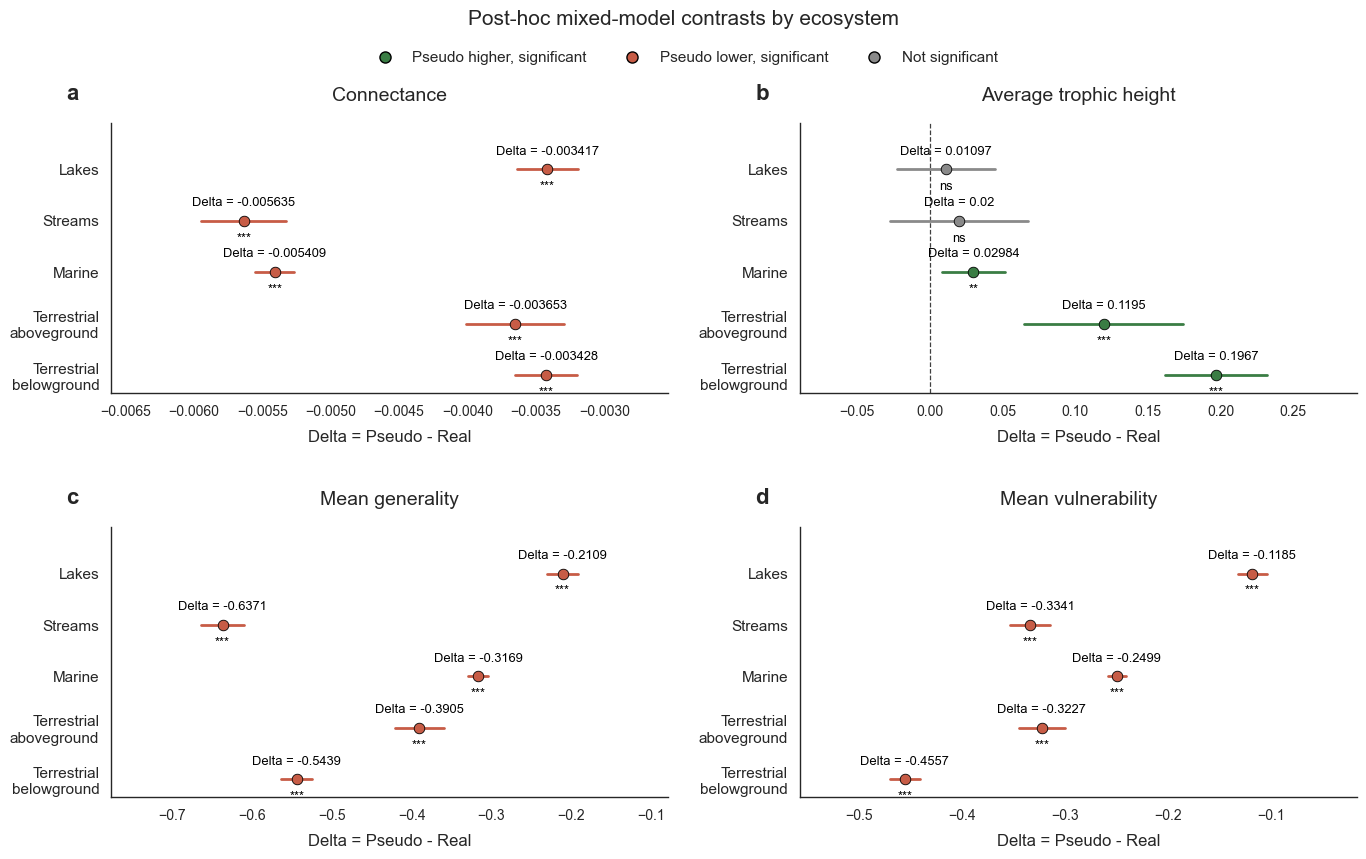

In [23]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="paper", style="white", font_scale=1.15)

# ------------------------------------------------------------
# Locate repo root
# ------------------------------------------------------------
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")

REPO_ROOT = find_repo_root()

EOIN_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita"
    / "statistical_tests/eoin"
)

POSTHOC_PATH = EOIN_DIR / "eoin_r_lme_posthoc_webtype_by_ecosystem_train90.csv"
posthoc = pd.read_csv(POSTHOC_PATH)

# ------------------------------------------------------------
# Labels and order
# ------------------------------------------------------------
metric_order = [
    "connectance",
    "average_trophic_height",
    "mean_generality",
    "mean_vulnerability",
]

metric_labels = {
    "connectance": "Connectance",
    "average_trophic_height": "Average trophic height",
    "mean_generality": "Mean generality",
    "mean_vulnerability": "Mean vulnerability",
}

ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial\naboveground",
    "terrestrial belowground": "Terrestrial\nbelowground",
}

posthoc = posthoc.copy()
posthoc["Metric"] = posthoc["Metric"].astype(str)
posthoc["ecosystem"] = posthoc["ecosystem"].astype(str)

# ------------------------------------------------------------
# Values and approximate 95% CI
# DeltaPseudoMinusReal is Pseudo - Real.
# ------------------------------------------------------------
posthoc["delta"] = pd.to_numeric(posthoc["DeltaPseudoMinusReal"], errors="coerce")
posthoc["se"] = pd.to_numeric(posthoc["SE"], errors="coerce")
posthoc["p_value"] = pd.to_numeric(posthoc["p.value"], errors="coerce")

posthoc["ci_low"] = posthoc["delta"] - 1.96 * posthoc["se"]
posthoc["ci_high"] = posthoc["delta"] + 1.96 * posthoc["se"]

def significance_label(p):
    if pd.isna(p):
        return "n/a"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

posthoc["sig"] = posthoc["p_value"].apply(significance_label)

# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------
positive_color = "#3A7D44"  # pseudo higher
negative_color = "#C75C46"  # pseudo lower
ns_color = "#8A8A8A"

def point_color(row):
    if row["p_value"] >= 0.05 or pd.isna(row["p_value"]):
        return ns_color
    if row["delta"] > 0:
        return positive_color
    if row["delta"] < 0:
        return negative_color
    return ns_color

posthoc["color"] = posthoc.apply(point_color, axis=1)

fig, axes = plt.subplots(2, 2, figsize=(13.8, 9.2), sharey=False)
axes = axes.reshape(-1)

panel_letters = list("abcd")

for idx, (ax, metric) in enumerate(zip(axes, metric_order)):
    df = posthoc[posthoc["Metric"] == metric].copy()

    df["ecosystem"] = pd.Categorical(
        df["ecosystem"],
        categories=ecosystem_order,
        ordered=True,
    )
    df = df.sort_values("ecosystem")

    y_positions = np.arange(len(df))

    # horizontal CI bars + dots
    for y, (_, row) in zip(y_positions, df.iterrows()):
        ax.plot(
            [row["ci_low"], row["ci_high"]],
            [y, y],
            color=row["color"],
            linewidth=2.0,
            solid_capstyle="round",
            zorder=2,
        )
        ax.scatter(
            row["delta"],
            y,
            s=58,
            color=row["color"],
            edgecolor="black",
            linewidth=0.6,
            zorder=3,
        )

    # zero reference line
    ax.axvline(
        0,
        color="black",
        linewidth=0.9,
        linestyle="--",
        alpha=0.75,
        zorder=1,
    )

    # x limits
    x_min = np.nanmin(df["ci_low"])
    x_max = np.nanmax(df["ci_high"])
    x_range = x_max - x_min if x_max > x_min else 1.0
    ax.set_xlim(x_min - 0.24 * x_range, x_max + 0.24 * x_range)

    # Delta labels above each dot and significance below
    y_label_offset = 0.23

    for y, (_, row) in zip(y_positions, df.iterrows()):
        ax.text(
            row["delta"],
            y - y_label_offset,
            f"Delta = {row['delta']:.4g}",
            va="bottom",
            ha="center",
            fontsize=9.3,
            color="black",
            zorder=4,
            clip_on=False,
        )

        ax.text(
            row["delta"],
            y + y_label_offset,
            row["sig"],
            va="top",
            ha="center",
            fontsize=9.3,
            color="black",
            zorder=4,
            clip_on=False,
        )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(
        [ecosystem_labels.get(str(e), str(e)) for e in df["ecosystem"]],
        fontsize=11,
    )

    # More vertical breathing room at top and bottom
    ax.set_ylim(len(df) - 0.65, -0.90)

    ax.set_title(metric_labels[metric], fontsize=14, pad=16)
    ax.set_xlabel("Delta = Pseudo - Real", fontsize=12, labelpad=8)

    ax.annotate(
        panel_letters[idx],
        xy=(-0.08, 1.07),
        xycoords="axes fraction",
        fontsize=16,
        fontweight="bold",
        ha="left",
        va="bottom",
    )

    sns.despine(ax=ax)
    ax.grid(False)

# ------------------------------------------------------------
# Shared legend
# ------------------------------------------------------------
legend_handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Pseudo higher, significant",
        markerfacecolor=positive_color,
        markeredgecolor="black",
        markersize=8,
    ),
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Pseudo lower, significant",
        markerfacecolor=negative_color,
        markeredgecolor="black",
        markersize=8,
    ),
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Not significant",
        markerfacecolor=ns_color,
        markeredgecolor="black",
        markersize=8,
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.9),
    fontsize=11,
)

fig.suptitle(
    "Post-hoc mixed-model contrasts by ecosystem",
    fontsize=15,
    y=0.93,
)

plt.tight_layout(rect=[0, 0, 1, 0.91], h_pad=2.6, w_pad=2.0)

# Optional save
OUT_PATH = EOIN_DIR / "posthoc_mixed_model_delta_forest_plot_train90.png"
fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {OUT_PATH}")

plt.show()

Saved figure to: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/statistical_tests/eoin/train_ratio_60/posthoc_mixed_model_delta_forest_plot_train60.png


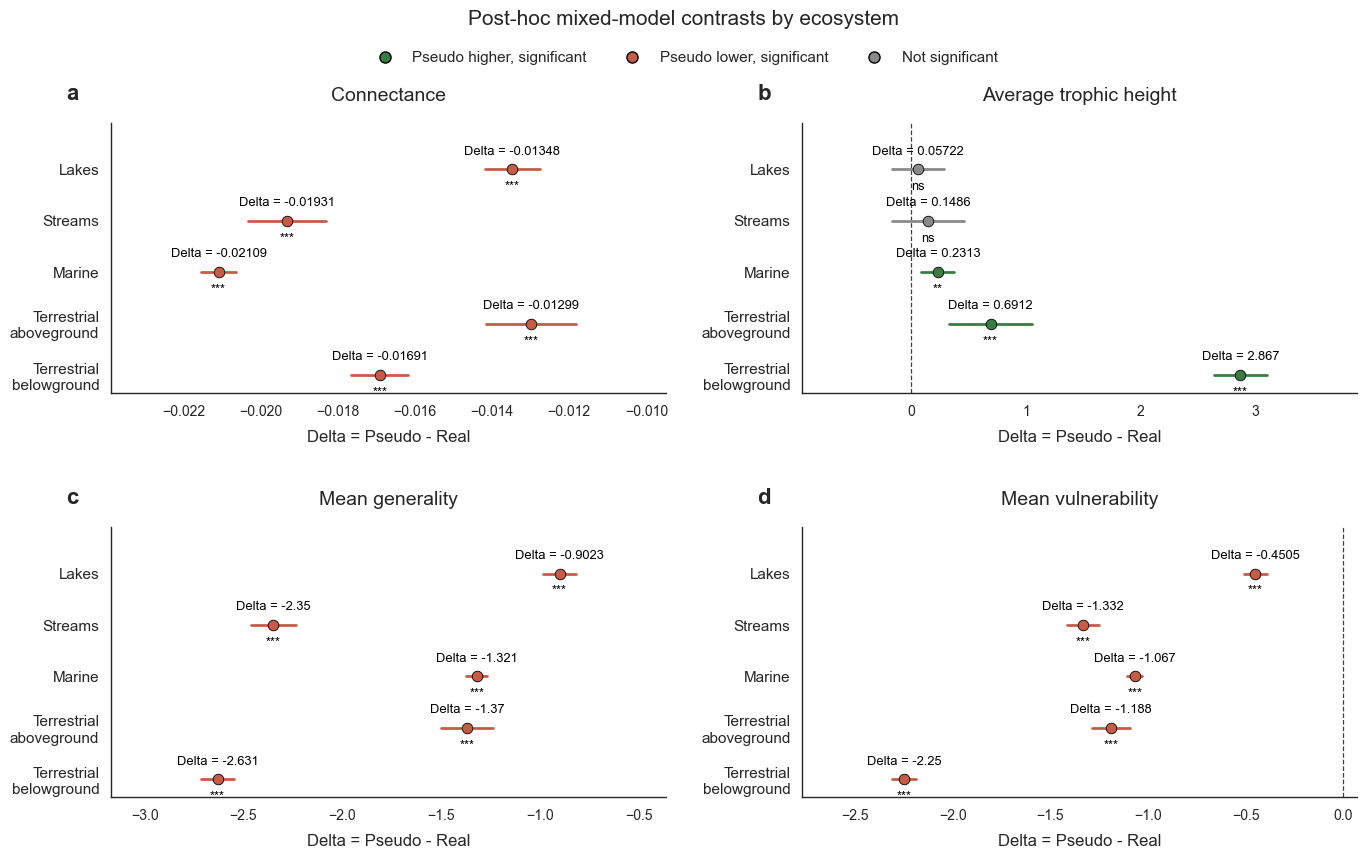

In [28]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="paper", style="white", font_scale=1.15)

# ------------------------------------------------------------
# Locate repo root
# ------------------------------------------------------------
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")

REPO_ROOT = find_repo_root()

TRAIN_RATIO = 60

EOIN_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita"
    / "statistical_tests/eoin"
    / f"train_ratio_{TRAIN_RATIO}"
)

POSTHOC_PATH = EOIN_DIR / f"eoin_r_lme_posthoc_webtype_by_ecosystem_train{TRAIN_RATIO}.csv"
posthoc = pd.read_csv(POSTHOC_PATH)

# ------------------------------------------------------------
# Labels and order
# ------------------------------------------------------------
metric_order = [
    "connectance",
    "average_trophic_height",
    "mean_generality",
    "mean_vulnerability",
]

metric_labels = {
    "connectance": "Connectance",
    "average_trophic_height": "Average trophic height",
    "mean_generality": "Mean generality",
    "mean_vulnerability": "Mean vulnerability",
}

ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial\naboveground",
    "terrestrial belowground": "Terrestrial\nbelowground",
}

posthoc = posthoc.copy()
posthoc["Metric"] = posthoc["Metric"].astype(str)
posthoc["ecosystem"] = posthoc["ecosystem"].astype(str)

# ------------------------------------------------------------
# Values and approximate 95% CI
# DeltaPseudoMinusReal is Pseudo - Real.
# ------------------------------------------------------------
posthoc["delta"] = pd.to_numeric(posthoc["DeltaPseudoMinusReal"], errors="coerce")
posthoc["se"] = pd.to_numeric(posthoc["SE"], errors="coerce")
posthoc["p_value"] = pd.to_numeric(posthoc["p.value"], errors="coerce")

posthoc["ci_low"] = posthoc["delta"] - 1.96 * posthoc["se"]
posthoc["ci_high"] = posthoc["delta"] + 1.96 * posthoc["se"]

def significance_label(p):
    if pd.isna(p):
        return "n/a"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

posthoc["sig"] = posthoc["p_value"].apply(significance_label)

# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------
positive_color = "#3A7D44"  # pseudo higher
negative_color = "#C75C46"  # pseudo lower
ns_color = "#8A8A8A"

def point_color(row):
    if row["p_value"] >= 0.05 or pd.isna(row["p_value"]):
        return ns_color
    if row["delta"] > 0:
        return positive_color
    if row["delta"] < 0:
        return negative_color
    return ns_color

posthoc["color"] = posthoc.apply(point_color, axis=1)

fig, axes = plt.subplots(2, 2, figsize=(13.8, 9.2), sharey=False)
axes = axes.reshape(-1)

panel_letters = list("abcd")

for idx, (ax, metric) in enumerate(zip(axes, metric_order)):
    df = posthoc[posthoc["Metric"] == metric].copy()

    df["ecosystem"] = pd.Categorical(
        df["ecosystem"],
        categories=ecosystem_order,
        ordered=True,
    )
    df = df.sort_values("ecosystem")

    y_positions = np.arange(len(df))

    # horizontal CI bars + dots
    for y, (_, row) in zip(y_positions, df.iterrows()):
        ax.plot(
            [row["ci_low"], row["ci_high"]],
            [y, y],
            color=row["color"],
            linewidth=2.0,
            solid_capstyle="round",
            zorder=2,
        )
        ax.scatter(
            row["delta"],
            y,
            s=58,
            color=row["color"],
            edgecolor="black",
            linewidth=0.6,
            zorder=3,
        )

    # zero reference line
    ax.axvline(
        0,
        color="black",
        linewidth=0.9,
        linestyle="--",
        alpha=0.75,
        zorder=1,
    )

    # x limits
    x_min = np.nanmin(df["ci_low"])
    x_max = np.nanmax(df["ci_high"])
    x_range = x_max - x_min if x_max > x_min else 1.0
    ax.set_xlim(x_min - 0.24 * x_range, x_max + 0.24 * x_range)

    # Delta labels above each dot and significance below
    y_label_offset = 0.23

    for y, (_, row) in zip(y_positions, df.iterrows()):
        ax.text(
            row["delta"],
            y - y_label_offset,
            f"Delta = {row['delta']:.4g}",
            va="bottom",
            ha="center",
            fontsize=9.3,
            color="black",
            zorder=4,
            clip_on=False,
        )

        ax.text(
            row["delta"],
            y + y_label_offset,
            row["sig"],
            va="top",
            ha="center",
            fontsize=9.3,
            color="black",
            zorder=4,
            clip_on=False,
        )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(
        [ecosystem_labels.get(str(e), str(e)) for e in df["ecosystem"]],
        fontsize=11,
    )

    # More vertical breathing room at top and bottom
    ax.set_ylim(len(df) - 0.65, -0.90)

    ax.set_title(metric_labels[metric], fontsize=14, pad=16)
    ax.set_xlabel("Delta = Pseudo - Real", fontsize=12, labelpad=8)

    ax.annotate(
        panel_letters[idx],
        xy=(-0.08, 1.07),
        xycoords="axes fraction",
        fontsize=16,
        fontweight="bold",
        ha="left",
        va="bottom",
    )

    sns.despine(ax=ax)
    ax.grid(False)

# ------------------------------------------------------------
# Shared legend
# ------------------------------------------------------------
legend_handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Pseudo higher, significant",
        markerfacecolor=positive_color,
        markeredgecolor="black",
        markersize=8,
    ),
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Pseudo lower, significant",
        markerfacecolor=negative_color,
        markeredgecolor="black",
        markersize=8,
    ),
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Not significant",
        markerfacecolor=ns_color,
        markeredgecolor="black",
        markersize=8,
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.9),
    fontsize=11,
)

fig.suptitle(
    "Post-hoc mixed-model contrasts by ecosystem",
    fontsize=15,
    y=0.93,
)

plt.tight_layout(rect=[0, 0, 1, 0.91], h_pad=2.6, w_pad=2.0)

# Optional save
OUT_PATH = EOIN_DIR / f"posthoc_mixed_model_delta_forest_plot_train{TRAIN_RATIO}.png"
fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {OUT_PATH}")

plt.show()

[INFO] Result files found: 290
[INFO] Food webs in result files before filtering: 290
[INFO] Food webs in metadata file: 290
[CHECK] K = 10: 290 -> 290 food webs
[CHECK] TrainRatio = 90.0000: 290 -> 290 food webs
[CHECK] Nodes >= 0: 290 -> 290 food webs
[CHECK] available connectance for x-axis: 290 -> 290 food webs
[FINAL] Food webs retained after structural filters: 290

=== OLS linear regression: metric ~ empirical connectance ===
a) ROC-AUC: y = -0.3518x + 0.9138; F1,5798 = 103.6031; R² = 0.0176; P < 0.0001; n = 5800
b) PR-AUC: y = 1.5263x + 0.3666; F1,5798 = 556.0963; R² = 0.0875; P < 0.0001; n = 5800
c) F1: y = -0.9380x + 0.8163; F1,5798 = 203.4918; R² = 0.0339; P < 0.0001; n = 5800
d) MCC: y = -1.1923x + 0.7978; F1,5798 = 295.4709; R² = 0.0485; P < 0.0001; n = 5800
e) Precision: y = -0.5025x + 0.9415; F1,5798 = 66.9666; R² = 0.0114; P < 0.0001; n = 5800
f) Recall: y = -1.1585x + 0.7591; F1,5798 = 257.8478; R² = 0.0426; P < 0.0001; n = 5800
g) TSS: y = -1.3562x + 0.7536; F1,5798 =

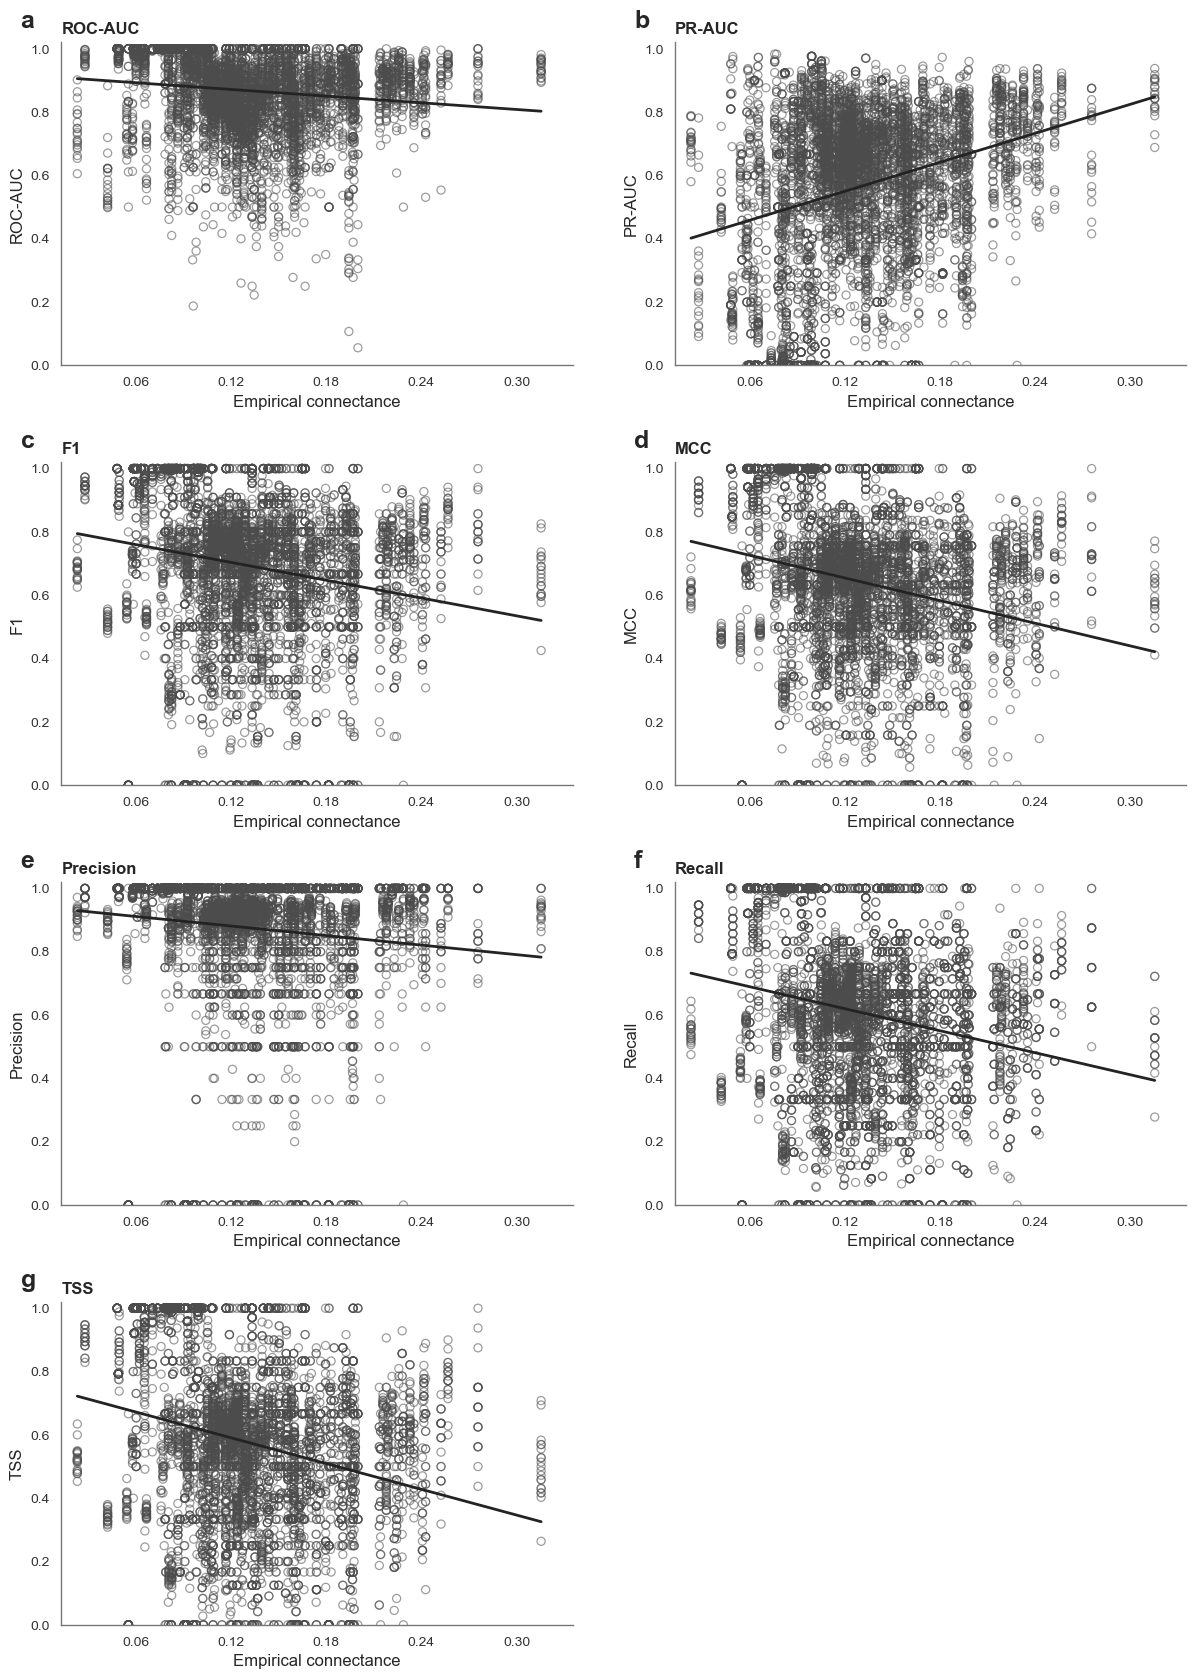

In [40]:
import os
import glob
import math
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "qmul_phd_framework_mplconfig"),
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter


sns.set_theme(style="white", context="paper", font_scale=1.2)

# ============================================================
# Config
# ============================================================

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()

    for path in [start, *start.parents]:
        if (path / "src/matlab").is_dir() and (path / "docs").is_dir():
            return path

    raise FileNotFoundError("Could not find project root from current working directory.")


PROJECT_ROOT = find_project_root()

RESULTS_DIR = PROJECT_ROOT / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs"
ECOSYSTEM_FILE = PROJECT_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
RESULTS_PATTERN = "*_results_*.csv"

K_TARGET = 10
TARGET_RATIO = 90.0
MIN_NODES = 0
AGGREGATE_REPEATS = False

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

ecosystem_palette = {
    "Lakes": "#00A6D6",
    "Streams": "#006D2C",
    "Marine": "#08306B",
    "Terrestrial aboveground": "#7AC943",
    "Terrestrial belowground": "#6B3A19",
    "Unknown": "#999999",
}

ecosystem_markers = {
    "Lakes": "o",
    "Streams": "s",
    "Marine": "D",
    "Terrestrial aboveground": "^",
    "Terrestrial belowground": "v",
    "Unknown": "x",
}

ECOSYSTEM_ORDER = [
    "Lakes",
    "Streams",
    "Marine",
    "Terrestrial aboveground",
    "Terrestrial belowground",
]

Y_MIN = 0.0
Y_MAX = 1.0
Y_PAD_TOP = 0.02
N_COLS = 2

POINT_COLOR = "#4C4C4C"
POINT_MARKER = "o"
POINT_SIZE = 34
POINT_ALPHA = 0.55


# ============================================================
# Helpers
# ============================================================

def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb_name(s: str) -> str:
    s = str(s).strip()
    s = s.replace(".mat", "")
    s = s.replace(".csv", "")
    s = s.replace(" ", "_")
    return "_".join(part for part in s.split("_") if part).lower()


def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}

    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]

    raise KeyError(f"Could not find any of these columns: {candidates}")


def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]


def normalize_train_ratio(series):
    values = pd.to_numeric(series, errors="coerce")
    return np.where(values <= 1.0, values * 100.0, values)


def format_ecosystem_label(name: str) -> str:
    name = str(name).strip().lower()

    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial aboveground",
        "terrestrial belowground": "Terrestrial belowground",
        "unknown": "Unknown",
    }

    return label_map.get(name, str(name).strip().capitalize())


def report_foodweb_count(stage_name: str, before: set, after: set) -> None:
    print(f"[CHECK] {stage_name}: {len(before)} -> {len(after)} food webs")


# ============================================================
# Data loading
# ============================================================

def load_results(results_dir: Path, pattern: str) -> pd.DataFrame:
    files = sorted(glob.glob(str(results_dir / pattern)))

    if not files:
        raise FileNotFoundError(
            f"No result CSV files found in {results_dir} matching {pattern}"
        )

    frames = []

    for path in files:
        df = pd.read_csv(path).copy()

        foodweb = extract_foodweb_name(path)
        foodweb_key = normalize_foodweb_name(foodweb)

        file_meta = pd.DataFrame(
            {
                "Foodweb": foodweb,
                "FoodwebKey": foodweb_key,
            },
            index=df.index,
        )

        df = pd.concat([df, file_meta], axis=1).copy()
        frames.append(df)

    out = pd.concat(frames, ignore_index=True).copy()

    print(f"[INFO] Result files found: {len(files)}")
    print(f"[INFO] Food webs in result files before filtering: {out['Foodweb'].nunique()}")

    return out


def load_foodweb_metadata(path: Path) -> pd.DataFrame:
    meta = pd.read_csv(path).copy()

    foodweb_col = find_column(meta, ["foodweb"])
    ecosystem_col = find_column(meta, ["ecosystemtype", "ecosystem", "ecosystem_type"])
    nodes_col = find_column(meta, ["nodes", "n_nodes", "num_nodes", "nodecount", "s"])
    edges_col = find_column(meta, ["edges", "n_edges", "num_edges", "edgecount", "l"])
    connectance_col = find_column(meta, ["connectance", "c"])

    meta = meta.rename(
        columns={
            foodweb_col: "MetadataFoodweb",
            ecosystem_col: "EcosystemType",
            nodes_col: "Nodes",
            edges_col: "Edges",
            connectance_col: "MetadataConnectance",
        }
    )

    meta = meta[
        [
            "MetadataFoodweb",
            "EcosystemType",
            "Nodes",
            "Edges",
            "MetadataConnectance",
        ]
    ].copy()

    meta["MetadataFoodweb"] = meta["MetadataFoodweb"].astype(str)
    meta["FoodwebKey"] = meta["MetadataFoodweb"].apply(normalize_foodweb_name)
    meta["EcosystemType"] = meta["EcosystemType"].astype(str).str.strip()
    meta["Nodes"] = pd.to_numeric(meta["Nodes"], errors="coerce")
    meta["Edges"] = pd.to_numeric(meta["Edges"], errors="coerce")
    meta["MetadataConnectance"] = pd.to_numeric(
        meta["MetadataConnectance"],
        errors="coerce",
    )

    meta = meta.drop_duplicates(subset=["FoodwebKey"]).copy()

    print(f"[INFO] Food webs in metadata file: {meta['FoodwebKey'].nunique()}")

    return meta


# ============================================================
# Data preparation
# ============================================================

def prepare_plot_data(results: pd.DataFrame, metadata: pd.DataFrame) -> pd.DataFrame:
    df = results.merge(metadata, on="FoodwebKey", how="left").copy()

    rename_map = {}

    if "ROC_AUC" not in df.columns and "AUC" in df.columns:
        rename_map["AUC"] = "ROC_AUC"

    if "TestMCC" not in df.columns and "MCC" in df.columns:
        rename_map["MCC"] = "TestMCC"

    if rename_map:
        df = df.rename(columns=rename_map).copy()

    numeric_cols = [
        "K",
        "TrainRatio",
        "ROC_AUC",
        "PR_AUC",
        "Precision",
        "Recall",
        "F1Score",
        "TestMCC",
        "TestTSS",
        "EmpiricalConnectance",
        "MetadataConnectance",
        "PseudoTP",
        "PseudoFP",
        "PseudoFN",
        "PseudoTN",
        "Nodes",
        "Edges",
    ]

    existing_numeric_cols = [col for col in numeric_cols if col in df.columns]

    if existing_numeric_cols:
        df[existing_numeric_cols] = df[existing_numeric_cols].apply(
            pd.to_numeric,
            errors="coerce",
        )

    if "TrainRatio" not in df.columns:
        raise RuntimeError("Column 'TrainRatio' not found in result CSVs.")

    df["TrainRatio"] = normalize_train_ratio(df["TrainRatio"])

    if "EmpiricalConnectance" in df.columns:
        df["EmpiricalConnectanceForPlot"] = df["EmpiricalConnectance"].fillna(
            df["MetadataConnectance"]
        )
    else:
        df["EmpiricalConnectanceForPlot"] = df["MetadataConnectance"]

    missing_conn = df["EmpiricalConnectanceForPlot"].isna()
    can_compute_conn = (
        missing_conn
        & df["Nodes"].notna()
        & df["Edges"].notna()
        & (df["Nodes"] > 1)
    )

    df.loc[can_compute_conn, "EmpiricalConnectanceForPlot"] = (
        df.loc[can_compute_conn, "Edges"]
        / (
            df.loc[can_compute_conn, "Nodes"]
            * (df.loc[can_compute_conn, "Nodes"] - 1)
        )
    )

    df["EcosystemType"] = df["EcosystemType"].fillna("Unknown")

    before = set(df["Foodweb"].dropna().unique())

    if K_TARGET is not None:
        df = df[np.isclose(df["K"], K_TARGET, equal_nan=False)].copy()
        after = set(df["Foodweb"].dropna().unique())
        report_foodweb_count(f"K = {K_TARGET}", before, after)
        before = after

    df = df[np.isclose(df["TrainRatio"], TARGET_RATIO, equal_nan=False)].copy()
    after = set(df["Foodweb"].dropna().unique())
    report_foodweb_count(f"TrainRatio = {TARGET_RATIO:.4f}", before, after)
    before = after

    if MIN_NODES > 0:
        df = df[df["Nodes"] >= MIN_NODES].copy()
    else:
        df = df[(df["Nodes"] >= MIN_NODES) | df["Nodes"].isna()].copy()

    after = set(df["Foodweb"].dropna().unique())
    report_foodweb_count(f"Nodes >= {MIN_NODES}", before, after)

    missing_metrics = [
        metric
        for metric, _ in METRIC_SPECS
        if metric not in df.columns
    ]

    if missing_metrics:
        raise RuntimeError(f"Missing required metric columns: {missing_metrics}")

    if AGGREGATE_REPEATS:
        group_cols = [
            "Foodweb",
            "FoodwebKey",
            "K",
            "TrainRatio",
            "EmpiricalConnectanceForPlot",
            "Nodes",
            "Edges",
            "EcosystemType",
        ]

        mean_cols = [metric for metric, _ in METRIC_SPECS]

        df = (
            df.groupby(group_cols, dropna=False, as_index=False)[mean_cols]
            .mean()
            .copy()
        )

    df_before_x = set(df["Foodweb"].dropna().unique())
    df = df.dropna(subset=["EmpiricalConnectanceForPlot"]).copy()
    df_after_x = set(df["Foodweb"].dropna().unique())
    report_foodweb_count("available connectance for x-axis", df_before_x, df_after_x)

    metric_cols = [metric for metric, _ in METRIC_SPECS]

    metric_availability = (
        df[["Foodweb", *metric_cols]]
        .assign(HasAnySelectedMetric=lambda x: x[metric_cols].notna().any(axis=1))
        .copy()
    )

    foodwebs_without_metrics = (
        metric_availability.loc[
            ~metric_availability["HasAnySelectedMetric"],
            "Foodweb",
        ]
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    print(f"[FINAL] Food webs retained after structural filters: {df['Foodweb'].nunique()}")

    if foodwebs_without_metrics:
        print(
            "[INFO] Food webs retained but not plotted in metric panels "
            "because all selected metrics are missing:"
        )
        for fw in foodwebs_without_metrics:
            print(f"  - {fw}")

    return df.copy()


# ============================================================
# Regression helpers
# ============================================================

def fit_linear_regression(data: pd.DataFrame, metric: str, n_points: int = 100):
    """
    Fits an OLS linear regression:

        metric ~ EmpiricalConnectanceForPlot

    Returns fitted line coordinates, equation coefficients, R², P-value,
    F-statistic, degrees of freedom, and n.
    """
    work = data[["EmpiricalConnectanceForPlot", metric]].dropna().copy()

    if work.empty:
        return None

    work["EmpiricalConnectanceForPlot"] = work["EmpiricalConnectanceForPlot"].astype(float)
    work[metric] = work[metric].astype(float)

    if len(work) < 3 or work["EmpiricalConnectanceForPlot"].nunique() < 2:
        return None

    x = work[["EmpiricalConnectanceForPlot"]]
    y = work[metric]

    x_model = sm.add_constant(x, has_constant="add")
    model = sm.OLS(y, x_model).fit()

    intercept = model.params["const"]
    slope = model.params["EmpiricalConnectanceForPlot"]

    x_line = np.linspace(
        work["EmpiricalConnectanceForPlot"].min(),
        work["EmpiricalConnectanceForPlot"].max(),
        n_points,
    )

    x_line_model = pd.DataFrame(
        {"EmpiricalConnectanceForPlot": x_line}
    )
    x_line_model = sm.add_constant(x_line_model, has_constant="add")
    y_line = model.predict(x_line_model)

    return {
        "x_line": x_line,
        "y_line": y_line,
        "slope": slope,
        "intercept": intercept,
        "r_squared": model.rsquared,
        "p_value": model.pvalues["EmpiricalConnectanceForPlot"],
        "f_value": model.fvalue,
        "df_model": int(model.df_model),
        "df_resid": int(model.df_resid),
        "n": len(work),
        "model": model,
    }


def format_equation(slope: float, intercept: float) -> str:
    sign = "+" if intercept >= 0 else "-"
    return f"y = {slope:.4f}x {sign} {abs(intercept):.4f}"


def format_p_value(p_value: float) -> str:
    if p_value < 0.0001:
        return "P < 0.0001"
    return f"P = {p_value:.4f}"


# ============================================================
# Plotting
# ============================================================

def style_axes(ax, ylabel: str) -> None:
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Empirical connectance", fontsize=12)
    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#777777")
    ax.spines["bottom"].set_color("#777777")

    ax.tick_params(colors="#333333", labelsize=10)

    ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))


def plot_performance_vs_connectance(plot_df: pd.DataFrame):
    n_panels = len(METRIC_SPECS)
    n_rows = math.ceil(n_panels / N_COLS)

    fig, axes = plt.subplots(
        n_rows,
        N_COLS,
        figsize=(12.5, 4.6 * n_rows),
        sharex=False,
        sharey=False,
    )

    axes = np.array(axes).reshape(-1)
    panel_letters = list("abcdefghijklmnopqrstuvwxyz")

    total_foodwebs = plot_df["Foodweb"].nunique()

    x_min = plot_df["EmpiricalConnectanceForPlot"].min()
    x_max = plot_df["EmpiricalConnectanceForPlot"].max()

    print("\n=== OLS linear regression: metric ~ empirical connectance ===")

    for i, ((metric, label), ax) in enumerate(zip(METRIC_SPECS, axes)):
        data = plot_df.dropna(subset=["EmpiricalConnectanceForPlot", metric]).copy()

        ax.scatter(
            data["EmpiricalConnectanceForPlot"],
            data[metric],
            marker=POINT_MARKER,
            facecolors="none",
            edgecolors=POINT_COLOR,
            linewidths=0.9,
            s=POINT_SIZE,
            alpha=POINT_ALPHA,
            zorder=3,
        )

        fit = fit_linear_regression(data, metric)

        if fit is not None:
            ax.plot(
                fit["x_line"],
                fit["y_line"],
                color="#232323",
                linewidth=2.0,
                linestyle="-",
                zorder=5,
            )

            equation = format_equation(fit["slope"], fit["intercept"])
            p_text = format_p_value(fit["p_value"])

            print(
                f"{panel_letters[i]}) {label}: "
                f"{equation}; "
                f"F{fit['df_model']},{fit['df_resid']} = {fit['f_value']:.4f}; "
                f"R² = {fit['r_squared']:.4f}; "
                f"{p_text}; "
                f"n = {fit['n']}"
            )

        else:
            print(
                f"{panel_letters[i]}) {label}: "
                "regression not fitted; insufficient data."
            )

        style_axes(ax, label)

        ax.set_title(label, loc="left", fontweight="bold", fontsize=12)
        ax.set_ylim(Y_MIN, Y_MAX + Y_PAD_TOP)

        ax.set_xlim(
            max(0.0, x_min - 0.01),
            x_max + 0.02,
        )

        ax.yaxis.set_major_locator(plt.MaxNLocator(6))
        ax.xaxis.set_major_locator(plt.MaxNLocator(6))

        ax.text(
            -0.08,
            1.03,
            panel_letters[i],
            transform=ax.transAxes,
            fontsize=18,
            fontweight="bold",
            va="bottom",
            ha="left",
            clip_on=False,
        )

    for j in range(n_panels, len(axes)):
        axes[j].set_axis_off()

    fig.subplots_adjust(
        top=0.95,
        hspace=0.3,
        wspace=0.2,
        left=0.08,
        right=0.98,
        bottom=0.09,
    )

    print(f"\n[INFO] Figure uses individual data points (no averaging) at TrainRatio = {TARGET_RATIO:.4f}.")
    print(f"[INFO] Total food webs represented after filtering: {total_foodwebs}")

    return fig


# ============================================================
# Run
# ============================================================

results = load_results(RESULTS_DIR, RESULTS_PATTERN)
metadata = load_foodweb_metadata(ECOSYSTEM_FILE)
plot_df = prepare_plot_data(results, metadata)

fig = plot_performance_vs_connectance(plot_df)
plt.show()

[INFO] Result files found: 290
[INFO] Food webs in result files before filtering: 290
[INFO] Food webs in metadata file: 290
[CHECK] K = 10: 290 -> 290 food webs
[CHECK] TrainRatio = 90.0000: 290 -> 290 food webs
[CHECK] Nodes >= 0: 290 -> 290 food webs
[FINAL] Food webs retained after filters: 290
[FINAL] Rows retained after filters: 5800

=== OLS linear regressions for caption ===
Models fitted:
  1) metric ~ log10(number of nodes)
  2) metric ~ number of nodes
Regression lines are not shown in the figure.

a) ROC-AUC [log10 nodes]: y = 0.9118 - 0.0267log10(x); F1,5798 = 31.5889; R² = 0.0054; P < 0.0001; n = 5800
a) ROC-AUC [raw nodes]: y = 0.8888 - 0.0003x; F1,5798 = 162.0088; R² = 0.0272; P < 0.0001; n = 5800

b) PR-AUC [log10 nodes]: y = 0.3592 + 0.1256log10(x); F1,5798 = 190.1380; R² = 0.0318; P < 0.0001; n = 5800
b) PR-AUC [raw nodes]: y = 0.5441 + 0.0004x; F1,5798 = 54.3556; R² = 0.0093; P < 0.0001; n = 5800

c) F1 [log10 nodes]: y = 0.5384 + 0.0923log10(x); F1,5798 = 103.6653;

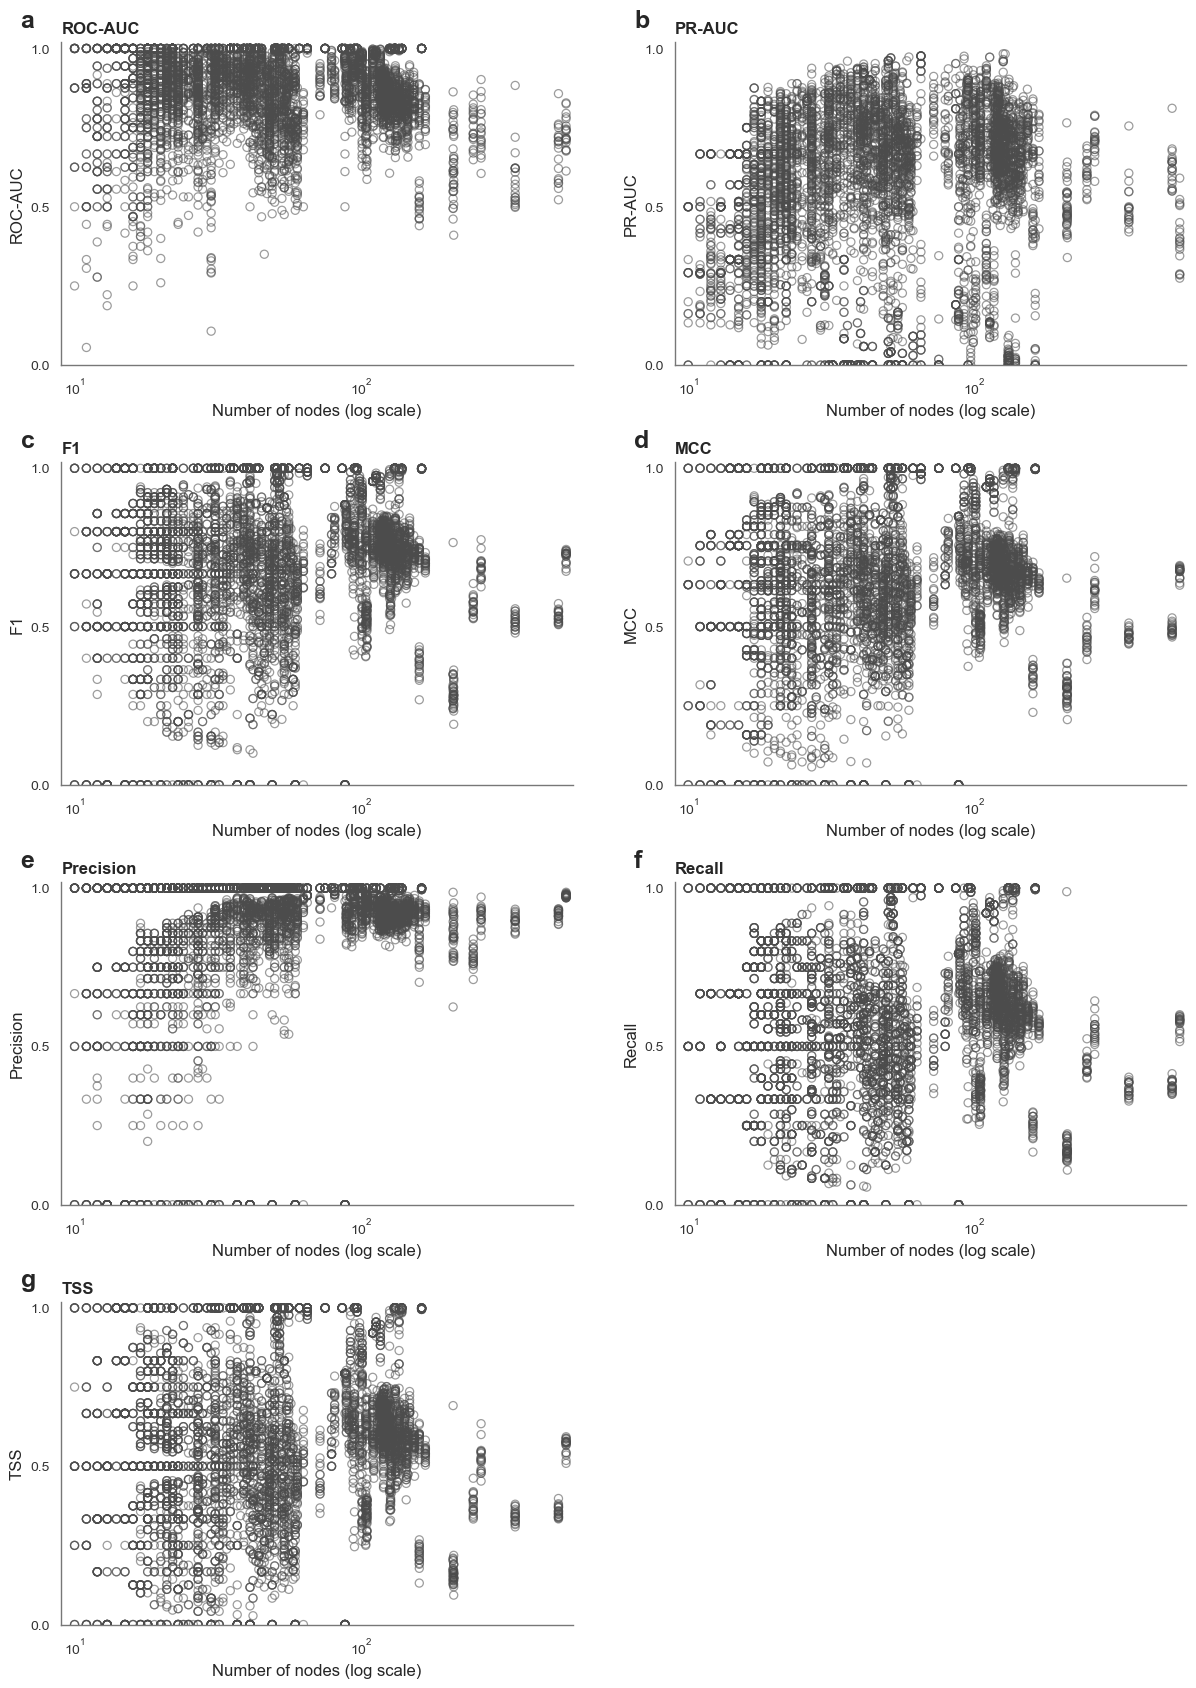

In [46]:
import os
import glob
import math
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "qmul_phd_framework_mplconfig"),
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.ticker import FormatStrFormatter, FixedLocator


sns.set_theme(style="white", context="paper", font_scale=1.2)

# ============================================================
# Config
# ============================================================

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()

    for path in [start, *start.parents]:
        if (path / "src/matlab").is_dir() and (path / "docs").is_dir():
            return path

    raise FileNotFoundError("Could not find project root from current working directory.")


PROJECT_ROOT = find_project_root()

RESULTS_DIR = PROJECT_ROOT / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs"
ECOSYSTEM_FILE = PROJECT_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
RESULTS_PATTERN = "*_results_*.csv"

K_TARGET = 10
TARGET_RATIO = 90.0
MIN_NODES = 0
AGGREGATE_REPEATS = False

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

Y_MIN = 0.0
Y_MAX = 1.0
Y_PAD_TOP = 0.02
X_MAX = 550
N_COLS = 2

POINT_COLOR = "#4C4C4C"
POINT_MARKER = "o"
POINT_SIZE = 34
POINT_ALPHA = 0.55
POINT_LINEWIDTH = 0.9

X_TICKS = [10, 20, 50, 100, 200, 500]


# ============================================================
# Helpers
# ============================================================

def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb_name(s: str) -> str:
    s = str(s).strip()
    s = s.replace(".mat", "")
    s = s.replace(".csv", "")
    s = s.replace(" ", "_")
    return "_".join(part for part in s.split("_") if part).lower()


def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}

    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]

    raise KeyError(f"Could not find any of these columns: {candidates}")


def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]


def normalize_train_ratio(series):
    values = pd.to_numeric(series, errors="coerce")
    return np.where(values <= 1.0, values * 100.0, values)


def report_foodweb_count(stage_name: str, before: set, after: set) -> None:
    print(f"[CHECK] {stage_name}: {len(before)} -> {len(after)} food webs")


def format_p_value(p_value: float) -> str:
    if pd.isna(p_value):
        return "P = NA"
    if p_value < 0.0001:
        return "P < 0.0001"
    return f"P = {p_value:.4f}"


def format_log_equation(intercept: float, slope: float) -> str:
    sign = "+" if slope >= 0 else "-"
    return f"y = {intercept:.4f} {sign} {abs(slope):.4f}log10(x)"


def format_raw_equation(intercept: float, slope: float) -> str:
    sign = "+" if slope >= 0 else "-"
    return f"y = {intercept:.4f} {sign} {abs(slope):.4f}x"


# ============================================================
# Data loading
# ============================================================

def load_results(results_dir: Path, pattern: str) -> pd.DataFrame:
    files = sorted(glob.glob(str(results_dir / pattern)))

    if not files:
        raise FileNotFoundError(
            f"No result CSV files found in {results_dir} matching {pattern}"
        )

    frames = []

    for path in files:
        df = pd.read_csv(path).copy()

        foodweb = extract_foodweb_name(path)
        foodweb_key = normalize_foodweb_name(foodweb)

        file_meta = pd.DataFrame(
            {
                "Foodweb": foodweb,
                "FoodwebKey": foodweb_key,
            },
            index=df.index,
        )

        df = pd.concat([df, file_meta], axis=1).copy()
        frames.append(df)

    out = pd.concat(frames, ignore_index=True).copy()

    print(f"[INFO] Result files found: {len(files)}")
    print(f"[INFO] Food webs in result files before filtering: {out['Foodweb'].nunique()}")

    return out


def load_foodweb_metadata(path: Path) -> pd.DataFrame:
    meta = pd.read_csv(path).copy()

    foodweb_col = find_column(meta, ["foodweb"])
    ecosystem_col = find_column(meta, ["ecosystemtype", "ecosystem", "ecosystem_type"])
    nodes_col = find_column(meta, ["nodes", "n_nodes", "num_nodes", "nodecount", "s"])

    meta = meta.rename(
        columns={
            foodweb_col: "MetadataFoodweb",
            ecosystem_col: "EcosystemType",
            nodes_col: "Nodes",
        }
    )

    meta = meta[
        [
            "MetadataFoodweb",
            "EcosystemType",
            "Nodes",
        ]
    ].copy()

    meta["MetadataFoodweb"] = meta["MetadataFoodweb"].astype(str)
    meta["FoodwebKey"] = meta["MetadataFoodweb"].apply(normalize_foodweb_name)
    meta["EcosystemType"] = meta["EcosystemType"].astype(str).str.strip()
    meta["Nodes"] = pd.to_numeric(meta["Nodes"], errors="coerce")

    meta = meta.drop_duplicates(subset=["FoodwebKey"]).copy()

    print(f"[INFO] Food webs in metadata file: {meta['FoodwebKey'].nunique()}")

    return meta


# ============================================================
# Data preparation
# ============================================================

def prepare_plot_data(results: pd.DataFrame, metadata: pd.DataFrame) -> pd.DataFrame:
    df = results.merge(metadata, on="FoodwebKey", how="left").copy()

    rename_map = {}

    if "ROC_AUC" not in df.columns and "AUC" in df.columns:
        rename_map["AUC"] = "ROC_AUC"

    if "TestMCC" not in df.columns and "MCC" in df.columns:
        rename_map["MCC"] = "TestMCC"

    if rename_map:
        df = df.rename(columns=rename_map).copy()

    numeric_cols = [
        "K",
        "TrainRatio",
        "ROC_AUC",
        "PR_AUC",
        "Precision",
        "Recall",
        "F1Score",
        "TestMCC",
        "TestTSS",
        "Nodes",
    ]

    existing_numeric_cols = [col for col in numeric_cols if col in df.columns]

    if existing_numeric_cols:
        df[existing_numeric_cols] = df[existing_numeric_cols].apply(
            pd.to_numeric,
            errors="coerce",
        )

    if "TrainRatio" not in df.columns:
        raise RuntimeError("Column 'TrainRatio' not found in result CSVs.")

    df["TrainRatio"] = normalize_train_ratio(df["TrainRatio"])
    df["EcosystemType"] = df["EcosystemType"].fillna("Unknown")

    before = set(df["Foodweb"].dropna().unique())

    if K_TARGET is not None:
        if "K" not in df.columns:
            raise RuntimeError("Column 'K' not found in result CSVs.")

        df = df[np.isclose(df["K"], K_TARGET, equal_nan=False)].copy()
        after = set(df["Foodweb"].dropna().unique())
        report_foodweb_count(f"K = {K_TARGET}", before, after)
        before = after

    df = df[np.isclose(df["TrainRatio"], TARGET_RATIO, equal_nan=False)].copy()
    after = set(df["Foodweb"].dropna().unique())
    report_foodweb_count(f"TrainRatio = {TARGET_RATIO:.4f}", before, after)
    before = after

    df = df[df["Nodes"].notna()].copy()
    df = df[df["Nodes"] > 0].copy()

    if MIN_NODES > 0:
        df = df[df["Nodes"] >= MIN_NODES].copy()
    else:
        df = df[df["Nodes"] >= MIN_NODES].copy()

    after = set(df["Foodweb"].dropna().unique())
    report_foodweb_count(f"Nodes >= {MIN_NODES}", before, after)

    missing_metrics = [
        metric
        for metric, _ in METRIC_SPECS
        if metric not in df.columns
    ]

    if missing_metrics:
        raise RuntimeError(f"Missing required metric columns: {missing_metrics}")

    if AGGREGATE_REPEATS:
        group_cols = [
            "Foodweb",
            "FoodwebKey",
            "K",
            "TrainRatio",
            "Nodes",
            "EcosystemType",
        ]

        mean_cols = [metric for metric, _ in METRIC_SPECS]

        df = (
            df.groupby(group_cols, dropna=False, as_index=False)[mean_cols]
            .mean()
            .copy()
        )

    metric_cols = [metric for metric, _ in METRIC_SPECS]

    metric_availability = (
        df[["Foodweb", *metric_cols]]
        .assign(HasAnySelectedMetric=lambda x: x[metric_cols].notna().any(axis=1))
        .copy()
    )

    foodwebs_without_metrics = (
        metric_availability.loc[
            ~metric_availability["HasAnySelectedMetric"],
            "Foodweb",
        ]
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    print(f"[FINAL] Food webs retained after filters: {df['Foodweb'].nunique()}")
    print(f"[FINAL] Rows retained after filters: {len(df)}")

    if foodwebs_without_metrics:
        print(
            "[INFO] Food webs retained but not plotted in metric panels "
            "because all selected metrics are missing:"
        )
        for fw in foodwebs_without_metrics:
            print(f"  - {fw}")

    return df.copy()


# ============================================================
# Regression helpers
# ============================================================

def fit_logx_linear_regression(
    data: pd.DataFrame,
    x_col: str,
    y_col: str,
):
    """
    Fits:

        y_col ~ log10(x_col)
    """
    work = data[[x_col, y_col]].dropna().copy()

    if work.empty:
        return None

    work[x_col] = pd.to_numeric(work[x_col], errors="coerce")
    work[y_col] = pd.to_numeric(work[y_col], errors="coerce")
    work = work[(work[x_col] > 0) & work[y_col].notna()].copy()

    if len(work) < 3 or work[x_col].nunique() < 2:
        return None

    work["log10_x"] = np.log10(work[x_col])

    x = work[["log10_x"]]
    y = work[y_col]

    x_model = sm.add_constant(x, has_constant="add")
    model = sm.OLS(y, x_model).fit()

    intercept = model.params["const"]
    slope = model.params["log10_x"]

    return {
        "intercept": intercept,
        "slope": slope,
        "r_squared": model.rsquared,
        "p_value": model.pvalues["log10_x"],
        "f_value": model.fvalue,
        "df_model": int(model.df_model),
        "df_resid": int(model.df_resid),
        "n": len(work),
        "model": model,
    }


def fit_rawx_linear_regression(
    data: pd.DataFrame,
    x_col: str,
    y_col: str,
):
    """
    Fits:

        y_col ~ x_col
    """
    work = data[[x_col, y_col]].dropna().copy()

    if work.empty:
        return None

    work[x_col] = pd.to_numeric(work[x_col], errors="coerce")
    work[y_col] = pd.to_numeric(work[y_col], errors="coerce")
    work = work[(work[x_col] > 0) & work[y_col].notna()].copy()

    if len(work) < 3 or work[x_col].nunique() < 2:
        return None

    x = work[[x_col]]
    y = work[y_col]

    x_model = sm.add_constant(x, has_constant="add")
    model = sm.OLS(y, x_model).fit()

    intercept = model.params["const"]
    slope = model.params[x_col]

    return {
        "intercept": intercept,
        "slope": slope,
        "r_squared": model.rsquared,
        "p_value": model.pvalues[x_col],
        "f_value": model.fvalue,
        "df_model": int(model.df_model),
        "df_resid": int(model.df_resid),
        "n": len(work),
        "model": model,
    }


def regression_result_text(
    panel_letter: str,
    metric_label: str,
    model_label: str,
    equation: str,
    fit: dict,
) -> str:
    p_text = format_p_value(fit["p_value"])

    return (
        f"{panel_letter}) {metric_label} [{model_label}]: "
        f"{equation}; "
        f"F{fit['df_model']},{fit['df_resid']} = {fit['f_value']:.4f}; "
        f"R² = {fit['r_squared']:.4f}; "
        f"{p_text}; "
        f"n = {fit['n']}"
    )


# ============================================================
# Plotting
# ============================================================

def style_axes(ax, ylabel: str) -> None:
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Number of nodes (log scale)", fontsize=12)
    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#777777")
    ax.spines["bottom"].set_color("#777777")

    ax.tick_params(colors="#333333", labelsize=10)

    ax.xaxis.set_major_locator(FixedLocator(X_TICKS))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))


def plot_performance_vs_nodes(plot_df: pd.DataFrame):
    n_panels = len(METRIC_SPECS)
    n_rows = math.ceil(n_panels / N_COLS)

    fig, axes = plt.subplots(
        n_rows,
        N_COLS,
        figsize=(12.5, 4.6 * n_rows),
        sharex=False,
        sharey=False,
    )

    axes = np.array(axes).reshape(-1)
    panel_letters = list("abcdefghijklmnopqrstuvwxyz")

    total_foodwebs = plot_df["Foodweb"].nunique()

    x_min = max(1.0, plot_df["Nodes"].min() * 0.90)
    x_max = plot_df["Nodes"].max() * 1.10

    if X_MAX is not None:
        x_max = min(X_MAX, x_max)

    if x_min >= x_max:
        x_min = max(1.0, plot_df["Nodes"].min())
        x_max = plot_df["Nodes"].max() * 1.10

    print("\n=== OLS linear regressions for caption ===")
    print("Models fitted:")
    print("  1) metric ~ log10(number of nodes)")
    print("  2) metric ~ number of nodes")
    print("Regression lines are not shown in the figure.\n")

    caption_log_results = []
    caption_raw_results = []

    for i, ((metric, label), ax) in enumerate(zip(METRIC_SPECS, axes)):
        data = plot_df.dropna(subset=["Nodes", metric]).copy()

        ax.scatter(
            data["Nodes"],
            data[metric],
            marker=POINT_MARKER,
            facecolors="none",
            edgecolors=POINT_COLOR,
            linewidths=POINT_LINEWIDTH,
            s=POINT_SIZE,
            alpha=POINT_ALPHA,
            zorder=3,
        )

        fit_log = fit_logx_linear_regression(data, "Nodes", metric)
        fit_raw = fit_rawx_linear_regression(data, "Nodes", metric)

        if fit_log is not None:
            equation_log = format_log_equation(
                fit_log["intercept"],
                fit_log["slope"],
            )

            result_log = regression_result_text(
                panel_letter=panel_letters[i],
                metric_label=label,
                model_label="log10 nodes",
                equation=equation_log,
                fit=fit_log,
            )

            caption_log_results.append(result_log)
            print(result_log)

        else:
            print(
                f"{panel_letters[i]}) {label} [log10 nodes]: "
                "regression not fitted; insufficient data."
            )

        if fit_raw is not None:
            equation_raw = format_raw_equation(
                fit_raw["intercept"],
                fit_raw["slope"],
            )

            result_raw = regression_result_text(
                panel_letter=panel_letters[i],
                metric_label=label,
                model_label="raw nodes",
                equation=equation_raw,
                fit=fit_raw,
            )

            caption_raw_results.append(result_raw)
            print(result_raw)

        else:
            print(
                f"{panel_letters[i]}) {label} [raw nodes]: "
                "regression not fitted; insufficient data."
            )

        print("")

        style_axes(ax, label)

        ax.set_title(label, loc="left", fontweight="bold", fontsize=12)
        ax.set_xscale("log")
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(Y_MIN, Y_MAX + Y_PAD_TOP)
        ax.set_yticks([0.0, 0.5, 1.0])

        ax.text(
            -0.08,
            1.03,
            panel_letters[i],
            transform=ax.transAxes,
            fontsize=18,
            fontweight="bold",
            va="bottom",
            ha="left",
            clip_on=False,
        )

    for j in range(n_panels, len(axes)):
        axes[j].set_axis_off()

    fig.subplots_adjust(
        top=0.95,
        hspace=0.3,
        wspace=0.2,
        left=0.08,
        right=0.98,
        bottom=0.09,
    )

    print(f"[INFO] Figure uses individual data points at TrainRatio = {TARGET_RATIO:.4f}.")
    print(f"[INFO] Total food webs represented after filtering: {total_foodwebs}")

    print("\n=== Regression results for figure caption: log10 nodes ===")
    print(
        "OLS regressions were fitted as metric ~ log10(number of nodes). "
        "Regression lines are not shown in the figure. Results: "
        + "; ".join(caption_log_results)
    )

    print("\n=== Regression results for figure caption: raw nodes ===")
    print(
        "OLS regressions were fitted as metric ~ number of nodes. "
        "Regression lines are not shown in the figure. Results: "
        + "; ".join(caption_raw_results)
    )

    return fig


# ============================================================
# Run
# ============================================================

results = load_results(RESULTS_DIR, RESULTS_PATTERN)
metadata = load_foodweb_metadata(ECOSYSTEM_FILE)
plot_df = prepare_plot_data(results, metadata)

fig = plot_performance_vs_nodes(plot_df)
plt.show()

### Apocrita equivalence-test files

global: src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/statistical_tests/lachlan/wlnm_dir_neg_delta_equivalence_train60.csv
ecosystem: src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/statistical_tests/lachlan/wlnm_dir_neg_delta_equivalence_train60_by_ecosystem.csv
margins: src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/statistical_tests/lachlan/wlnm_dir_neg_delta_equivalence_margins.csv


## Apocrita: global equivalence summary

,Metric,NumFoodWebs,MeanEmpirical,MeanPseudo,MeanDelta,CILower,CIUpper,LowerMargin,UpperMargin,TOSTPValue,Equivalent,Conclusion
0,Connectance,290,0.1324,0.1142,-0.0181,-0.0193,-0.0170,-0.0100,0.0100,1,False,Not equivalent: pseudo lower
1,MeanTrophicLevel,290,2.1841,2.8868,0.7028,0.5650,0.8405,-0.1000,0.1000,1,False,Not equivalent: pseudo higher
2,MeanDegree,290,14.5552,12.3645,-2.1907,-2.4323,-1.9491,-0.5000,0.5000,1,False,Not equivalent: pseudo lower
3,MeanGenerality,290,10.5377,8.9581,-1.5796,-1.7572,-1.4020,-0.5000,0.5000,1,False,Not equivalent: pseudo lower
4,MeanVulnerability,290,8.2904,7.0939,-1.1965,-1.3291,-1.0640,-0.5000,0.5000,1,False,Not equivalent: pseudo lower
5,PropBasal,290,0.3211,0.3032,-0.0179,-0.0205,-0.0153,-0.0500,0.0500,5.08e-127,True,Equivalent
6,PropIntermediate,290,0.5184,0.5274,0.0090,0.0047,0.0133,-0.0500,0.0500,2.84e-41,True,Equivalent
7,PropTop,290,0.1603,0.1545,-0.0059,-0.0088,-0.0029,-0.0500,0.0500,1.93e-94,True,Equivalent


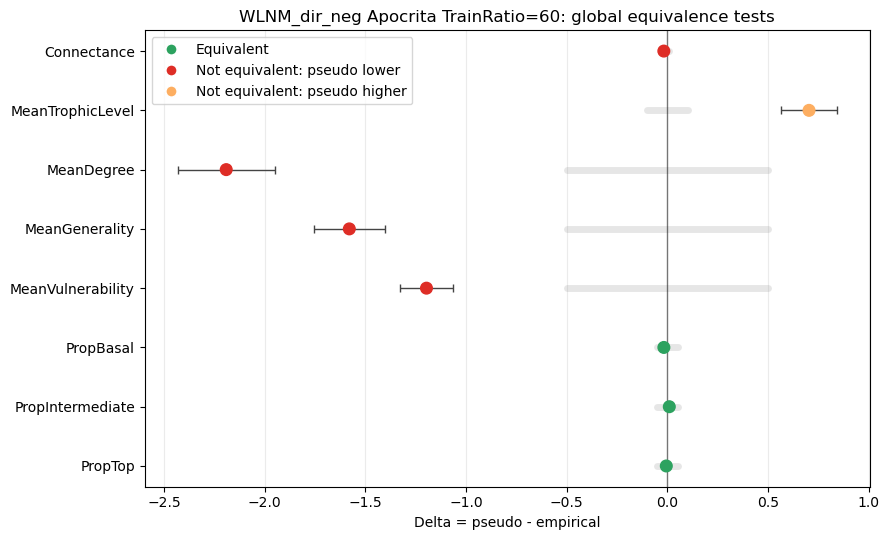

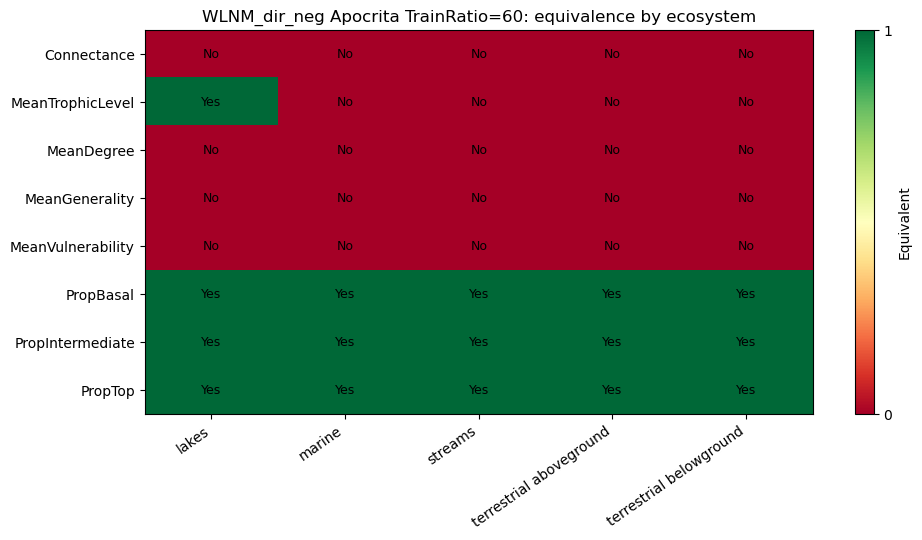

## Connectance detail

,NumFoodWebs,MeanEmpirical,MeanPseudo,MeanDelta,CILower,CIUpper,LowerMargin,UpperMargin,TOSTPValue,Equivalent,Conclusion
0,290,0.1324,0.1142,-0.0181,-0.0193,-0.0170,-0.0100,0.0100,1,False,Not equivalent: pseudo lower


## Equivalence margins used

,Metric,LowerMargin,UpperMargin,MarginMode,Justification
0,Connectance,-0.01,0.01,absolute,One percentage point on a 0-1 connectance scal...
1,MeanTrophicLevel,-0.10,0.10,absolute,A tenth of a trophic level is below a coarse e...
2,MeanDegree,-0.50,0.50,absolute,Half an interaction per species on average is ...
3,MeanGenerality,-0.50,0.50,absolute,Half a prey item per consumer on average is a ...
4,MeanVulnerability,-0.50,0.50,absolute,Half a consumer per resource on average is a s...
5,PropBasal,-0.05,0.05,absolute,Five percentage points is a small change in sp...
6,PropIntermediate,-0.05,0.05,absolute,Five percentage points is a small change in sp...
7,PropTop,-0.05,0.05,absolute,Five percentage points is a small change in sp...
8,DegreeStd,-0.50,0.50,absolute,Half an interaction on the degree-dispersion s...
9,DegreeCV,-0.10,0.10,absolute,Ten percentage points is a small relative-disp...


In [3]:
# %% Equivalence tests: WLNM_dir_neg Apocrita TrainRatio=60

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown


def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists():
            return p
    raise FileNotFoundError("Could not find project root containing src/matlab")


ROOT = find_project_root()
RESULTS_DIR = (
    ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/statistical_tests/lachlan"
)

files = {
    "global": RESULTS_DIR / "wlnm_dir_neg_delta_equivalence_train60.csv",
    "ecosystem": RESULTS_DIR / "wlnm_dir_neg_delta_equivalence_train60_by_ecosystem.csv",
    "margins": RESULTS_DIR / "wlnm_dir_neg_delta_equivalence_margins.csv",
}

tables = {kind: pd.read_csv(path) for kind, path in files.items()}

display(Markdown("### Apocrita equivalence-test files"))
for kind, path in files.items():
    print(f"{kind}: {path.relative_to(ROOT)}")


# %% Helpers

CORE_METRICS = [
    "Connectance",
    "MeanTrophicLevel",
    "MeanDegree",
    "MeanGenerality",
    "MeanVulnerability",
    "PropBasal",
    "PropIntermediate",
    "PropTop",
]

CONCLUSION_ORDER = {
    "Equivalent": 0,
    "Not equivalent: pseudo lower": 1,
    "Not equivalent: pseudo higher": 2,
    "Not equivalent": 3,
}


def add_conclusion(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["Equivalent"] = out["Equivalent"].astype(bool)
    out["Conclusion"] = np.where(
        out["Equivalent"],
        "Equivalent",
        np.where(
            out["MeanDelta"] < out["LowerMargin"],
            "Not equivalent: pseudo lower",
            np.where(
                out["MeanDelta"] > out["UpperMargin"],
                "Not equivalent: pseudo higher",
                "Not equivalent",
            ),
        ),
    )
    return out


def compact_global_table(df: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "Metric",
        "NumFoodWebs",
        "MeanEmpirical",
        "MeanPseudo",
        "MeanDelta",
        "CILower",
        "CIUpper",
        "LowerMargin",
        "UpperMargin",
        "TOSTPValue",
        "Equivalent",
    ]
    out = df.loc[df["Metric"].isin(CORE_METRICS), cols].copy()
    out = add_conclusion(out)
    out["Metric"] = pd.Categorical(out["Metric"], CORE_METRICS, ordered=True)
    return out.sort_values("Metric")


def styled_equivalence_table(df: pd.DataFrame):
    def color_conclusion(value):
        colors = {
            "Equivalent": "background-color: #d7f5dd",
            "Not equivalent: pseudo lower": "background-color: #f8d7da",
            "Not equivalent: pseudo higher": "background-color: #ffe8bf",
            "Not equivalent": "background-color: #f8d7da",
        }
        return colors.get(value, "")

    styler = (
        compact_global_table(df)
        .style
        .format({
            "MeanEmpirical": "{:.4f}",
            "MeanPseudo": "{:.4f}",
            "MeanDelta": "{:.4f}",
            "CILower": "{:.4f}",
            "CIUpper": "{:.4f}",
            "LowerMargin": "{:.4f}",
            "UpperMargin": "{:.4f}",
            "TOSTPValue": "{:.3g}",
        })
        .background_gradient(subset=["MeanDelta"], cmap="coolwarm")
    )

    if hasattr(styler, "map"):
        return styler.map(color_conclusion, subset=["Conclusion"])

    return styler.applymap(color_conclusion, subset=["Conclusion"])


def plot_global_equivalence(df: pd.DataFrame, title: str):
    plot_df = compact_global_table(df).copy()
    y = np.arange(len(plot_df))
    mean = plot_df["MeanDelta"].to_numpy()
    low = plot_df["CILower"].to_numpy()
    high = plot_df["CIUpper"].to_numpy()
    xerr = np.vstack([mean - low, high - mean])

    color_map = {
        "Equivalent": "#2ca25f",
        "Not equivalent: pseudo lower": "#de2d26",
        "Not equivalent: pseudo higher": "#fdae61",
        "Not equivalent": "#de2d26",
    }
    colors = plot_df["Conclusion"].map(color_map).to_numpy()

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.errorbar(mean, y, xerr=xerr, fmt="none", ecolor="#444", capsize=3, lw=1)
    ax.scatter(mean, y, s=70, c=colors, zorder=3)

    for idx, row in plot_df.reset_index(drop=True).iterrows():
        ax.plot(
            [row["LowerMargin"], row["UpperMargin"]],
            [idx, idx],
            color="#9e9e9e",
            lw=5,
            alpha=0.25,
            solid_capstyle="round",
        )

    ax.axvline(0, color="black", lw=1, alpha=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["Metric"])
    ax.invert_yaxis()
    ax.set_xlabel("Delta = pseudo - empirical")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.25)

    handles = [
        plt.Line2D([0], [0], marker="o", color="w", label="Equivalent", markerfacecolor="#2ca25f", markersize=8),
        plt.Line2D([0], [0], marker="o", color="w", label="Not equivalent: pseudo lower", markerfacecolor="#de2d26", markersize=8),
        plt.Line2D([0], [0], marker="o", color="w", label="Not equivalent: pseudo higher", markerfacecolor="#fdae61", markersize=8),
    ]
    ax.legend(handles=handles, loc="best")
    plt.tight_layout()
    plt.show()


def plot_ecosystem_equivalence(df: pd.DataFrame, title: str):
    eco_df = df[df["Metric"].isin(CORE_METRICS)].copy()
    eco_df["Equivalent"] = eco_df["Equivalent"].astype(int)

    pivot = eco_df.pivot_table(
        index="Metric",
        columns="EcosystemType",
        values="Equivalent",
        aggfunc="max",
    )

    metric_order = [m for m in CORE_METRICS if m in pivot.index]
    pivot = pivot.loc[metric_order]

    fig, ax = plt.subplots(figsize=(10, 5.5))
    im = ax.imshow(pivot.to_numpy(), aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.iloc[i, j]
            label = "" if pd.isna(val) else ("Yes" if val == 1 else "No")
            ax.text(j, i, label, ha="center", va="center", fontsize=9)

    ax.set_title(title)
    plt.colorbar(im, ax=ax, ticks=[0, 1], label="Equivalent")
    plt.tight_layout()
    plt.show()


# %% Global table

display(Markdown("## Apocrita: global equivalence summary"))
display(styled_equivalence_table(tables["global"]))


# %% Global plot

plot_global_equivalence(
    tables["global"],
    "WLNM_dir_neg Apocrita TrainRatio=60: global equivalence tests",
)


# %% Ecosystem heatmap

plot_ecosystem_equivalence(
    tables["ecosystem"],
    "WLNM_dir_neg Apocrita TrainRatio=60: equivalence by ecosystem",
)


# %% Connectance detail

connectance_detail = tables["global"].query("Metric == 'Connectance'").copy()
connectance_detail = add_conclusion(connectance_detail)

display(Markdown("## Connectance detail"))
display(
    connectance_detail[
        [
            "NumFoodWebs",
            "MeanEmpirical",
            "MeanPseudo",
            "MeanDelta",
            "CILower",
            "CIUpper",
            "LowerMargin",
            "UpperMargin",
            "TOSTPValue",
            "Equivalent",
            "Conclusion",
        ]
    ].style.format({
        "MeanEmpirical": "{:.4f}",
        "MeanPseudo": "{:.4f}",
        "MeanDelta": "{:.4f}",
        "CILower": "{:.4f}",
        "CIUpper": "{:.4f}",
        "LowerMargin": "{:.4f}",
        "UpperMargin": "{:.4f}",
        "TOSTPValue": "{:.3g}",
    })
)


# %% Margins used

display(Markdown("## Equivalence margins used"))
display(tables["margins"])


## TrainRatio=60: run summary

,LogFiles,RawRows,MatchedTrainRatioRows,DeltaRecords,TrainRatio,TrainRatioLabel,MetricsConfigured,MetricsFitted,MetricsSkipped,OutputDir,OutputGlobal,OutputByEcosystem
0,290,52200,5800,138980,60.0,train_ratio_60,24,24,0,src/matlab/data/result_wlnm_dir_neg_sweep_trai...,src/matlab/data/result_wlnm_dir_neg_sweep_trai...,src/matlab/data/result_wlnm_dir_neg_sweep_trai...


## TrainRatio=60: skipped metrics

,Metric,Reason


## TrainRatio=60: core global mixed-effects equivalence

,Metric,EcosystemType,NumFoodWebs,NumRows,EstimatedDelta,SE,90% CI,Margin,ICC,Conclusion
0,Connectance,all,290,5800,-0.0181,0.0007,"[-0.0193, -0.0170]","[-0.0100, 0.0100]",0.631,Not equivalent: pseudo lower
1,MeanTrophicLevel,all,290,5745,0.6987,0.0831,"[0.5615, 0.8359]","[-0.1000, 0.1000]",0.084,Not equivalent: pseudo higher
2,MeanDegree,all,290,5800,-2.1907,0.1464,"[-2.4323, -1.9491]","[-0.5000, 0.5000]",0.905,Not equivalent: pseudo lower
3,MeanGenerality,all,290,5800,-1.5796,0.1076,"[-1.7572, -1.4020]","[-0.5000, 0.5000]",0.892,Not equivalent: pseudo lower
4,MeanVulnerability,all,290,5800,-1.1965,0.0803,"[-1.3291, -1.0640]","[-0.5000, 0.5000]",0.895,Not equivalent: pseudo lower
5,PropBasal,all,290,5800,-0.0179,0.0016,"[-0.0205, -0.0153]","[-0.0500, 0.0500]",0.251,Equivalent / close enough
6,PropIntermediate,all,290,5800,0.0090,0.0026,"[0.0047, 0.0133]","[-0.0500, 0.0500]",0.339,Equivalent / close enough
7,PropTop,all,290,5800,-0.0059,0.0018,"[-0.0088, -0.0029]","[-0.0500, 0.0500]",0.273,Equivalent / close enough


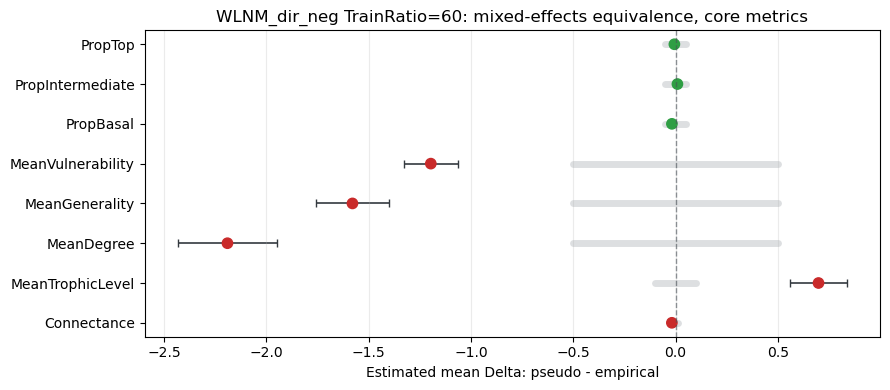

## TrainRatio=60: all global mixed-effects equivalence

,Metric,EcosystemType,NumFoodWebs,NumRows,EstimatedDelta,SE,90% CI,Margin,ICC,Conclusion
0,Connectance,all,290,5800,-0.0181,0.0007,"[-0.0193, -0.0170]","[-0.0100, 0.0100]",0.631,Not equivalent: pseudo lower
1,MeanTrophicLevel,all,290,5745,0.6987,0.0831,"[0.5615, 0.8359]","[-0.1000, 0.1000]",0.084,Not equivalent: pseudo higher
2,MeanDegree,all,290,5800,-2.1907,0.1464,"[-2.4323, -1.9491]","[-0.5000, 0.5000]",0.905,Not equivalent: pseudo lower
3,MeanGenerality,all,290,5800,-1.5796,0.1076,"[-1.7572, -1.4020]","[-0.5000, 0.5000]",0.892,Not equivalent: pseudo lower
4,MeanVulnerability,all,290,5800,-1.1965,0.0803,"[-1.3291, -1.0640]","[-0.5000, 0.5000]",0.895,Not equivalent: pseudo lower
5,PropBasal,all,290,5800,-0.0179,0.0016,"[-0.0205, -0.0153]","[-0.0500, 0.0500]",0.251,Equivalent / close enough
6,PropIntermediate,all,290,5800,0.0090,0.0026,"[0.0047, 0.0133]","[-0.0500, 0.0500]",0.339,Equivalent / close enough
7,PropTop,all,290,5800,-0.0059,0.0018,"[-0.0088, -0.0029]","[-0.0500, 0.0500]",0.273,Equivalent / close enough
8,DegreeStd,all,290,5800,-1.4428,0.1232,"[-1.6461, -1.2395]","[-0.5000, 0.5000]",0.961,Not equivalent: pseudo lower
9,DegreeCV,all,290,5800,0.0204,0.0030,"[0.0154, 0.0253]","[-0.1000, 0.1000]",0.585,Equivalent / close enough


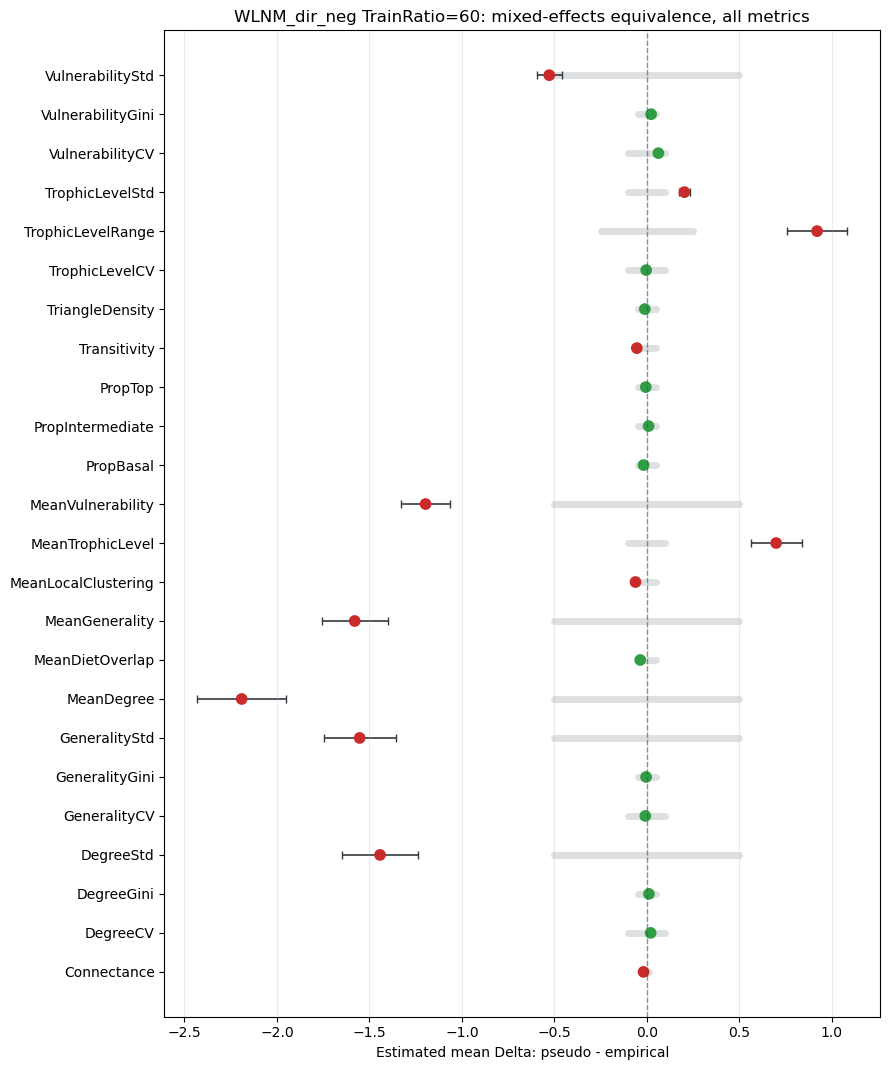

## TrainRatio=60: connectance by ecosystem

,Metric,EcosystemType,NumFoodWebs,NumRows,EstimatedDelta,SE,90% CI,Margin,ICC,Conclusion
0,Connectance,marine,134,2680,-0.0211,0.0010,"[-0.0227, -0.0194]","[-0.0100, 0.0100]",0.616,Not equivalent: pseudo lower
1,Connectance,streams,28,560,-0.0193,0.0022,"[-0.0229, -0.0157]","[-0.0100, 0.0100]",0.616,Not equivalent: pseudo lower
2,Connectance,lakes,55,1100,-0.0135,0.0016,"[-0.0161, -0.0109]","[-0.0100, 0.0100]",0.616,Not equivalent: pseudo lower
3,Connectance,terrestrial aboveground,21,420,-0.0130,0.0025,"[-0.0172, -0.0088]","[-0.0100, 0.0100]",0.616,Not equivalent: pseudo lower
4,Connectance,terrestrial belowground,52,1040,-0.0169,0.0016,"[-0.0196, -0.0143]","[-0.0100, 0.0100]",0.616,Not equivalent: pseudo lower


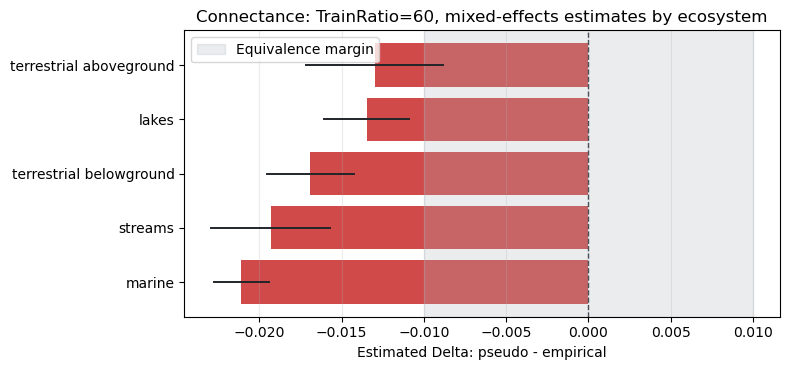

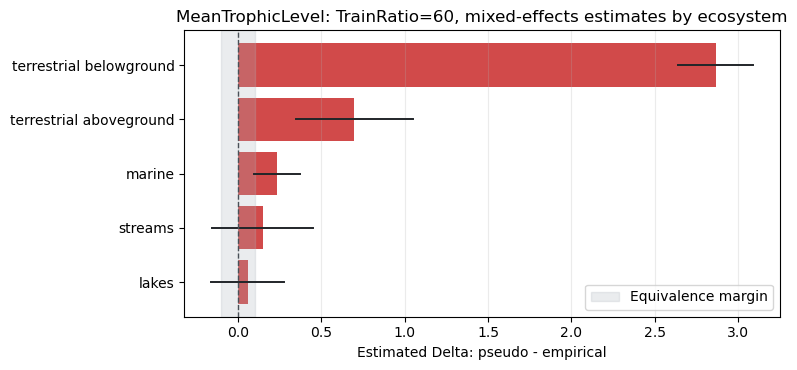

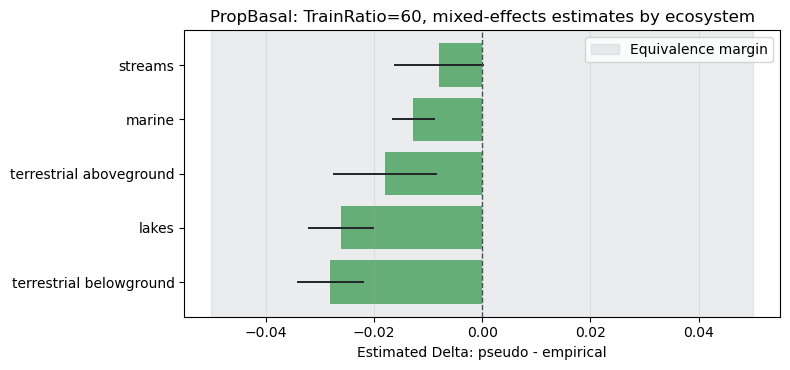

## TrainRatio=60: core metrics by ecosystem

,Metric,EcosystemType,NumFoodWebs,NumRows,EstimatedDelta,SE,90% CI,Margin,ICC,Conclusion
0,Connectance,marine,134,2680,-0.0211,0.0010,"[-0.0227, -0.0194]","[-0.0100, 0.0100]",0.616,Not equivalent: pseudo lower
1,Connectance,streams,28,560,-0.0193,0.0022,"[-0.0229, -0.0157]","[-0.0100, 0.0100]",0.616,Not equivalent: pseudo lower
2,Connectance,lakes,55,1100,-0.0135,0.0016,"[-0.0161, -0.0109]","[-0.0100, 0.0100]",0.616,Not equivalent: pseudo lower
3,Connectance,terrestrial aboveground,21,420,-0.0130,0.0025,"[-0.0172, -0.0088]","[-0.0100, 0.0100]",0.616,Not equivalent: pseudo lower
4,Connectance,terrestrial belowground,52,1040,-0.0169,0.0016,"[-0.0196, -0.0143]","[-0.0100, 0.0100]",0.616,Not equivalent: pseudo lower
5,MeanTrophicLevel,marine,134,2669,0.2330,0.0841,"[0.0943, 0.3717]","[-0.1000, 0.1000]",0.017,Not equivalent: pseudo higher
6,MeanTrophicLevel,streams,28,560,0.1486,0.1836,"[-0.1544, 0.4515]","[-0.1000, 0.1000]",0.017,Not equivalent: pseudo higher
7,MeanTrophicLevel,lakes,55,1083,0.0581,0.1318,"[-0.1595, 0.2756]","[-0.1000, 0.1000]",0.017,Not equivalent: CI crosses margin
8,MeanTrophicLevel,terrestrial aboveground,21,410,0.6984,0.2140,"[0.3453, 1.0514]","[-0.1000, 0.1000]",0.017,Not equivalent: pseudo higher
9,MeanTrophicLevel,terrestrial belowground,52,1023,2.8656,0.1356,"[2.6419, 3.0893]","[-0.1000, 0.1000]",0.017,Not equivalent: pseudo higher


In [12]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# ---------- Paths ----------

REPO_ROOT = Path("/Users/acw792/Developer/qmul-phd-framework")

JORGE_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita"
    / "statistical_tests/jorge/train_ratio_60"
)

GLOBAL_CSV = JORGE_DIR / "mixed_effects_delta_train_ratio_60_global.csv"
ECOSYSTEM_CSV = JORGE_DIR / "mixed_effects_delta_train_ratio_60_by_ecosystem.csv"
MARGINS_CSV = JORGE_DIR / "mixed_effects_equivalence_margins_train_ratio_60.csv"
SUMMARY_CSV = JORGE_DIR / "mixed_effects_delta_train_ratio_60_run_summary.csv"
SKIPPED_CSV = JORGE_DIR / "mixed_effects_delta_train_ratio_60_skipped_metrics.csv"

global_df = pd.read_csv(GLOBAL_CSV)
ecosystem_df = pd.read_csv(ECOSYSTEM_CSV)
margins_df = pd.read_csv(MARGINS_CSV)
summary_df = pd.read_csv(SUMMARY_CSV)
skipped_df = pd.read_csv(SKIPPED_CSV)

CORE_METRICS = [
    "Connectance",
    "MeanTrophicLevel",
    "MeanDegree",
    "MeanGenerality",
    "MeanVulnerability",
    "PropBasal",
    "PropIntermediate",
    "PropTop",
]

# ---------- Helpers ----------

def conclusion(row):
    if int(row["Equivalent90"]) == 1:
        return "Equivalent / close enough"
    if row["Direction"] == "not_equivalent_pseudo_lower":
        return "Not equivalent: pseudo lower"
    if row["Direction"] == "not_equivalent_pseudo_higher":
        return "Not equivalent: pseudo higher"
    return "Not equivalent: CI crosses margin"


def add_display_columns(df):
    out = df.copy()
    out["90% CI"] = out.apply(
        lambda r: f"[{r['CI90Lower']:.4f}, {r['CI90Upper']:.4f}]",
        axis=1,
    )
    out["95% CI"] = out.apply(
        lambda r: f"[{r['CI95Lower']:.4f}, {r['CI95Upper']:.4f}]",
        axis=1,
    )
    out["Margin"] = out.apply(
        lambda r: f"[{r['LowerMargin']:.4f}, {r['UpperMargin']:.4f}]",
        axis=1,
    )
    out["Conclusion"] = out.apply(conclusion, axis=1)
    return out


def style_conclusion_table(df):
    display_df = add_display_columns(df)

    cols = [
        "Metric",
        "EcosystemType",
        "NumFoodWebs",
        "NumRows",
        "EstimatedDelta",
        "SE",
        "90% CI",
        "Margin",
        "ICC",
        "Conclusion",
    ]

    existing_cols = [c for c in cols if c in display_df.columns]

    styled = (
        display_df[existing_cols]
        .style
        .format({
            "EstimatedDelta": "{:.4f}",
            "SE": "{:.4f}",
            "ICC": "{:.3f}",
        })
        .background_gradient(subset=["EstimatedDelta"], cmap="coolwarm")
    )

    def color_conclusion(value):
        if value == "Equivalent / close enough":
            return "background-color: #d7f5dd; color: #14532d; font-weight: 600"
        return "background-color: #f8d7da; color: #7f1d1d; font-weight: 600"

    if hasattr(styled, "map"):
        styled = styled.map(color_conclusion, subset=["Conclusion"])
    else:
        styled = styled.applymap(color_conclusion, subset=["Conclusion"])

    return styled


def plot_global_effects(df, title, metrics=None):
    plot_df = df.copy()

    if metrics is not None:
        plot_df = plot_df[plot_df["Metric"].isin(metrics)].copy()
        plot_df["Metric"] = pd.Categorical(
            plot_df["Metric"],
            categories=metrics,
            ordered=True,
        )

    plot_df = plot_df.sort_values("Metric").reset_index(drop=True)

    y = range(len(plot_df))
    x = plot_df["EstimatedDelta"]
    xerr_lower = plot_df["EstimatedDelta"] - plot_df["CI90Lower"]
    xerr_upper = plot_df["CI90Upper"] - plot_df["EstimatedDelta"]
    colors = plot_df["Equivalent90"].map({1: "#2f9e44", 0: "#c92a2a"})

    fig, ax = plt.subplots(figsize=(9, max(4, 0.45 * len(plot_df))))

    for yi, row in plot_df.iterrows():
        ax.plot(
            [row["LowerMargin"], row["UpperMargin"]],
            [yi, yi],
            color="#868e96",
            linewidth=5,
            alpha=0.28,
            solid_capstyle="round",
            zorder=0,
        )

    ax.errorbar(
        x,
        y,
        xerr=[xerr_lower, xerr_upper],
        fmt="none",
        ecolor="#343a40",
        elinewidth=1.2,
        capsize=3,
        zorder=1,
    )

    ax.scatter(x, y, c=colors, s=55, zorder=2)

    ax.axvline(0, color="#495057", linewidth=1, linestyle="--", alpha=0.6)
    ax.set_yticks(list(y))
    ax.set_yticklabels(plot_df["Metric"])
    ax.set_xlabel("Estimated mean Delta: pseudo - empirical")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_ecosystem_heatmap(df, metric):
    plot_df = df[df["Metric"] == metric].copy()
    plot_df = plot_df.sort_values("EstimatedDelta")

    fig, ax = plt.subplots(figsize=(8, 3.8))
    colors = plot_df["Equivalent90"].map({1: "#2f9e44", 0: "#c92a2a"})

    ax.barh(
        plot_df["EcosystemType"],
        plot_df["EstimatedDelta"],
        color=colors,
        alpha=0.85,
    )

    for _, row in plot_df.iterrows():
        ax.plot(
            [row["CI90Lower"], row["CI90Upper"]],
            [row["EcosystemType"], row["EcosystemType"]],
            color="#212529",
            linewidth=1.4,
        )

    lower = plot_df["LowerMargin"].iloc[0]
    upper = plot_df["UpperMargin"].iloc[0]

    ax.axvspan(lower, upper, color="#adb5bd", alpha=0.25, label="Equivalence margin")
    ax.axvline(0, color="#495057", linestyle="--", linewidth=1)

    ax.set_title(f"{metric}: TrainRatio=60, mixed-effects estimates by ecosystem")
    ax.set_xlabel("Estimated Delta: pseudo - empirical")
    ax.legend(loc="best")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()


# ---------- Displays ----------

display(Markdown("## TrainRatio=60: run summary"))
display(summary_df)

display(Markdown("## TrainRatio=60: skipped metrics"))
display(skipped_df)

display(Markdown("## TrainRatio=60: core global mixed-effects equivalence"))
core_global = global_df[global_df["Metric"].isin(CORE_METRICS)].copy()
display(style_conclusion_table(core_global))

plot_global_effects(
    global_df,
    "WLNM_dir_neg TrainRatio=60: mixed-effects equivalence, core metrics",
    metrics=CORE_METRICS,
)

display(Markdown("## TrainRatio=60: all global mixed-effects equivalence"))
display(style_conclusion_table(global_df))

plot_global_effects(
    global_df,
    "WLNM_dir_neg TrainRatio=60: mixed-effects equivalence, all metrics",
)

display(Markdown("## TrainRatio=60: connectance by ecosystem"))
connectance_ecosystem = ecosystem_df[ecosystem_df["Metric"] == "Connectance"].copy()
display(style_conclusion_table(connectance_ecosystem))

plot_ecosystem_heatmap(ecosystem_df, "Connectance")
plot_ecosystem_heatmap(ecosystem_df, "MeanTrophicLevel")
plot_ecosystem_heatmap(ecosystem_df, "PropBasal")

display(Markdown("## TrainRatio=60: core metrics by ecosystem"))
core_ecosystem = ecosystem_df[ecosystem_df["Metric"].isin(CORE_METRICS)].copy()
display(style_conclusion_table(core_ecosystem))

## Summary: equivalence counts across train ratios

,TrainRatio,GlobalMetrics,Equivalent90Count,NonEquivalent90Count
0,50,24,11,13
1,60,24,12,12
2,70,24,14,10
3,80,24,17,7


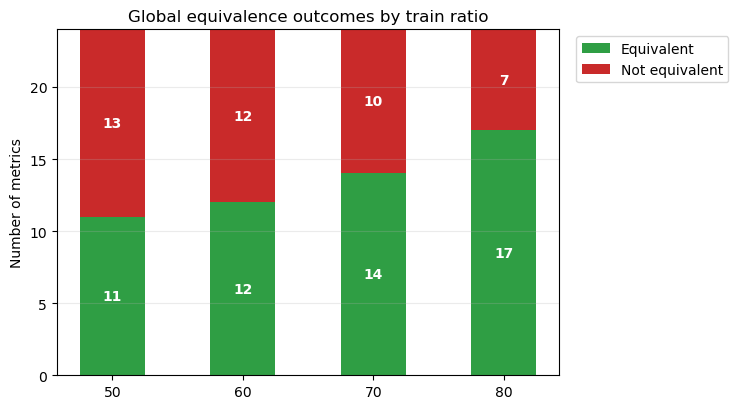

## Core metrics: equivalence matrix

TrainRatio,50,60,70,80
Metric,,,,
Connectance,Not equivalent,Not equivalent,Not equivalent,Equivalent
MeanTrophicLevel,Not equivalent,Not equivalent,Not equivalent,Not equivalent
MeanDegree,Not equivalent,Not equivalent,Not equivalent,Not equivalent
MeanGenerality,Not equivalent,Not equivalent,Not equivalent,Not equivalent
MeanVulnerability,Not equivalent,Not equivalent,Not equivalent,Not equivalent
PropBasal,Equivalent,Equivalent,Equivalent,Equivalent
PropIntermediate,Equivalent,Equivalent,Equivalent,Equivalent
PropTop,Equivalent,Equivalent,Equivalent,Equivalent


## Core metrics comparison

,TrainRatio,Metric,EcosystemType,NumFoodWebs,NumRows,EstimatedDelta,SE,90% CI,Margin,ICC,Conclusion
0,50,Connectance,all,290,5800,-0.0245,0.0010,"[-0.0261, -0.0228]","[-0.0100, 0.0100]",0.703,Not equivalent: pseudo lower
1,50,MeanTrophicLevel,all,290,5654,1.1745,0.1324,"[0.9560, 1.3930]","[-0.1000, 0.1000]",0.153,Not equivalent: pseudo higher
2,50,MeanDegree,all,290,5800,-2.9660,0.2037,"[-3.3022, -2.6298]","[-0.5000, 0.5000]",0.834,Not equivalent: pseudo lower
3,50,MeanGenerality,all,290,5800,-2.1424,0.1588,"[-2.4044, -1.8804]","[-0.5000, 0.5000]",0.894,Not equivalent: pseudo lower
4,50,MeanVulnerability,all,290,5800,-1.6295,0.1120,"[-1.8142, -1.4447]","[-0.5000, 0.5000]",0.849,Not equivalent: pseudo lower
5,50,PropBasal,all,290,5800,-0.0253,0.0020,"[-0.0286, -0.0221]","[-0.0500, 0.0500]",0.283,Equivalent / close enough
6,50,PropIntermediate,all,290,5800,0.0146,0.0034,"[0.0089, 0.0202]","[-0.0500, 0.0500]",0.403,Equivalent / close enough
7,50,PropTop,all,290,5800,-0.0107,0.0023,"[-0.0145, -0.0068]","[-0.0500, 0.0500]",0.333,Equivalent / close enough
24,60,Connectance,all,290,5800,-0.0181,0.0007,"[-0.0193, -0.0170]","[-0.0100, 0.0100]",0.631,Not equivalent: pseudo lower
25,60,MeanTrophicLevel,all,290,5745,0.6987,0.0831,"[0.5615, 0.8359]","[-0.1000, 0.1000]",0.084,Not equivalent: pseudo higher


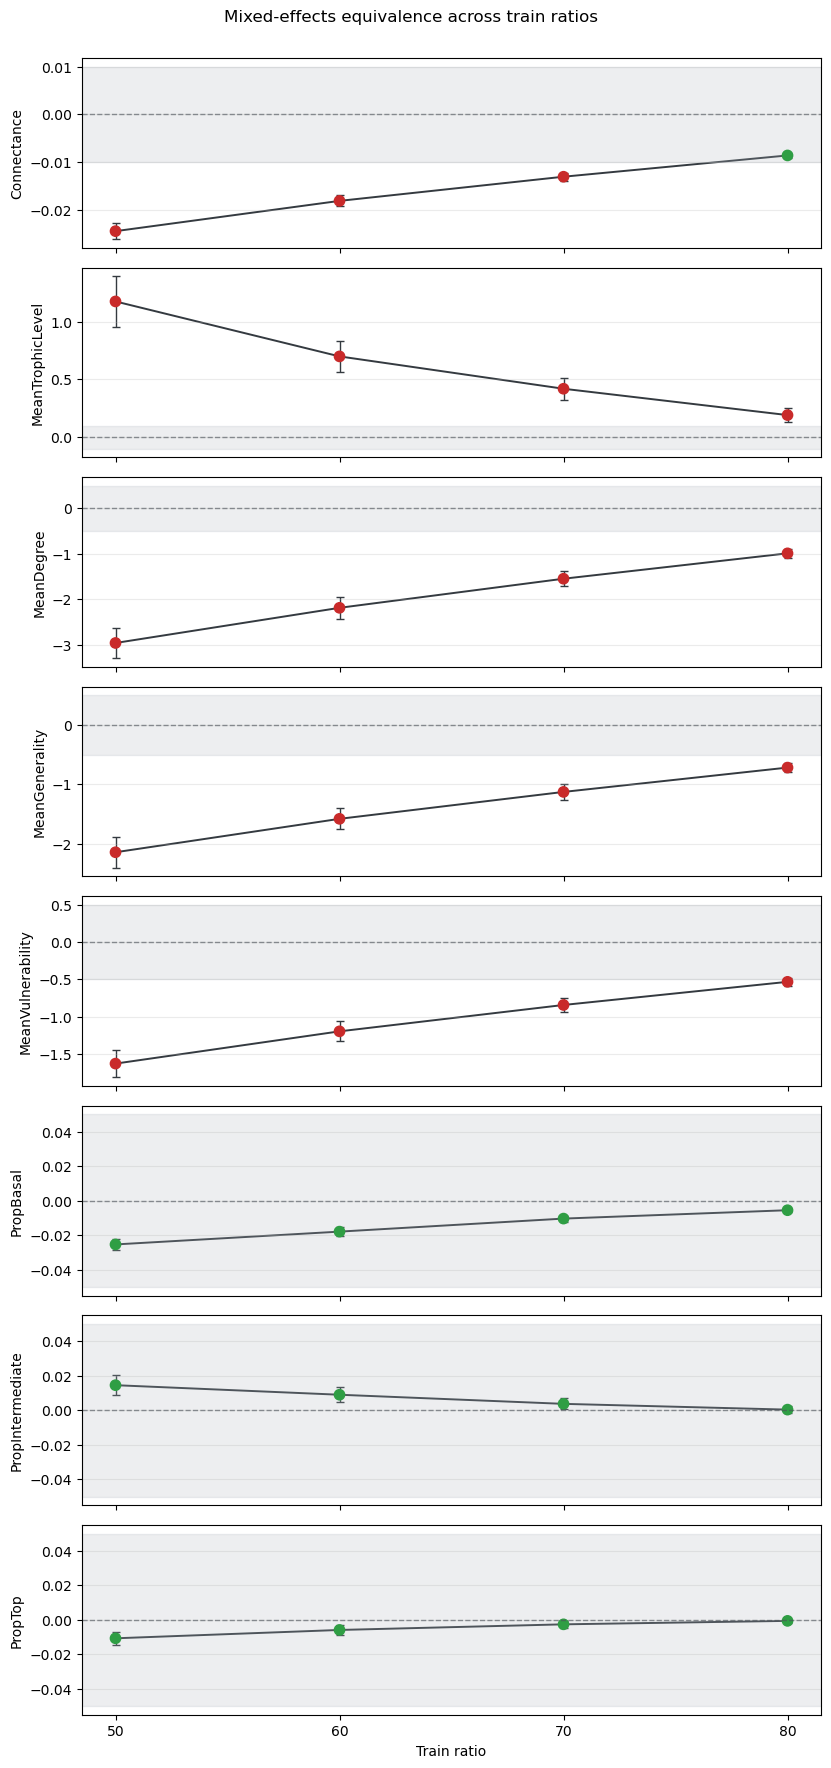

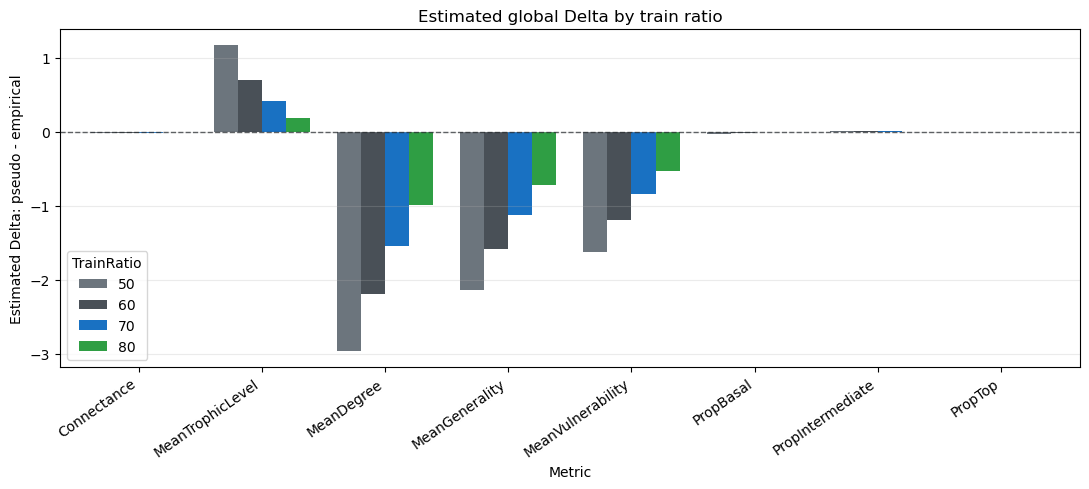

## All global metrics: equivalence matrix

TrainRatio,50,60,70,80
Metric,,,,
Connectance,Not equivalent,Not equivalent,Not equivalent,Equivalent
DegreeCV,Equivalent,Equivalent,Equivalent,Equivalent
DegreeGini,Equivalent,Equivalent,Equivalent,Equivalent
DegreeStd,Not equivalent,Not equivalent,Not equivalent,Not equivalent
GeneralityCV,Equivalent,Equivalent,Equivalent,Equivalent
GeneralityGini,Equivalent,Equivalent,Equivalent,Equivalent
GeneralityStd,Not equivalent,Not equivalent,Not equivalent,Not equivalent
MeanDegree,Not equivalent,Not equivalent,Not equivalent,Not equivalent
MeanDietOverlap,Not equivalent,Equivalent,Equivalent,Equivalent


## All global metrics across train ratios

,TrainRatio,Metric,EcosystemType,NumFoodWebs,NumRows,EstimatedDelta,SE,90% CI,Margin,ICC,Conclusion
0,50,Connectance,all,290,5800,-0.0245,0.0010,"[-0.0261, -0.0228]","[-0.0100, 0.0100]",0.703,Not equivalent: pseudo lower
1,50,MeanTrophicLevel,all,290,5654,1.1745,0.1324,"[0.9560, 1.3930]","[-0.1000, 0.1000]",0.153,Not equivalent: pseudo higher
2,50,MeanDegree,all,290,5800,-2.9660,0.2037,"[-3.3022, -2.6298]","[-0.5000, 0.5000]",0.834,Not equivalent: pseudo lower
3,50,MeanGenerality,all,290,5800,-2.1424,0.1588,"[-2.4044, -1.8804]","[-0.5000, 0.5000]",0.894,Not equivalent: pseudo lower
4,50,MeanVulnerability,all,290,5800,-1.6295,0.1120,"[-1.8142, -1.4447]","[-0.5000, 0.5000]",0.849,Not equivalent: pseudo lower
5,50,PropBasal,all,290,5800,-0.0253,0.0020,"[-0.0286, -0.0221]","[-0.0500, 0.0500]",0.283,Equivalent / close enough
6,50,PropIntermediate,all,290,5800,0.0146,0.0034,"[0.0089, 0.0202]","[-0.0500, 0.0500]",0.403,Equivalent / close enough
7,50,PropTop,all,290,5800,-0.0107,0.0023,"[-0.0145, -0.0068]","[-0.0500, 0.0500]",0.333,Equivalent / close enough
8,50,DegreeStd,all,290,5800,-1.8799,0.1548,"[-2.1354, -1.6245]","[-0.5000, 0.5000]",0.895,Not equivalent: pseudo lower
9,50,DegreeCV,all,290,5800,0.0326,0.0045,"[0.0252, 0.0400]","[-0.1000, 0.1000]",0.683,Equivalent / close enough


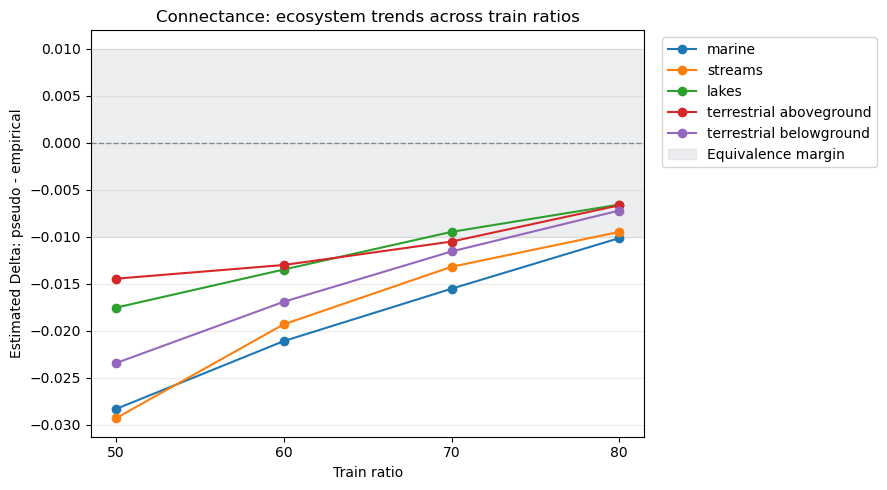

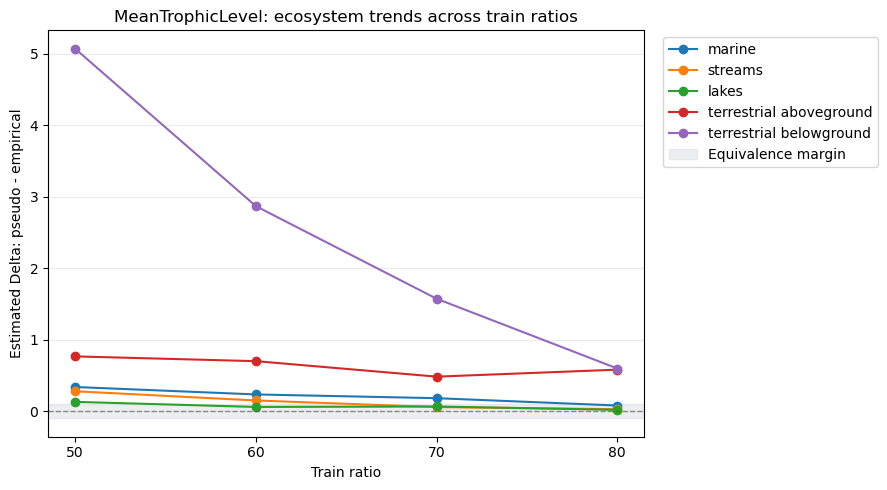

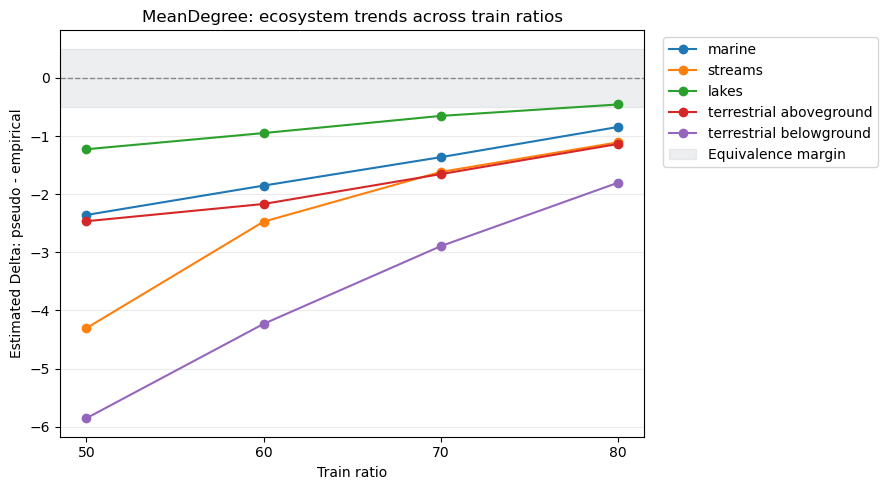

## Connectance by ecosystem across train ratios

,TrainRatio,Metric,EcosystemType,NumFoodWebs,NumRows,EstimatedDelta,SE,90% CI,Margin,ICC,Conclusion
0,50,Connectance,marine,134,2680,-0.0283,0.0014,"[-0.0307, -0.0260]","[-0.0100, 0.0100]",0.687,Not equivalent: pseudo lower
1,50,Connectance,streams,28,560,-0.0293,0.0031,"[-0.0344, -0.0241]","[-0.0100, 0.0100]",0.687,Not equivalent: pseudo lower
2,50,Connectance,lakes,55,1100,-0.0175,0.0022,"[-0.0212, -0.0139]","[-0.0100, 0.0100]",0.687,Not equivalent: pseudo lower
3,50,Connectance,terrestrial aboveground,21,420,-0.0145,0.0036,"[-0.0204, -0.0085]","[-0.0100, 0.0100]",0.687,Not equivalent: pseudo lower
4,50,Connectance,terrestrial belowground,52,1040,-0.0234,0.0023,"[-0.0272, -0.0197]","[-0.0100, 0.0100]",0.687,Not equivalent: pseudo lower
120,60,Connectance,marine,134,2680,-0.0211,0.0010,"[-0.0227, -0.0194]","[-0.0100, 0.0100]",0.616,Not equivalent: pseudo lower
121,60,Connectance,streams,28,560,-0.0193,0.0022,"[-0.0229, -0.0157]","[-0.0100, 0.0100]",0.616,Not equivalent: pseudo lower
122,60,Connectance,lakes,55,1100,-0.0135,0.0016,"[-0.0161, -0.0109]","[-0.0100, 0.0100]",0.616,Not equivalent: pseudo lower
123,60,Connectance,terrestrial aboveground,21,420,-0.0130,0.0025,"[-0.0172, -0.0088]","[-0.0100, 0.0100]",0.616,Not equivalent: pseudo lower
124,60,Connectance,terrestrial belowground,52,1040,-0.0169,0.0016,"[-0.0196, -0.0143]","[-0.0100, 0.0100]",0.616,Not equivalent: pseudo lower


In [15]:

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# ---------- Paths ----------

REPO_ROOT = Path("/Users/acw792/Developer/qmul-phd-framework")

COMPARISON_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita"
    / "statistical_tests/jorge/train_ratio_comparison"
)

GLOBAL_COMPARISON_CSV = COMPARISON_DIR / "mixed_effects_delta_train_ratios_50_60_70_80_global.csv"
ECOSYSTEM_COMPARISON_CSV = COMPARISON_DIR / "mixed_effects_delta_train_ratios_50_60_70_80_by_ecosystem.csv"
SUMMARY_COMPARISON_CSV = COMPARISON_DIR / "mixed_effects_delta_train_ratios_50_60_70_80_summary.csv"

global_all = pd.read_csv(GLOBAL_COMPARISON_CSV)
ecosystem_all = pd.read_csv(ECOSYSTEM_COMPARISON_CSV)
summary_all = pd.read_csv(SUMMARY_COMPARISON_CSV)

global_all["TrainRatio"] = global_all["TrainRatio"].astype(int)
ecosystem_all["TrainRatio"] = ecosystem_all["TrainRatio"].astype(int)
summary_all["TrainRatio"] = summary_all["TrainRatio"].astype(int)

CORE_METRICS = [
    "Connectance",
    "MeanTrophicLevel",
    "MeanDegree",
    "MeanGenerality",
    "MeanVulnerability",
    "PropBasal",
    "PropIntermediate",
    "PropTop",
]

TRAIN_RATIOS = [50, 60, 70, 80]

# ---------- Helpers ----------

def conclusion(row):
    if int(row["Equivalent90"]) == 1:
        return "Equivalent / close enough"
    if row["Direction"] == "not_equivalent_pseudo_lower":
        return "Not equivalent: pseudo lower"
    if row["Direction"] == "not_equivalent_pseudo_higher":
        return "Not equivalent: pseudo higher"
    return "Not equivalent: CI crosses margin"


def add_display_columns(df):
    out = df.copy()
    out["TrainRatio"] = out["TrainRatio"].astype(int)
    out["90% CI"] = out.apply(
        lambda r: f"[{r['CI90Lower']:.4f}, {r['CI90Upper']:.4f}]",
        axis=1,
    )
    out["Margin"] = out.apply(
        lambda r: f"[{r['LowerMargin']:.4f}, {r['UpperMargin']:.4f}]",
        axis=1,
    )
    out["Conclusion"] = out.apply(conclusion, axis=1)
    return out


def style_comparison_table(df):
    display_df = add_display_columns(df)

    cols = [
        "TrainRatio",
        "Metric",
        "EcosystemType",
        "NumFoodWebs",
        "NumRows",
        "EstimatedDelta",
        "SE",
        "90% CI",
        "Margin",
        "ICC",
        "Conclusion",
    ]

    existing_cols = [c for c in cols if c in display_df.columns]

    styled = (
        display_df[existing_cols]
        .style
        .format({
            "EstimatedDelta": "{:.4f}",
            "SE": "{:.4f}",
            "ICC": "{:.3f}",
        })
        .background_gradient(subset=["EstimatedDelta"], cmap="coolwarm")
    )

    def color_conclusion(value):
        if value == "Equivalent / close enough":
            return "background-color: #d7f5dd; color: #14532d; font-weight: 600"
        return "background-color: #f8d7da; color: #7f1d1d; font-weight: 600"

    if hasattr(styled, "map"):
        styled = styled.map(color_conclusion, subset=["Conclusion"])
    else:
        styled = styled.applymap(color_conclusion, subset=["Conclusion"])

    return styled


def make_equivalence_matrix(df, metrics=None):
    plot_df = df.copy()

    if metrics is not None:
        plot_df = plot_df[plot_df["Metric"].isin(metrics)].copy()

    matrix = (
        plot_df
        .assign(Equivalent90=lambda x: x["Equivalent90"].astype(int))
        .pivot(index="Metric", columns="TrainRatio", values="Equivalent90")
        .reindex(metrics if metrics is not None else sorted(plot_df["Metric"].unique()))
        .reindex(columns=TRAIN_RATIOS)
    )

    return matrix


def style_equivalence_matrix(matrix):
    labels = matrix.replace({1: "Equivalent", 0: "Not equivalent"})

    styled = labels.style

    def color_cell(value):
        if value == "Equivalent":
            return "background-color: #d7f5dd; color: #14532d; font-weight: 600"
        return "background-color: #f8d7da; color: #7f1d1d; font-weight: 600"

    if hasattr(styled, "map"):
        styled = styled.map(color_cell)
    else:
        styled = styled.applymap(color_cell)

    return styled


def plot_equivalence_counts(summary_df):
    plot_df = summary_df.copy()
    plot_df["TrainRatio"] = plot_df["TrainRatio"].astype(int)

    fig, ax = plt.subplots(figsize=(7.5, 4.2))

    ax.bar(
        plot_df["TrainRatio"],
        plot_df["Equivalent90Count"],
        color="#2f9e44",
        label="Equivalent",
        width=5,
    )
    ax.bar(
        plot_df["TrainRatio"],
        plot_df["NonEquivalent90Count"],
        bottom=plot_df["Equivalent90Count"],
        color="#c92a2a",
        label="Not equivalent",
        width=5,
    )

    for _, row in plot_df.iterrows():
        ax.text(
            row["TrainRatio"],
            row["Equivalent90Count"] / 2,
            int(row["Equivalent90Count"]),
            ha="center",
            va="center",
            color="white",
            fontweight="bold",
        )
        ax.text(
            row["TrainRatio"],
            row["Equivalent90Count"] + row["NonEquivalent90Count"] / 2,
            int(row["NonEquivalent90Count"]),
            ha="center",
            va="center",
            color="white",
            fontweight="bold",
        )

    ax.set_xticks(TRAIN_RATIOS)
    ax.set_ylim(0, 24)
    ax.set_ylabel("Number of metrics")
    ax.set_title("Global equivalence outcomes by train ratio")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_metric_trends(df, metrics=CORE_METRICS):
    plot_df = df[df["Metric"].isin(metrics)].copy()
    plot_df["TrainRatio"] = plot_df["TrainRatio"].astype(int)
    plot_df["Equivalent90"] = plot_df["Equivalent90"].astype(int)
    plot_df["Metric"] = pd.Categorical(plot_df["Metric"], categories=metrics, ordered=True)
    plot_df = plot_df.sort_values(["Metric", "TrainRatio"])

    fig, axes = plt.subplots(
        len(metrics),
        1,
        figsize=(8.5, max(10, 2.2 * len(metrics))),
        sharex=True,
    )

    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        metric_df = plot_df[plot_df["Metric"] == metric].copy()
        colors = metric_df["Equivalent90"].map({1: "#2f9e44", 0: "#c92a2a"})

        ax.plot(
            metric_df["TrainRatio"],
            metric_df["EstimatedDelta"],
            color="#343a40",
            linewidth=1.4,
            zorder=1,
        )

        ax.errorbar(
            metric_df["TrainRatio"],
            metric_df["EstimatedDelta"],
            yerr=[
                metric_df["EstimatedDelta"] - metric_df["CI90Lower"],
                metric_df["CI90Upper"] - metric_df["EstimatedDelta"],
            ],
            fmt="none",
            ecolor="#343a40",
            elinewidth=1,
            capsize=3,
            zorder=1,
        )

        ax.scatter(
            metric_df["TrainRatio"],
            metric_df["EstimatedDelta"],
            c=colors,
            s=55,
            zorder=2,
        )

        lower = metric_df["LowerMargin"].iloc[0]
        upper = metric_df["UpperMargin"].iloc[0]

        ax.axhspan(lower, upper, color="#adb5bd", alpha=0.22)
        ax.axhline(0, color="#495057", linestyle="--", linewidth=1, alpha=0.6)

        ax.set_ylabel(metric)
        ax.grid(axis="y", alpha=0.25)

    axes[-1].set_xticks(TRAIN_RATIOS)
    axes[-1].set_xlabel("Train ratio")

    fig.suptitle("Mixed-effects equivalence across train ratios", y=1.002)
    plt.tight_layout()
    plt.show()


def plot_metric_grouped_bars(df, metrics=CORE_METRICS):
    plot_df = df[df["Metric"].isin(metrics)].copy()
    plot_df["TrainRatio"] = plot_df["TrainRatio"].astype(int)

    pivot = plot_df.pivot(index="Metric", columns="TrainRatio", values="EstimatedDelta")
    pivot = pivot.loc[metrics, TRAIN_RATIOS]

    ax = pivot.plot(
        kind="bar",
        figsize=(11, 5),
        color=["#6c757d", "#495057", "#1971c2", "#2f9e44"],
        width=0.78,
    )

    ax.axhline(0, color="#212529", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_ylabel("Estimated Delta: pseudo - empirical")
    ax.set_title("Estimated global Delta by train ratio")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(title="TrainRatio")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()


def plot_ecosystem_metric_trends(df, metric):
    plot_df = df[df["Metric"] == metric].copy()
    plot_df["TrainRatio"] = plot_df["TrainRatio"].astype(int)

    ecosystems = [
        "marine",
        "streams",
        "lakes",
        "terrestrial aboveground",
        "terrestrial belowground",
    ]

    plot_df["EcosystemType"] = pd.Categorical(
        plot_df["EcosystemType"],
        categories=ecosystems,
        ordered=True,
    )
    plot_df = plot_df.sort_values(["EcosystemType", "TrainRatio"])

    fig, ax = plt.subplots(figsize=(9, 5))

    for ecosystem in ecosystems:
        eco_df = plot_df[plot_df["EcosystemType"] == ecosystem]
        if eco_df.empty:
            continue

        ax.plot(
            eco_df["TrainRatio"],
            eco_df["EstimatedDelta"],
            marker="o",
            linewidth=1.5,
            label=ecosystem,
        )

    lower = plot_df["LowerMargin"].iloc[0]
    upper = plot_df["UpperMargin"].iloc[0]

    ax.axhspan(lower, upper, color="#adb5bd", alpha=0.22, label="Equivalence margin")
    ax.axhline(0, color="#495057", linestyle="--", linewidth=1, alpha=0.6)

    ax.set_xticks(TRAIN_RATIOS)
    ax.set_xlabel("Train ratio")
    ax.set_ylabel("Estimated Delta: pseudo - empirical")
    ax.set_title(f"{metric}: ecosystem trends across train ratios")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    plt.show()


display(Markdown("## Summary: equivalence counts across train ratios"))
display(summary_all)



plot_equivalence_counts(summary_all)



display(Markdown("## Core metrics: equivalence matrix"))
core_matrix = make_equivalence_matrix(global_all, CORE_METRICS)
display(style_equivalence_matrix(core_matrix))



display(Markdown("## Core metrics comparison"))
core_comparison = global_all[global_all["Metric"].isin(CORE_METRICS)].copy()
display(style_comparison_table(core_comparison))



plot_metric_trends(global_all, CORE_METRICS)



plot_metric_grouped_bars(global_all, CORE_METRICS)



display(Markdown("## All global metrics: equivalence matrix"))
all_matrix = make_equivalence_matrix(global_all)
display(style_equivalence_matrix(all_matrix))



display(Markdown("## All global metrics across train ratios"))
display(style_comparison_table(global_all))



plot_ecosystem_metric_trends(ecosystem_all, "Connectance")
plot_ecosystem_metric_trends(ecosystem_all, "MeanTrophicLevel")
plot_ecosystem_metric_trends(ecosystem_all, "MeanDegree")



display(Markdown("## Connectance by ecosystem across train ratios"))
connectance_ecosystem = ecosystem_all[ecosystem_all["Metric"] == "Connectance"].copy()
display(style_comparison_table(connectance_ecosystem))


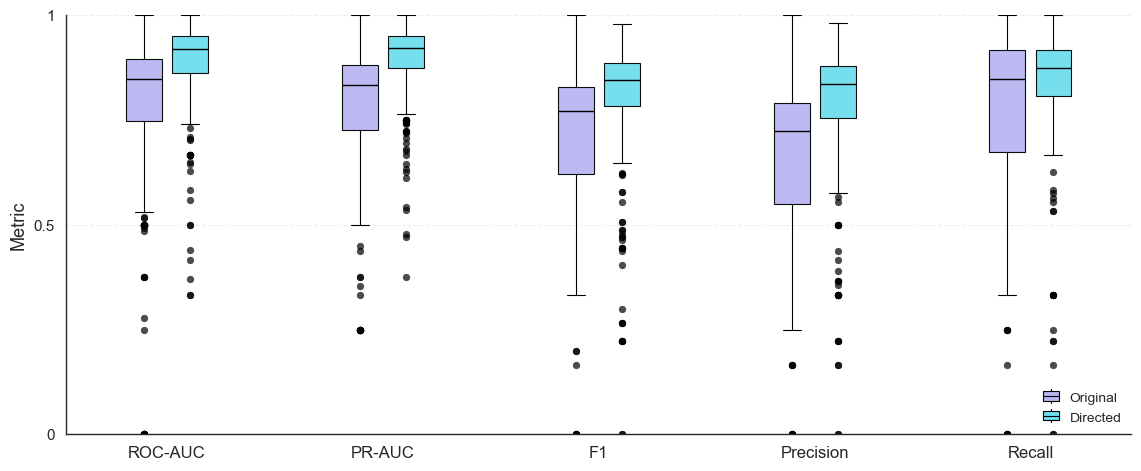

In [19]:
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase


# =========================
# Style
# =========================
sns.set_theme(context="paper", style="white")


# =========================
# Config
# =========================
REPO_ROOT = Path("/Users/acw792/Developer/qmul-phd-framework")

RESULTS_DIR_ORIGINAL = REPO_ROOT / "src/python/data/result/prediction_scores_logs"
RESULTS_DIR_DIRECTED = REPO_ROOT / "src/python/seal_directed/data/result/prediction_scores_logs"

FOODWEB_CSV = REPO_ROOT / "data/processed/foodweb_metrics_ecosystem.csv"

METRICS = [
    "ROC_AUC",
    "PR_AUC",
    "F1Score",
    "Precision",
    "Recall",
]

K_TARGET = None
K_COL = "K"
NODES_THRESHOLD = 0

# Dejalo como None para no excluir food webs pequenos con TrainRatio distinto de 90.
TRAIN_RATIO_MIN = None
TRAIN_RATIO_COL = "TrainRatio"

GLOB_PATTERN_ORIGINAL = "*_results_SEAL.csv"
GLOB_PATTERN_DIRECTED = "*_results_SEAL_directed.csv"


# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip().lower()
    name, _ = os.path.splitext(name)
    name = name.replace("_", " ")
    name = re.sub(r"\btax\s+mass\b", "", name)
    name = re.sub(r"\btax\b|\bmass\b", "", name)
    name = re.sub(r"[^a-z0-9]+", " ", name)
    return " ".join(name.split())


def parse_foodweb_from_name(fname: str) -> str:
    base = Path(fname).name

    for suffix in ["_results_SEAL_directed.csv", "_results_SEAL.csv"]:
        if base.endswith(suffix):
            base = base[:-len(suffix)]
            break

    return base.replace("_", " ")


def coerce_numeric(df: pd.DataFrame, cols) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def load_one_csv(csv_path: Path, version: str):
    df = pd.read_csv(csv_path)

    present_metrics = [m for m in METRICS if m in df.columns]
    if not present_metrics:
        return None

    df = coerce_numeric(df, METRICS + [K_COL, TRAIN_RATIO_COL])

    if TRAIN_RATIO_MIN is not None:
        if TRAIN_RATIO_COL not in df.columns:
            return None

        df = df[df[TRAIN_RATIO_COL] >= TRAIN_RATIO_MIN].copy()

        if df.empty:
            return None

    if K_TARGET is not None and K_COL in df.columns:
        df = df[df[K_COL] == K_TARGET].copy()

        if df.empty:
            return None

    out = {
        "Foodweb": parse_foodweb_from_name(csv_path.name),
        "Version": version,
        "n_rows": int(len(df)),
        "file": csv_path.name,
    }

    valid_any = False

    for metric in METRICS:
        if metric in df.columns:
            vals = df[metric].dropna().values
            out[f"{metric}_mean"] = float(np.mean(vals)) if vals.size else np.nan

            if vals.size:
                valid_any = True
        else:
            out[f"{metric}_mean"] = np.nan

    if not valid_any:
        return None

    return out


def load_folder(folder: Path, pattern: str, version: str):
    csv_files = sorted(folder.glob(pattern))

    if not csv_files:
        raise FileNotFoundError(
            f"No files found in {folder.resolve()} matching: {pattern}"
        )

    rows = []

    for p in csv_files:
        rec = load_one_csv(p, version=version)

        if rec is not None:
            rows.append(rec)

    return rows


# =========================
# Load CSVs
# =========================
rows = []
rows += load_folder(RESULTS_DIR_ORIGINAL, GLOB_PATTERN_ORIGINAL, version="original")
rows += load_folder(RESULTS_DIR_DIRECTED, GLOB_PATTERN_DIRECTED, version="directed")

df_all = pd.DataFrame(rows)

if df_all.empty:
    raise RuntimeError("No valid rows after loading folders. Check paths or CSV columns.")


# =========================
# Apply NODE_THRESHOLD logic
# =========================
meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

if fw_col is None or nodes_col is None:
    raise ValueError("Could not find 'Foodweb' and 'Nodes' columns in FOODWEB_CSV.")

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df_all["FW_KEY"] = df_all["Foodweb"].apply(normalize_fw_label)

meta_filtered = meta.loc[
    meta[nodes_col] >= NODES_THRESHOLD,
    ["FW_KEY", nodes_col],
].copy()

allowed_fw_keys = set(meta_filtered["FW_KEY"].unique())
df_all = df_all[df_all["FW_KEY"].isin(allowed_fw_keys)].copy()

if df_all.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes >= {NODES_THRESHOLD}.")


# =========================
# One row per Foodweb per Version
# =========================
mean_cols = [f"{metric}_mean" for metric in METRICS]

df_all = (
    df_all
    .groupby(["Foodweb", "Version"], as_index=False)[mean_cols]
    .mean()
)


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height

        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


# =========================
# Plot: single-panel boxplots
# =========================
order = ["original", "directed"]

label_map = {
    "original": "Original",
    "directed": "Directed",
}

palette = {
    "original": "#bab6f2",
    "directed": "#6edeed",
}

plot_metrics = [
    ("ROC_AUC_mean", "ROC-AUC"),
    ("PR_AUC_mean", "PR-AUC"),
    ("F1Score_mean", "F1"),
    ("Precision_mean", "Precision"),
    ("Recall_mean", "Recall"),
]

fig, ax = plt.subplots(figsize=(11.5, 4.8))

group_gap = 1.5
group_centers = 1.0 + np.arange(len(plot_metrics)) * group_gap

offsets = np.array([-0.16, 0.16])
box_width = 0.25

for j, version in enumerate(order):
    data_for_version = []
    positions_for_version = []

    for i, (metric_col, _) in enumerate(plot_metrics):
        vals = (
            df_all.loc[df_all["Version"] == version, metric_col]
            .dropna()
            .values
        )

        if len(vals) == 0:
            continue

        data_for_version.append(vals)
        positions_for_version.append(group_centers[i] + offsets[j])

    ax.boxplot(
        data_for_version,
        positions=positions_for_version,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=True,
        boxprops=dict(
            facecolor=palette[version],
            edgecolor="black",
            linewidth=0.8,
            alpha=0.95,
        ),
        medianprops=dict(color="black", linewidth=1.0),
        whiskerprops=dict(color="black", linewidth=0.8),
        capprops=dict(color="black", linewidth=0.8),
        flierprops=dict(
            marker="o",
            markersize=5,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0.2,
            alpha=0.7,
        ),
    )

legend_handles = [
    {
        "facecolor": palette[v],
        "edgecolor": "black",
        "linewidth": 0.8,
    }
    for v in order
]

ax.set_xlim(group_centers[0] - 0.7, group_centers[-1] + 0.7)
ax.set_ylim(0, 1.0)

ax.set_xticks(group_centers)
ax.set_xticklabels(
    [label for _, label in plot_metrics],
    rotation=0,
    ha="center",
    fontsize=12,
)

ax.set_ylabel("Metric", fontsize=13)
ax.set_xlabel("")

ax.tick_params(axis="y", labelsize=11)
ax.set_yticks([0, 0.5, 1.0])
ax.set_yticklabels(["0", "0.5", "1"])
ax.grid(True, axis="y", linestyle="--", alpha=0.35)

ax.legend(
    handles=legend_handles,
    labels=[label_map[v] for v in order],
    handler_map={dict: HandlerMiniBoxplot()},
    loc="lower right",
    frameon=False,
    fontsize=10,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    borderpad=0.2,
    labelspacing=0.45,
)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

[INFO] Foodwebs with Nodes >= 0: 290
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 290
[INFO] Applied TrainRatio filter: TrainRatio == 90
[INFO] Rows after filtering, without averaging runs: 11460
Version
dir_neg     5800
original    5660
dtype: int64

=== Metric summary: mean and variance across food webs ===


,Version,Metric,Mean,Variance
0,Original,ROC-AUC,0.8469,0.053336
1,Original,PR-AUC,0.5888,0.059152
2,Original,F1,0.6667,0.099205
3,Original,MCC,0.5385,0.132832
4,Original,Precision,0.7050,0.108205
5,Original,Recall,0.6667,0.110103
6,Original,TSS,0.5000,0.124101
7,Directed-Negative,ROC-AUC,0.8889,0.015691
8,Directed-Negative,PR-AUC,0.6328,0.059231
9,Directed-Negative,F1,0.7330,0.057746


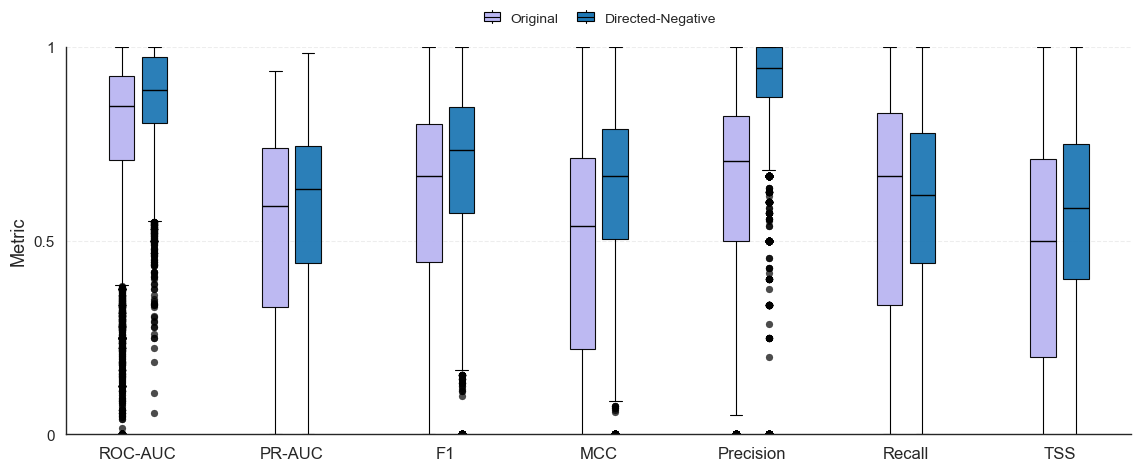

In [24]:
import os
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase


# =========================
# Style (match old snippet)
# =========================
sns.set_theme(context="paper", style="white")


# =========================
# Config
# =========================
RESULTS_DIR_ORIGINAL = Path("../../../src/matlab/data/result_wlnm_original_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs")
RESULTS_DIR_DIR_NEG  = Path("../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs")

FOODWEB_CSV = Path("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")

METRICS = ["ROC_AUC", "PR_AUC", "F1Score", "TestMCC", "Precision", "Recall", "TestTSS"]
K_TARGET = None
K_COL = "K"
NODES_THRESHOLD = 0
TRAIN_RATIO_TARGET = 90
TRAIN_RATIO_COL = "TrainRatio"

GLOB_PATTERN_ORIGINAL = "*_tax_mass_results_random_wlnm_original.csv"
GLOB_PATTERN_DIRECTED = "*_tax_mass_results_random_wlnm_directed.csv"
GLOB_PATTERN_DIR_NEG  = "*_tax_mass_results_random_wlnm_dir_neg.csv"


# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in [
        "_results_", "_result_", "_results",
        "_random", "_tax_mass", "_tax", "_mass"
    ]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def parse_foodweb_from_name(fname: str) -> str:
    base = Path(fname).name
    if "_results_" in base:
        return base.split("_results_")[0]
    return Path(fname).stem


def coerce_numeric(df: pd.DataFrame, cols) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def load_one_csv(csv_path: Path, version: str):
    df = pd.read_csv(csv_path)

    present_metrics = [m for m in METRICS if m in df.columns]
    if not present_metrics:
        print(f"[SKIP] Missing all metrics {METRICS}: {csv_path.name}")
        return None

    df = coerce_numeric(df, METRICS + [K_COL, TRAIN_RATIO_COL])

    # Filter only TrainRatio = 90
    if TRAIN_RATIO_TARGET is not None:
        if TRAIN_RATIO_COL not in df.columns:
            print(f"[SKIP] Missing {TRAIN_RATIO_COL}: {csv_path.name}")
            return None

        df = df[df[TRAIN_RATIO_COL] == TRAIN_RATIO_TARGET].copy()

        if df.empty:
            return None

    if K_TARGET is not None and K_COL in df.columns:
        df = df[df[K_COL] == K_TARGET].copy()
        if df.empty:
            return None

    records = []
    df = df.reset_index(drop=True)

    for run_idx, row in df.iterrows():
        out = {
            "Foodweb": parse_foodweb_from_name(csv_path.name),
            "Version": version,
            "Run": run_idx + 1,
            "n_rows": int(len(df)),
            "file": csv_path.name,
            "folder": str(csv_path.parent),
        }

        valid_any = False

        for metric in METRICS:
            if metric in df.columns:
                val = row[metric]
                out[f"{metric}_mean"] = float(val) if pd.notna(val) else np.nan

                if pd.notna(val):
                    valid_any = True
            else:
                out[f"{metric}_mean"] = np.nan

        if valid_any:
            records.append(out)

    if not records:
        return None

    return records

def load_folder(folder: Path, pattern: str, version: str):
    csv_files = sorted(folder.glob(pattern))
    if not csv_files:
        raise FileNotFoundError(
            f"No files found in {folder.resolve()} matching: {pattern}"
        )

    rows = []
    for p in csv_files:
        recs = load_one_csv(p, version=version)
        if recs is not None:
            rows.extend(recs)

    return rows

# =========================
# Load all CSVs
# =========================
rows = []
rows += load_folder(RESULTS_DIR_ORIGINAL, GLOB_PATTERN_ORIGINAL, version="original")
rows += load_folder(RESULTS_DIR_DIR_NEG,  GLOB_PATTERN_DIR_NEG,  version="dir_neg")

df_all = pd.DataFrame(rows)

if df_all.empty:
    raise RuntimeError("No valid rows after loading folders. Check patterns or CSV columns.")


# =========================
# Apply NODE_THRESHOLD logic
# =========================
meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

if fw_col is None or nodes_col is None:
    raise ValueError("Could not find 'Foodweb' and 'Nodes' columns in FOODWEB_CSV.")

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df_all["FW_KEY"] = df_all["Foodweb"].apply(normalize_fw_label)

meta_filtered = meta.loc[meta[nodes_col] >= NODES_THRESHOLD, ["FW_KEY", nodes_col]].copy()
allowed_fw_keys = set(meta_filtered["FW_KEY"].unique())

print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in results before filter: {df_all['FW_KEY'].nunique()}")

df_all = df_all[df_all["FW_KEY"].isin(allowed_fw_keys)].copy()

print(f"[INFO] Foodwebs in results after filter: {df_all['Foodweb'].nunique()}")
print(f"[INFO] Applied TrainRatio filter: TrainRatio == {TRAIN_RATIO_TARGET}")

if df_all.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes > {NODES_THRESHOLD}.")

# =========================
# Keep one row per Foodweb × Version × Run
# This preserves the 20 repeated runs per food web.
# Expected observations per version: 290 × 20 = 5800
# =========================
print(f"[INFO] Rows after filtering, without averaging runs: {len(df_all)}")
print(df_all.groupby("Version").size())

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        # Slight downward shift for visual alignment with text
        y_shift = -0.06 * height

        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        # Smaller box so whiskers sit clearly outside
        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        # Whisker ends must stay outside the box
        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


# =========================
# Plot: single-panel boxplots comparing versions across metrics
# =========================
order = ["original", "dir_neg"]
label_map = {
    "original": "Original",
    "dir_neg": "Directed-Negative",
}

palette = {
    "original": "#bab6f2",
    "directed": "#6edeed",
    "dir_neg": "#1f78b4",
}

plot_metrics = [
    ("ROC_AUC_mean", "ROC-AUC"),
    ("PR_AUC_mean", "PR-AUC"),
    ("F1Score_mean", "F1"),
    ("TestMCC_mean", "MCC"),
    ("Precision_mean", "Precision"),
    ("Recall_mean", "Recall"),
    ("TestTSS_mean", "TSS"),
]

# =========================
# Print metric summary table
# =========================
summary_rows = []

for version in order:
    for metric_col, metric_label in plot_metrics:
        vals = (
            df_all.loc[df_all["Version"] == version, metric_col]
            .dropna()
        )

        summary_rows.append({
            "Version": label_map.get(version, version),
            "Metric": metric_label,
            "Mean": vals.median(),
            "Variance": vals.var(ddof=1),
        })

summary_table = pd.DataFrame(summary_rows)

summary_table["Mean"] = summary_table["Mean"].round(4)
summary_table["Variance"] = summary_table["Variance"].round(6)

print("\n=== Metric summary: mean and variance across food webs ===")
display(summary_table)

# ---

fig, ax = plt.subplots(figsize=(11.5, 4.8))

group_gap = 1.5
group_centers = 1.0 + np.arange(len(plot_metrics)) * group_gap

# Small offsets so versions within the same metric stay close together
offsets = np.array([-0.16, 0.16])
box_width = 0.25

legend_handles = []

for j, version in enumerate(order):
    data_for_version = []
    positions_for_version = []

    for i, (metric_col, _) in enumerate(plot_metrics):
        vals = (
            df_all.loc[df_all["Version"] == version, metric_col]
            .dropna()
            .values
        )

        if len(vals) == 0:
            continue

        data_for_version.append(vals)
        positions_for_version.append(group_centers[i] + offsets[j])

    bp = ax.boxplot(
        data_for_version,
        positions=positions_for_version,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=True,
        boxprops=dict(
            facecolor=palette[version],
            edgecolor="black",
            linewidth=0.8,
            alpha=0.95,
        ),
        medianprops=dict(color="black", linewidth=1.0),
        whiskerprops=dict(color="black", linewidth=0.8),
        capprops=dict(color="black", linewidth=0.8),
        flierprops=dict(
            marker="o",
            markersize=5,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0.2,
            alpha=0.7,
        ),
    )

legend_handles = [
    {
        "facecolor": palette[v],
        "edgecolor": "black",
        "linewidth": 0.8,
    }
    for v in order
]

ax.set_xlim(group_centers[0] - 0.7, group_centers[-1] + 0.7)
ax.set_ylim(0, 1.0)

ax.set_xticks(group_centers)
ax.set_xticklabels([label for _, label in plot_metrics], rotation=0, ha="center", fontsize=12)

ax.set_ylabel("Metric", fontsize=13)
ax.set_xlabel("")

ax.tick_params(axis="y", labelsize=11)
ax.set_yticks([0, 0.5, 1.0])
ax.set_yticklabels(["0", "0.5", "1"])
ax.grid(True, axis="y", linestyle="--", alpha=0.35)

ax.legend(
    handles=legend_handles,
    labels=[label_map[v] for v in order],
    handler_map={dict: HandlerMiniBoxplot()},
    loc="lower center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=len(order),
    frameon=False,
    fontsize=10,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    borderpad=0.2,
    labelspacing=0.45,
    columnspacing=1.2,
)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_36660/3591239872.py:104: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["FOODWEB"] = derive_foodweb_from_filename(path)
/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_36660/3591239872.py:154: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["FW_KEY"] = df["FOODWEB"].apply(normalize_fw_label)


[INFO] Foodwebs with Nodes >= 0: 290
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 290
[INFO] Ecosystems detected: ['lakes', 'marine', 'streams', 'terrestrial aboveground', 'terrestrial belowground']
[INFO] Foodwebs used in final plot: 290


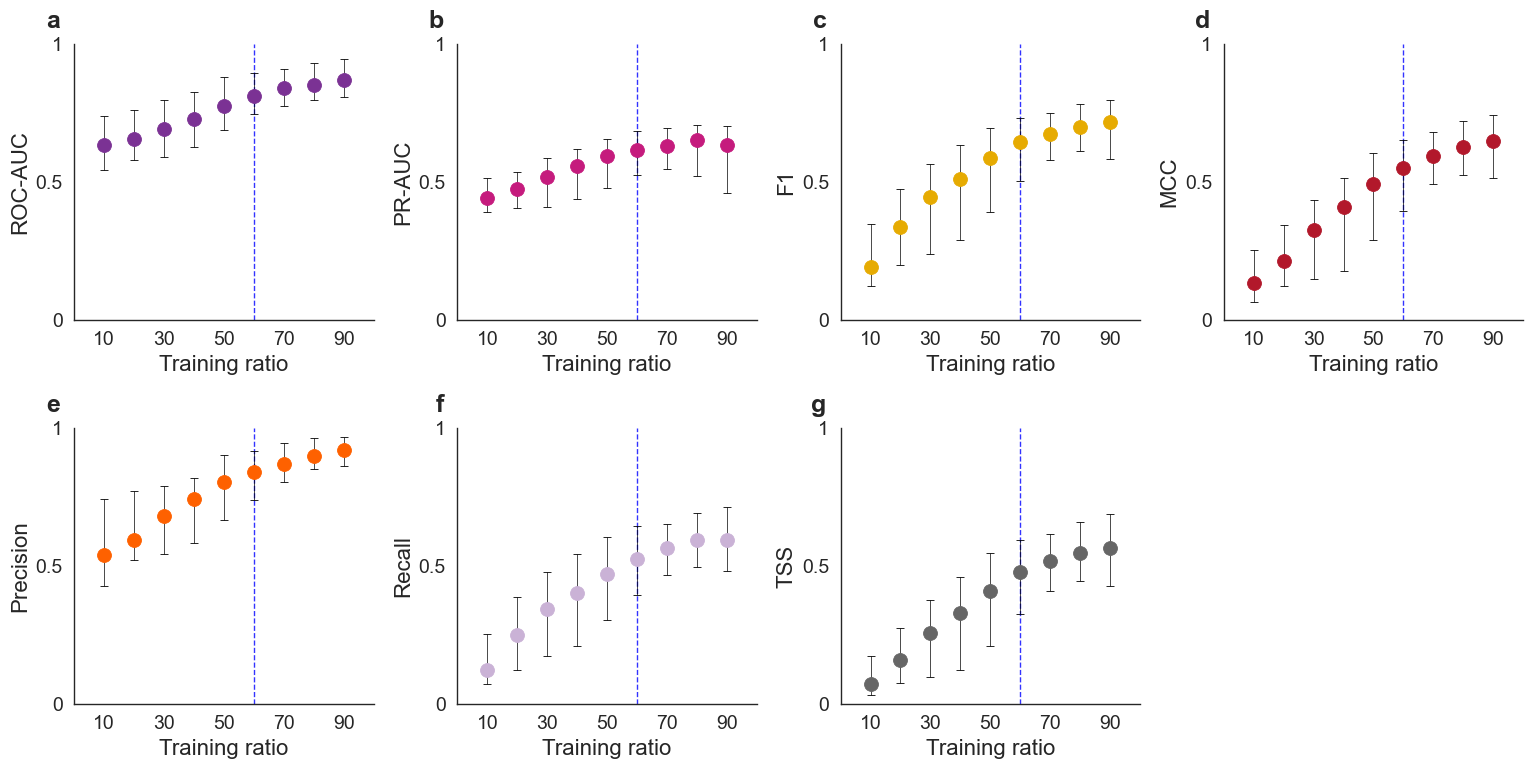

In [25]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper", font_scale=1.35)
sns.set_style("white")

# =========================
# Configuration
# =========================
RESULTS_DIR = "../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs/"
FOODWEB_CSV = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
SINGLE_FILE = None

METRICS = [
    "ROC_AUC",
    "PR_AUC",
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

# Display labels only
METRIC_LABELS = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "F1Score": "F1",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
}

MAX_PLOTS = None
NODES_THRESHOLD = 0
SHOW_GRID = False
Y_MIN = 0.0

# Static y-axis for all panels
INDEPENDENT_Y = False
Y_PADDING = 0.02
Y_MAX_CAP = 1.0

metric_palette = {
    "ROC-AUC": "#7B3294",   # purple
    "PR-AUC": "#C51B7D",    # magenta
    "F1": "#E6AB02",        # mustard
    "MCC": "#B2182B",       # brown
    "Precision": "#FE6100", # orange
    "Recall": "#CAB2D6",    # violet
    "TSS": "#666666",       # dark gray
    "TPR": "#1B9E77",       # teal-green
}

# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in ["_tax_mass_results_random_wlnm_dir_neg", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def derive_foodweb_from_filename(path: str) -> str:
    return normalize_fw_label(os.path.basename(path))


def load_results(results_dir=None, single_file=None, max_plots=None) -> pd.DataFrame:
    paths = []

    if results_dir and os.path.isdir(results_dir):
        paths.extend(sorted(glob.glob(os.path.join(results_dir, "*.csv"))))

    if single_file and os.path.isfile(single_file):
        paths.append(single_file)

    if not paths:
        raise FileNotFoundError("No CSV files found. Check RESULTS_DIR or SINGLE_FILE.")

    if max_plots is not None:
        paths = paths[:max_plots]
        print(f"[INFO] Limiting to first {len(paths)} CSV files.")

    frames = []
    for path in paths:
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print(f"[WARNING] Skipping {path}: {e}")
            continue

        df.columns = [c.strip() for c in df.columns]
        df = df.rename(columns={c: c.upper() for c in df.columns})

        if "FOODWEB" not in df.columns:
            df["FOODWEB"] = derive_foodweb_from_filename(path)

        frames.append(df)

    if not frames:
        raise ValueError("No valid results loaded.")

    return pd.concat(frames, ignore_index=True)


def get_trainratio_column(columns):
    candidates = [c for c in columns if c.lower() in ["trainratio", "ratiotrain", "train_ratio"]]
    if not candidates:
        raise ValueError("No TrainRatio column found.")
    return candidates[0]


def set_trainratio_ticks(ax, train_ratios):
    # Keep all plotted train-ratio values, but only label the main x-axis ticks.
    visible_ticks = [10, 30, 50, 70, 90]
    ax.set_xticks(visible_ticks)
    ax.set_xticklabels([str(t) for t in visible_ticks])


# =========================
# Load and filter data
# =========================
df = load_results(
    results_dir=RESULTS_DIR,
    single_file=SINGLE_FILE,
    max_plots=MAX_PLOTS,
)

meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

ecosystem_col = next(
    (c for c in meta.columns if c.lower() in ["ecosystem", "ecosystemtype", "ecosystem_type"]),
    None
)

if fw_col is None or nodes_col is None or ecosystem_col is None:
    raise ValueError(
        "Could not find 'Foodweb', 'Nodes', and ecosystem columns in FOODWEB_CSV."
    )

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df["FW_KEY"] = df["FOODWEB"].apply(normalize_fw_label)

meta_filtered = meta.loc[meta[nodes_col] >= NODES_THRESHOLD, ["FW_KEY", ecosystem_col]].copy()
meta_filtered = meta_filtered.rename(columns={ecosystem_col: "ECOSYSTEM"})
meta_filtered["ECOSYSTEM"] = meta_filtered["ECOSYSTEM"].astype(str).str.strip()

allowed_fw_keys = set(meta_filtered["FW_KEY"].unique())

print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in results before filter: {df['FW_KEY'].nunique()}")

df = df[df["FW_KEY"].isin(allowed_fw_keys)].copy()

# Merge ecosystem into results
df = df.merge(meta_filtered, on="FW_KEY", how="left")

print(f"[INFO] Foodwebs in results after filter: {df['FOODWEB'].nunique()}")
print(f"[INFO] Ecosystems detected: {sorted(df['ECOSYSTEM'].dropna().unique().tolist())}")

if df.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes >= {NODES_THRESHOLD}.")

# =========================
# Normalize TRAINRATIO
# =========================
trainratio_col = get_trainratio_column(df.columns)
df["TRAINRATIO"] = pd.to_numeric(df[trainratio_col], errors="coerce")
df = df.dropna(subset=["TRAINRATIO"]).copy()

if df["TRAINRATIO"].between(0, 1).all():
    df["TRAINRATIO"] = (df["TRAINRATIO"] * 100).round().astype(int)
else:
    df["TRAINRATIO"] = df["TRAINRATIO"].astype(int)

# =========================
# Long format
# =========================
metrics_present = [m for m in METRICS if m.upper() in df.columns]
if not metrics_present:
    raise ValueError("None of the requested metrics were found.")

df_long = pd.concat(
    [
        df[["FOODWEB", "ECOSYSTEM", "TRAINRATIO", metric.upper()]]
        .rename(columns={metric.upper(): "Value"})
        .assign(Metric=metric)
        for metric in metrics_present
    ],
    ignore_index=True,
)

# Mean per food web, train ratio, and metric
# No ecosystem split: each food web contributes one mean value per train ratio and metric
df_web_means = (
    df_long
    .groupby(["FOODWEB", "TRAINRATIO", "Metric"], as_index=False)["Value"]
    .mean()
)

# =========================
# Summary for plotting
# =========================
summary = (
    df_web_means
    .groupby(["TRAINRATIO", "Metric"])["Value"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        n_webs="count",
    )
    .reset_index()
)

train_ratios = sorted(df_web_means["TRAINRATIO"].unique().tolist())
n_webs = df_web_means["FOODWEB"].nunique()

print(f"[INFO] Foodwebs used in final plot: {n_webs}")

# Consistent metric colors
metric_colors = {
    metric: metric_palette[METRIC_LABELS.get(metric, metric)]
    for metric in metrics_present
}

# =========================
# Final plot: 2 rows for metric panels
# =========================
n_metrics = len(metrics_present)
n_rows = 2
n_cols = int(np.ceil(n_metrics / n_rows))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4 * n_cols, 8.0),
    sharex=False,
    sharey=False
)

# Make axes always 2D, then flatten for easy indexing
if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = np.array([axes])
elif n_cols == 1:
    axes = axes[:, np.newaxis]

axes_flat = axes.flatten()

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, metric in enumerate(metrics_present):
    ax = axes_flat[i]

    sub = summary[
        summary["Metric"] == metric
    ].sort_values("TRAINRATIO")

    if sub.empty:
        ax.set_axis_off()
        continue

    x = sub["TRAINRATIO"].to_numpy()
    y = sub["median"].to_numpy()
    yerr = np.vstack([
        (sub["median"] - sub["q25"]).to_numpy(),
        (sub["q75"] - sub["median"]).to_numpy(),
    ])

    color = metric_colors[metric]

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="o",
        linestyle="none",
        color=color,
        ecolor="black",
        markersize=10,
        linewidth=1.2,
        elinewidth=0.5,
        capsize=3,
        capthick=0.8,
        markerfacecolor=color,
        markeredgecolor=color,
        markeredgewidth=0.6,
    )

    # Vertical reference line at train ratio = 60
    ax.axvline(
        x=60,
        color="blue",
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
        zorder=0,
    )

    # Independent y zoom per panel
    if INDEPENDENT_Y:
        local_min = max(Y_MIN, sub["q25"].min() - Y_PADDING)
        local_max = min(Y_MAX_CAP, sub["q75"].max() + Y_PADDING)

        if np.isclose(local_min, local_max):
            local_min = max(Y_MIN, local_min - 0.02)
            local_max = min(Y_MAX_CAP, local_max + 0.02)

        ax.set_ylim(local_min, local_max)
    else:
        ax.set_ylim(Y_MIN, 1.0)

    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1"])

    if SHOW_GRID:
        ax.grid(True, axis="y", linestyle="--", alpha=0.30)
    else:
        ax.grid(False)

    set_trainratio_ticks(ax, train_ratios)
    sns.despine(ax=ax)

    # No panel title; use the metric name as the y-axis title for each panel
    ax.set_title("")

    # Add x-axis label to all panels
    ax.set_xlabel("Training ratio", fontsize=16)

    # y-axis title for each panel
    ax.set_ylabel(METRIC_LABELS.get(metric, metric), fontsize=16)

    # Panel letters
    if i < len(panel_letters):
        ax.annotate(
            panel_letters[i],
            xy=(0, 1),
            xycoords="axes fraction",
            xytext=(-10, 8),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=18,
            fontweight="bold",
            annotation_clip=False,
        )

    ax.tick_params(axis="both", labelsize=14)
    ax.set_xlim(min(train_ratios) - 10, max(train_ratios) + 10)

# Hide any unused subplot(s)
for j in range(n_metrics, len(axes_flat)):
    axes_flat[j].set_axis_off()

fig.tight_layout(rect=[0.03, 0, 1, 0.985])
plt.show()

Using LOG_DIR: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_kfold_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs
Found 870 CSV files matching pattern: *tax_mass_results_random_wlnm_dir_neg_kfold*.csv

df_means shape:
(104400, 11)

Foodweb count per CvK:
CvK
3     290
5     290
10    290
Name: Foodweb, dtype: int64


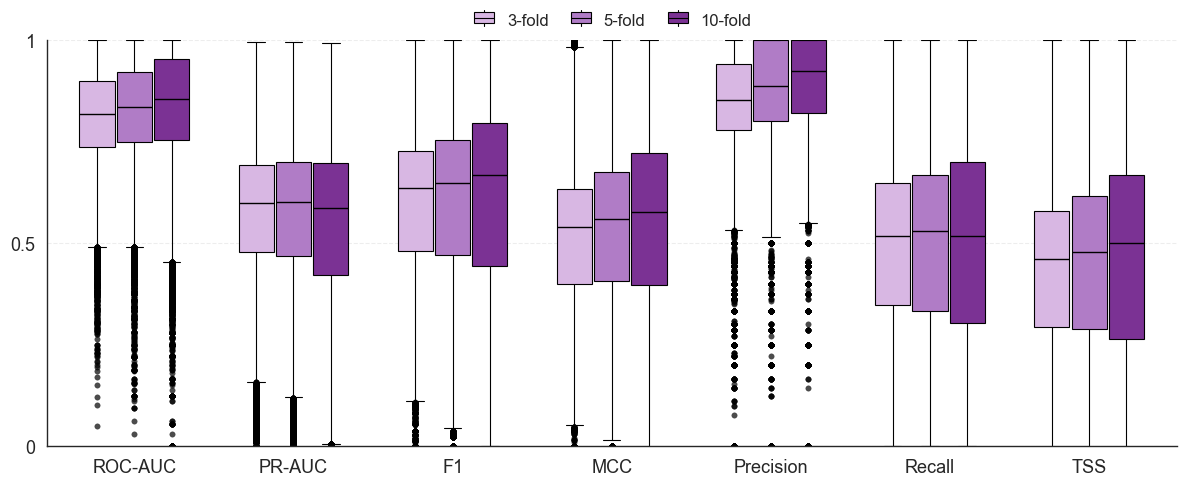

In [37]:
import glob
import re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

sns.set_context("paper", font_scale=1.15)
sns.set_style("white")

# -----------------------------
# Config
# -----------------------------
LOG_DIR_REL = Path(
    "src/matlab/data/result_wlnm_dir_neg_kfold_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs"
)

# Important: files are named ..._kfold_cvK3.csv, ..._kfold_cvK5.csv, ..._kfold_cvK10.csv
PATTERN = "*tax_mass_results_random_wlnm_dir_neg_kfold*.csv"

K_TARGET = 10
cvk_order = [3, 5, 10]

METRIC_SOURCES = {
    "ROC_AUC": ["ROC_AUC"],
    "PR_AUC": ["PR_AUC"],
    "F1Score": ["F1Score", "TestF1Score", "PseudoF1Score"],
    "TestMCC": ["TestMCC", "PseudoMCC"],
    "Precision": ["Precision", "TestPrecision", "PseudoPrecision"],
    "Recall": ["Recall", "TestRecall", "PseudoRecall"],
    "TestTSS": ["TestTSS", "PseudoTSS"],
}

METRICS = list(METRIC_SOURCES.keys())

plot_metrics = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]


def resolve_log_dir(rel_path: Path) -> Path:
    rel_path = Path(rel_path)

    if rel_path.is_absolute():
        return rel_path

    for base in (Path.cwd(), *Path.cwd().parents):
        candidate = base / rel_path
        if candidate.is_dir():
            return candidate.resolve()

    return (Path.cwd() / rel_path).resolve()


LOG_DIR = resolve_log_dir(LOG_DIR_REL)


def cvk_label(k: int) -> str:
    return f"{k}-fold"


def foodweb_name_from_path(p: str) -> str:
    name = Path(p).name
    return re.sub(
        r"_tax_mass_results_random_wlnm_dir_neg_kfold(?:_cvK\d+)?\.csv$",
        "",
        name,
    )


def find_metric_columns(df: pd.DataFrame):
    selected = {}
    missing = []

    for metric, candidates in METRIC_SOURCES.items():
        source_col = next((col for col in candidates if col in df.columns), None)

        if source_col is None:
            missing.append(f"{metric} ({' / '.join(candidates)})")
        else:
            selected[metric] = source_col

    return selected, missing

def collect_foodweb_means(log_dir: Path, pattern: str) -> pd.DataFrame:
    expected_cols = ["CvK", "CvK_label", "Foodweb", "Run", *METRICS]

    rows = []
    csv_files = sorted(glob.glob(str(Path(log_dir) / pattern)))

    print(f"Using LOG_DIR: {log_dir}")
    print(f"Found {len(csv_files)} CSV files matching pattern: {pattern}")

    if not csv_files:
        return pd.DataFrame(columns=expected_cols)

    for csv_path in csv_files:
        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"[SKIP] {Path(csv_path).name} read error: {e}")
            continue

        if "CvK" not in df.columns:
            print(f"[SKIP] {Path(csv_path).name} missing column: CvK")
            continue

        metric_sources, missing_metrics = find_metric_columns(df)
        if missing_metrics:
            print(f"[SKIP] {Path(csv_path).name} missing metrics: {missing_metrics}")
            continue

        df = df.copy()
        df["CvK"] = pd.to_numeric(df["CvK"], errors="coerce")

        if "K" in df.columns:
            df["K"] = pd.to_numeric(df["K"], errors="coerce")
            df = df[df["K"] == K_TARGET].copy()

        df = df[df["CvK"].isin(cvk_order)].copy()

        if df.empty:
            print(f"[SKIP] {Path(csv_path).name} no rows after K/CvK filtering.")
            continue

        for metric, source_col in metric_sources.items():
            df[metric] = pd.to_numeric(df[source_col], errors="coerce")

        # Keep each repeated run instead of averaging the 20 runs per food web.
        # Expected rows per CvK: 290 food webs × 20 runs = 5800 observations.
        df["CvK"] = df["CvK"].astype("Int64")
        df["Foodweb"] = foodweb_name_from_path(csv_path)
        df["Run"] = df.groupby("CvK").cumcount() + 1

        rows.append(df[["CvK", "Foodweb", "Run", *METRICS]].copy())

    if not rows:
        return pd.DataFrame(columns=expected_cols)

    out = pd.concat(rows, ignore_index=True)

    cvk_to_label = {k: cvk_label(k) for k in cvk_order}
    out["CvK_label"] = out["CvK"].map(cvk_to_label)

    return out[expected_cols]

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


def plot_foodweb_means_1x4(df_means: pd.DataFrame) -> None:
    if df_means.empty:
        print("No data to plot.")
        return

    present_cvks = [k for k in cvk_order if (df_means["CvK"] == k).any()]

    if len(present_cvks) < 2:
        print("Not enough CV regimes present to plot.")
        return

    cvk_palette = {
        3: "#D8B7E3",
        5: "#B07CC6",
        10: "#7B3294",
    }

    label_map = {
        3: "3-fold",
        5: "5-fold",
        10: "10-fold",
    }

    fig, ax = plt.subplots(figsize=(12, 5))

    group_gap = 1.45
    group_centers = 1.0 + np.arange(len(plot_metrics)) * group_gap

    offsets = np.linspace(-0.34, 0.34, len(present_cvks))
    box_width = 0.32

    for j, cvk in enumerate(present_cvks):
        data_for_cvk = []
        positions_for_cvk = []
        metrics_for_boxes = []

        for i, (metric, _) in enumerate(plot_metrics):
            vals = df_means.loc[df_means["CvK"] == cvk, metric].dropna().values

            if len(vals) == 0:
                continue

            data_for_cvk.append(vals)
            positions_for_cvk.append(group_centers[i] + offsets[j])
            metrics_for_boxes.append(metric)

        if not data_for_cvk:
            continue

        bp = ax.boxplot(
            data_for_cvk,
            positions=positions_for_cvk,
            widths=box_width,
            patch_artist=True,
            manage_ticks=False,
            showfliers=True,
            boxprops=dict(edgecolor="black", linewidth=0.8),
            medianprops=dict(color="black", linewidth=1.0),
            whiskerprops=dict(color="black", linewidth=0.8),
            capprops=dict(color="black", linewidth=0.8),
            flierprops=dict(
                marker="o",
                markersize=4,
                markerfacecolor="black",
                markeredgecolor="black",
                markeredgewidth=0.2,
                alpha=0.7,
            ),
        )

        for box in bp["boxes"]:
            box.set_facecolor(cvk_palette[cvk])

    legend_handles = [
        {
            "facecolor": cvk_palette[k],
            "edgecolor": "black",
            "linewidth": 0.8,
        }
        for k in present_cvks
    ]

    ax.set_xlim(group_centers[0] - 0.8, group_centers[-1] + 0.8)
    ax.set_ylim(0, 1.0)

    ax.set_xticks(group_centers)
    ax.set_xticklabels([label for _, label in plot_metrics], ha="center", fontsize=13)

    # ax.set_ylabel("Mean value", fontsize=15)
    ax.set_xlabel("")

    ax.tick_params(axis="y", labelsize=13)
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1"])
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    sns.despine(ax=ax)

    ax.legend(
        handles=legend_handles,
        labels=[label_map[k] for k in present_cvks],
        handler_map={dict: HandlerMiniBoxplot()},
        loc="lower center",
        bbox_to_anchor=(0.5, 1),
        ncol=len(present_cvks),
        frameon=False,
        fontsize=12,
        handlelength=1.5,
        handleheight=0.9,
        handletextpad=0.6,
        borderpad=0.2,
        labelspacing=0.45,
        columnspacing=1.2,
    )

    plt.tight_layout()
    plt.show()


# -----------------------------
# Run
# -----------------------------
df_means = collect_foodweb_means(LOG_DIR, PATTERN)

print("\ndf_means shape:")
print(df_means.shape)

if df_means.empty:
    print("\nNo data collected. Check LOG_DIR, PATTERN, K_TARGET, CvK values, and skipped-file messages above.")
else:
    print("\nFoodweb count per CvK:")
    print(df_means.groupby("CvK")["Foodweb"].nunique())

    plot_foodweb_means_1x4(df_means)

/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_36660/3975381087.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Foodweb"] = os.path.basename(file).split("_results_")[0]


Filtered results by TrainRatio: kept only TrainRatio = 90.
Filtered food webs by size: kept 290 / 290 (>= 0 nodes).

=== Precision median and variance by ecosystem using all runs ===
          EcosystemType  n_foodwebs  n_runs  Precision_Median  Precision_Variance
                  lakes          55    1100            1.0000            0.059589
                 marine         134    2680            0.9412            0.044763
                streams          28     560            0.9818            0.123175
terrestrial aboveground          21     420            0.9231            0.054745
terrestrial belowground          52    1040            0.9217            0.001014

=== Ecosystems with lowest/highest median precision and variance ===
Lowest median precision:  terrestrial belowground (median = 0.9217, variance = 0.001014, n_runs = 1040)
Highest median precision: lakes (median = 1.0, variance = 0.059589, n_runs = 1100)
Lowest variance:          terrestrial belowground (variance = 0.0010

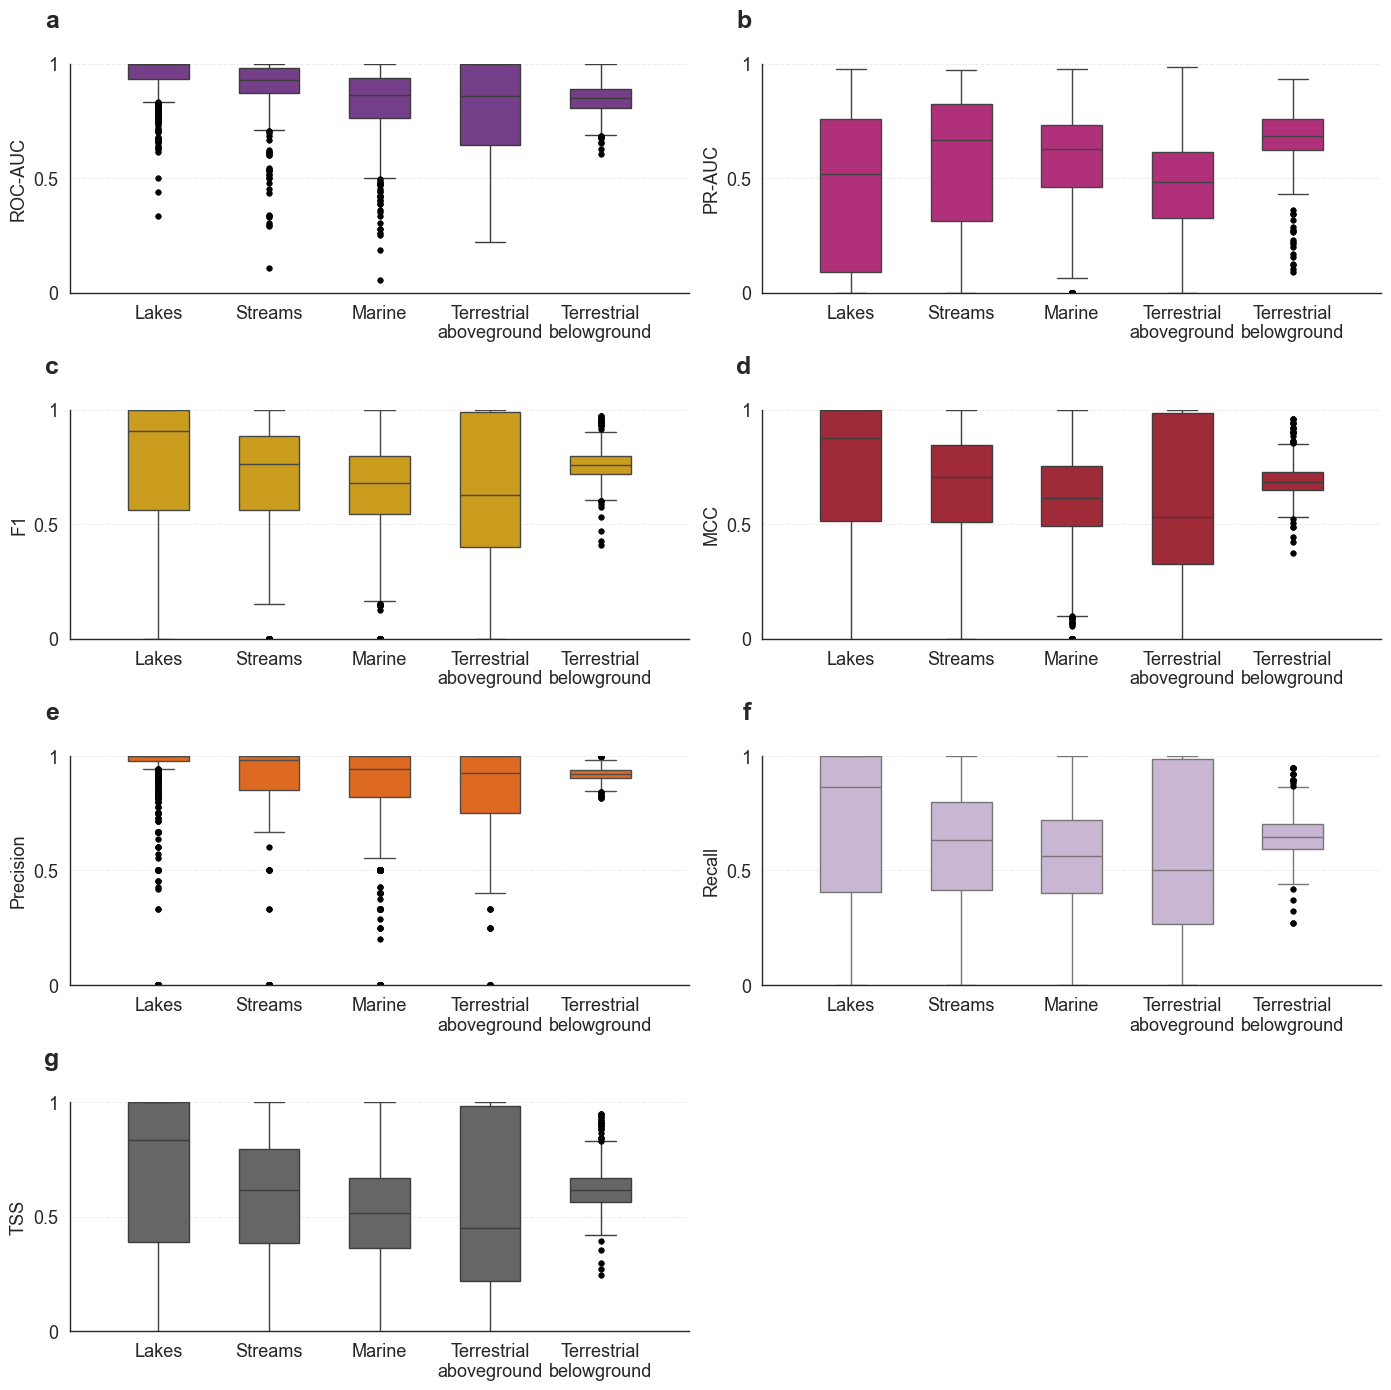

In [39]:
import os
import glob
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")
sns.set_style("white")

# === Paths ===
results_dir = "../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs"
ecosystem_file = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

METRIC_ORDER = ["ROC_AUC", "PR_AUC", "F1Score", "TestMCC", "Precision", "Recall", "TestTSS"]
xtick_labels = ["ROC-AUC", "PR-AUC", "F1", "MCC", "Precision", "Recall", "TSS"]
MIN_NODES = 0
TRAIN_RATIO_TARGET = 90
TRAIN_RATIO_COL = "TrainRatio"
Y_PADDING = 0.02
Y_MIN_FLOOR = 0.5
Y_MAX_CAP = 1.0

metric_palette = {
    "ROC_AUC": "#7B3294",     # purple
    "PR_AUC": "#C51B7D",      # magenta
    "Precision": "#FE6100",   # orange
    "Recall": "#CAB2D6",      # violet
    "F1Score": "#E6AB02",     # mustard
    "TestMCC": "#B2182B",   # deep red / burgundy
    "TestTSS": "#666666",   # dark gray
    "TestTPR": "#1B9E77",   # teal-green
}

metric_label_map = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "F1Score": "F1",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
    "TestTPR": "TPR",
}

# === Load ecosystem metadata ===
df_ecosystem = pd.read_csv(ecosystem_file)

def normalize_colname(s: str) -> str:
    return (
        s.strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )

# Detect node-count column robustly
node_candidates = {"n_nodes", "num_nodes", "nodes", "nodecount", "n", "s"}
norm_map = {normalize_colname(c): c for c in df_ecosystem.columns}
node_col = next((norm_map[k] for k in node_candidates if k in norm_map), None)

if node_col is None:
    raise RuntimeError(
        "Could not find a node-count column in ecosystem metadata. "
        "Please add one (e.g., 'S', 'nodes', 'num_species', 'node_count')."
    )

# === Load result CSVs and stack ===
csv_files = glob.glob(os.path.join(results_dir, "*_mass_results_random_wlnm_dir_neg.csv"))
dfs = []

for file in csv_files:
    df = pd.read_csv(file)
    df["Foodweb"] = os.path.basename(file).split("_results_")[0]
    dfs.append(df)

if not dfs:
    raise RuntimeError("No result CSV found. Check the path or pattern.")

df_all = pd.concat(dfs, ignore_index=True)

# === Filter TrainRatio = 60 before merging/melting ===
if TRAIN_RATIO_COL not in df_all.columns:
    raise RuntimeError(f"Column '{TRAIN_RATIO_COL}' not found in result CSVs.")

df_all[TRAIN_RATIO_COL] = pd.to_numeric(df_all[TRAIN_RATIO_COL], errors="coerce")
df_all = df_all[df_all[TRAIN_RATIO_COL] == TRAIN_RATIO_TARGET].copy()

if df_all.empty:
    raise RuntimeError(
        f"No rows found for {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}. "
        "Check how TrainRatio is stored in the CSV files."
    )

print(f"Filtered results by TrainRatio: kept only {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}.")

# === Merge metrics with ecosystem metadata ===
df_merged = pd.merge(
    df_all,
    df_ecosystem[["Foodweb", "EcosystemType", node_col]],
    on="Foodweb",
    how="left"
)

# === Apply node-count filter ===
before_n = df_merged["Foodweb"].nunique()
df_merged = df_merged[df_merged[node_col] >= MIN_NODES].copy()
after_n = df_merged["Foodweb"].nunique()

print(f"Filtered food webs by size: kept {after_n} / {before_n} (>= {MIN_NODES} nodes).")

# ============================================================
# Precision median by ecosystem: lowest/highest median
# Uses all repeated runs directly: 290 food webs × 20 runs
# ============================================================

if "Precision" not in df_merged.columns:
    raise RuntimeError("Column 'Precision' not found in df_merged.")

df_precision_runs = (
    df_merged
    .dropna(subset=["EcosystemType", "Precision"])
    .copy()
)

precision_summary = (
    df_precision_runs
    .groupby("EcosystemType", as_index=False)
    .agg(
        n_foodwebs=("Foodweb", "nunique"),
        n_runs=("Precision", "count"),
        Precision_Median=("Precision", "median"),
        Precision_Variance=("Precision", lambda x: x.var(ddof=1)),
    )
)

precision_summary["Precision_Median"] = precision_summary["Precision_Median"].round(4)
precision_summary["Precision_Variance"] = precision_summary["Precision_Variance"].round(6)

print("\n=== Precision median and variance by ecosystem using all runs ===")
print(precision_summary.to_string(index=False))

# Identify ecosystems with lowest/highest median precision
lowest_precision = precision_summary.loc[precision_summary["Precision_Median"].idxmin()]
highest_precision = precision_summary.loc[precision_summary["Precision_Median"].idxmax()]

# Identify ecosystems with lowest/highest precision variance
lowest_variance = precision_summary.loc[precision_summary["Precision_Variance"].idxmin()]
highest_variance = precision_summary.loc[precision_summary["Precision_Variance"].idxmax()]

print("\n=== Ecosystems with lowest/highest median precision and variance ===")

print(
    f"Lowest median precision:  {lowest_precision['EcosystemType']} "
    f"(median = {lowest_precision['Precision_Median']}, "
    f"variance = {lowest_precision['Precision_Variance']}, "
    f"n_runs = {lowest_precision['n_runs']})"
)

print(
    f"Highest median precision: {highest_precision['EcosystemType']} "
    f"(median = {highest_precision['Precision_Median']}, "
    f"variance = {highest_precision['Precision_Variance']}, "
    f"n_runs = {highest_precision['n_runs']})"
)

print(
    f"Lowest variance:          {lowest_variance['EcosystemType']} "
    f"(variance = {lowest_variance['Precision_Variance']}, "
    f"median = {lowest_variance['Precision_Median']}, "
    f"n_runs = {lowest_variance['n_runs']})"
)

print(
    f"Highest variance:         {highest_variance['EcosystemType']} "
    f"(variance = {highest_variance['Precision_Variance']}, "
    f"median = {highest_variance['Precision_Median']}, "
    f"n_runs = {highest_variance['n_runs']})"
)

print("\n=== Run-level observations after filtering ===")
print(f"Total rows in df_merged: {len(df_merged)}")
print("Rows per ecosystem:")
print(df_merged.groupby("EcosystemType").size())

# === Prepare long-format data ===
df_plot = df_merged.melt(
    id_vars=["Foodweb", "TrainRatio", "EcosystemType", "Iteration"],
    value_vars=METRIC_ORDER,
    var_name="Metric",
    value_name="Value"
)

df_plot["TrainRatio"] = df_plot["TrainRatio"].astype(str)

# === Preferred ecosystem order ===
preferred_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystems_present = (
    df_merged["EcosystemType"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

eco_lookup = {eco.lower(): eco for eco in ecosystems_present}

ecosystem_order = [
    eco_lookup[eco]
    for eco in preferred_ecosystem_order
    if eco in eco_lookup
]

ecosystem_order += [
    eco for eco in ecosystems_present
    if eco.lower() not in set(preferred_ecosystem_order)
]

# === Panel labels ===
labels_map = (
    df_merged[["Foodweb", "EcosystemType"]]
    .drop_duplicates()
    .groupby("EcosystemType")["Foodweb"]
    .nunique()
    .to_dict()
)
def format_ecosystem_label(eco: str, n: int) -> str:
    eco_clean = str(eco).strip()
    eco_lower = eco_clean.lower()

    label_replacements = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial\naboveground",
        "terrestrial belowground": "Terrestrial\nbelowground",
    }

    label = label_replacements.get(eco_lower, eco_clean.capitalize())
    return f"{label}"

labels_map = {
    eco: format_ecosystem_label(eco, n)
    for eco, n in labels_map.items()
}

# === Data already filtered to TrainRatio = 60 ===
subset = df_plot.copy()

subset["Metric"] = pd.Categorical(
    subset["Metric"],
    categories=METRIC_ORDER,
    ordered=True
)

# === Plot: metric panels, with ecosystems placed next to each other ===
n_panels = len(METRIC_ORDER)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(14, 14),
    sharey=False
)

axes = np.array(axes).reshape(-1)
panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, metric in enumerate(METRIC_ORDER):
    ax = axes[i]
    sub = subset[subset["Metric"] == metric].copy()

    if sub.empty:
        ax.set_axis_off()
        continue

    sns.boxplot(
        data=sub,
        x="EcosystemType",
        y="Value",
        order=ecosystem_order,
        color=metric_palette.get(metric, "#7B3294"),
        legend=False,
        width=0.55,
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
        ax=ax,
    )

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    ax.set_xlabel("")
    ax.set_xticks(range(len(ecosystem_order)))
    ax.set_xticklabels(
        [labels_map.get(eco, eco) for eco in ecosystem_order],
        rotation=0,
        ha="center",
        fontsize=13,
        linespacing=1.1
    )

    ax.set_ylabel(metric_label_map.get(metric, metric), fontsize=13)
    ax.tick_params(axis="y", labelsize=13)
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1"])
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)

    ax.set_xlim(-0.8, len(ecosystem_order) - 1 + 0.8)
    ax.set_ylim(0, 1.0)
    ax.grid(False, axis="x")
    
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[i],
        xy=(0, 1.1),
        xycoords="axes fraction",
        xytext=(-8, 6),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )

# Hide unused axes
for j in range(n_panels, len(axes)):
    axes[j].set_axis_off()

fig.tight_layout(rect=[0, 0, 1, 1], w_pad=1, h_pad=1)
plt.show()

[INFO] Result files found: 290
[INFO] Food webs in result files before filtering: 290
[INFO] Food webs in metadata file: 290
[CHECK] K = 10: 290 -> 290 food webs
[CHECK] TrainRatio = 90.0: 290 -> 290 food webs
[CHECK] Nodes >= 0: 290 -> 290 food webs
[CHECK] available connectance for x-axis: 290 -> 290 food webs
[FINAL] Food webs retained after structural filters: 290

=== OLS linear regression: metric ~ empirical connectance ===
a) ROC-AUC: y = -0.3518x + 0.9138; F1,288 = 8.6305; R² = 0.0291; P = 0.0036; n = 290
b) PR-AUC: y = 1.5263x + 0.3666; F1,288 = 43.4428; R² = 0.1311; P < 0.0001; n = 290
c) F1: y = -0.9380x + 0.8163; F1,288 = 15.2961; R² = 0.0504; P = 0.0001; n = 290
d) MCC: y = -1.1923x + 0.7978; F1,288 = 23.0482; R² = 0.0741; P < 0.0001; n = 290
e) Precision: y = -0.5025x + 0.9415; F1,288 = 6.3947; R² = 0.0217; P = 0.0120; n = 290
f) Recall: y = -1.1585x + 0.7591; F1,288 = 19.4172; R² = 0.0632; P < 0.0001; n = 290
g) TSS: y = -1.3562x + 0.7536; F1,288 = 24.8649; R² = 0.0795; 

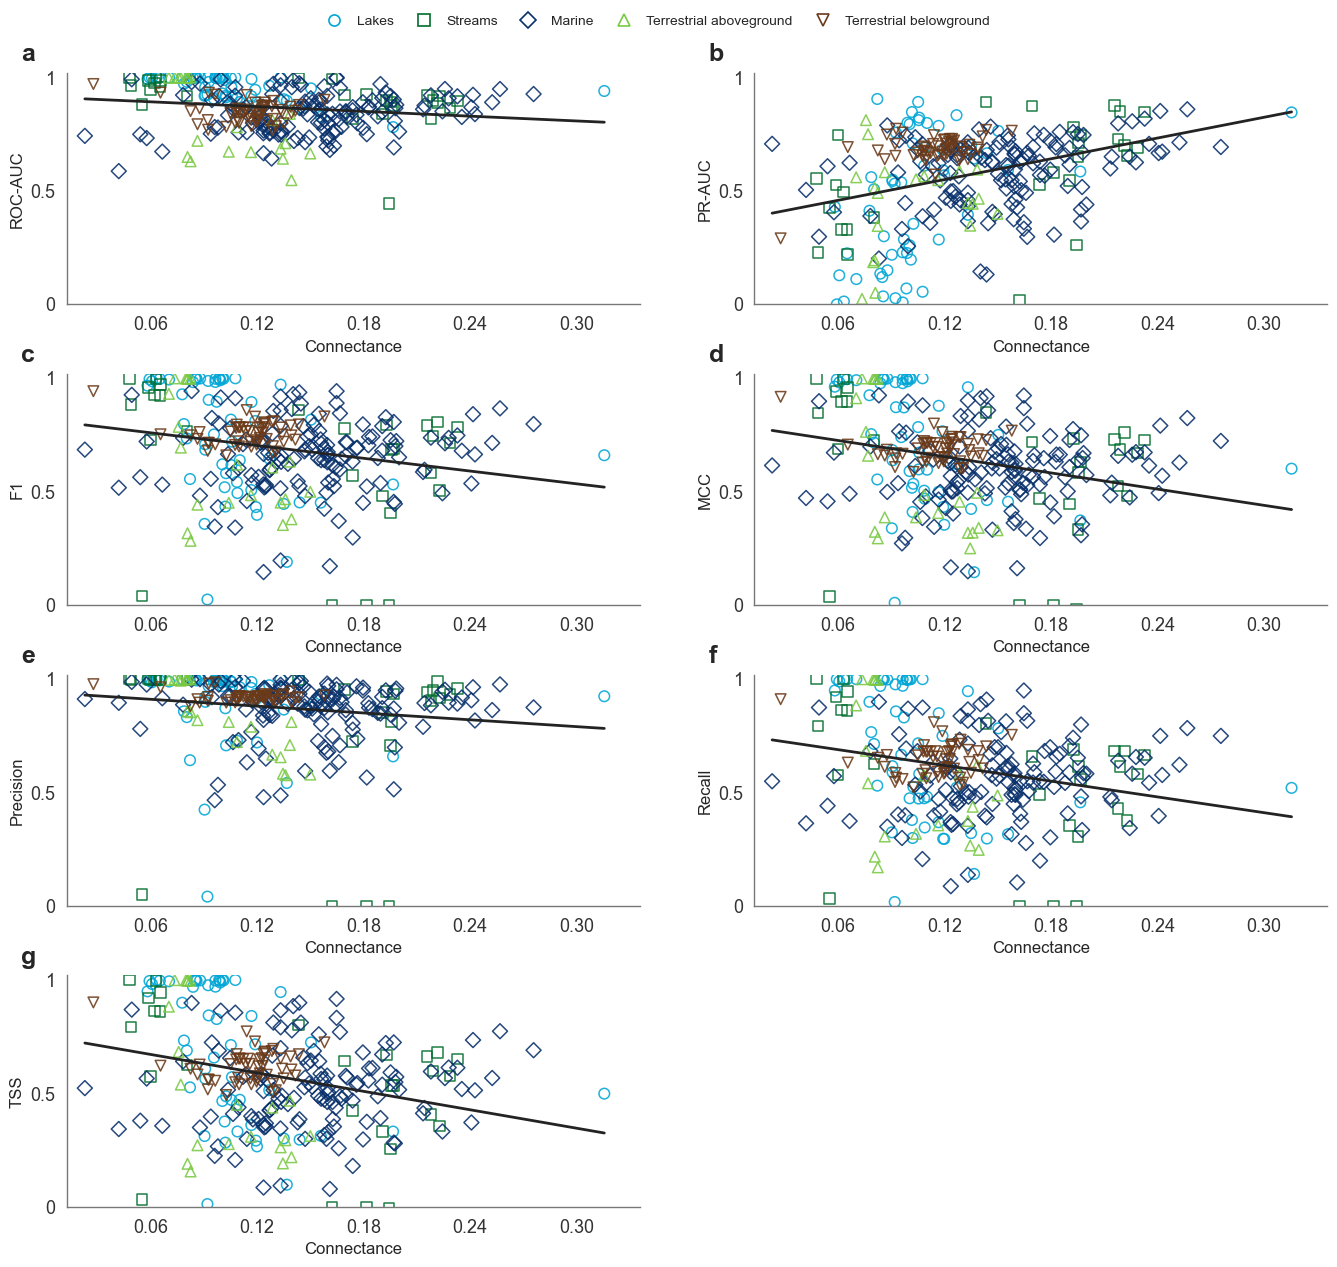

In [54]:
import os
import glob
import math
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "qmul_phd_framework_mplconfig"),
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.lines import Line2D


sns.set_theme(style="white", context="paper", font_scale=1.2)

# ============================================================
# Config
# ============================================================

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()

    for path in [start, *start.parents]:
        if (path / "src/matlab").is_dir() and (path / "docs").is_dir():
            return path

    raise FileNotFoundError("Could not find project root from current working directory.")


PROJECT_ROOT = find_project_root()

RESULTS_DIR = PROJECT_ROOT / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs"
ECOSYSTEM_FILE = PROJECT_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
RESULTS_PATTERN = "*_results_*.csv"

K_TARGET = 10
TARGET_RATIO = 90.0
MIN_NODES = 0
AGGREGATE_REPEATS = True

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

ecosystem_palette = {
    "Lakes": "#00A6D6",
    "Streams": "#006D2C",
    "Marine": "#08306B",
    "Terrestrial aboveground": "#7AC943",
    "Terrestrial belowground": "#6B3A19",
    "Unknown": "#999999",
}

ecosystem_markers = {
    "Lakes": "o",
    "Streams": "s",
    "Marine": "D",
    "Terrestrial aboveground": "^",
    "Terrestrial belowground": "v",
    "Unknown": "x",
}

ECOSYSTEM_ORDER = [
    "Lakes",
    "Streams",
    "Marine",
    "Terrestrial aboveground",
    "Terrestrial belowground",
]

Y_MIN = 0.0
Y_MAX = 1.0
Y_PAD_TOP = 0.02
N_COLS = 2


# ============================================================
# Helpers
# ============================================================

def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb_name(s: str) -> str:
    s = str(s).strip()
    s = s.replace(".mat", "")
    s = s.replace(".csv", "")
    s = s.replace(" ", "_")
    return "_".join(part for part in s.split("_") if part).lower()


def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}

    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]

    raise KeyError(f"Could not find any of these columns: {candidates}")


def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]


def normalize_train_ratio(series):
    values = pd.to_numeric(series, errors="coerce")
    return np.where(values <= 1.0, values * 100.0, values)


def format_ecosystem_label(name: str) -> str:
    name = str(name).strip().lower()

    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial aboveground",
        "terrestrial belowground": "Terrestrial belowground",
        "unknown": "Unknown",
    }

    return label_map.get(name, str(name).strip().capitalize())


def report_foodweb_count(stage_name: str, before: set, after: set) -> None:
    print(f"[CHECK] {stage_name}: {len(before)} -> {len(after)} food webs")


# ============================================================
# Data loading
# ============================================================

def load_results(results_dir: Path, pattern: str) -> pd.DataFrame:
    files = sorted(glob.glob(str(results_dir / pattern)))

    if not files:
        raise FileNotFoundError(
            f"No result CSV files found in {results_dir} matching {pattern}"
        )

    frames = []

    for path in files:
        df = pd.read_csv(path).copy()

        foodweb = extract_foodweb_name(path)
        foodweb_key = normalize_foodweb_name(foodweb)

        file_meta = pd.DataFrame(
            {
                "Foodweb": foodweb,
                "FoodwebKey": foodweb_key,
            },
            index=df.index,
        )

        df = pd.concat([df, file_meta], axis=1).copy()
        frames.append(df)

    # Removed deprecated copy=False argument to avoid Pandas4Warning.
    out = pd.concat(frames, ignore_index=True).copy()

    print(f"[INFO] Result files found: {len(files)}")
    print(f"[INFO] Food webs in result files before filtering: {out['Foodweb'].nunique()}")

    return out


def load_foodweb_metadata(path: Path) -> pd.DataFrame:
    meta = pd.read_csv(path).copy()

    foodweb_col = find_column(meta, ["foodweb"])
    ecosystem_col = find_column(meta, ["ecosystemtype", "ecosystem", "ecosystem_type"])
    nodes_col = find_column(meta, ["nodes", "n_nodes", "num_nodes", "nodecount", "s"])
    edges_col = find_column(meta, ["edges", "n_edges", "num_edges", "edgecount", "l"])
    connectance_col = find_column(meta, ["connectance", "c"])

    meta = meta.rename(
        columns={
            foodweb_col: "MetadataFoodweb",
            ecosystem_col: "EcosystemType",
            nodes_col: "Nodes",
            edges_col: "Edges",
            connectance_col: "MetadataConnectance",
        }
    )

    meta = meta[
        [
            "MetadataFoodweb",
            "EcosystemType",
            "Nodes",
            "Edges",
            "MetadataConnectance",
        ]
    ].copy()

    meta["MetadataFoodweb"] = meta["MetadataFoodweb"].astype(str)
    meta["FoodwebKey"] = meta["MetadataFoodweb"].apply(normalize_foodweb_name)
    meta["EcosystemType"] = meta["EcosystemType"].astype(str).str.strip()
    meta["Nodes"] = pd.to_numeric(meta["Nodes"], errors="coerce")
    meta["Edges"] = pd.to_numeric(meta["Edges"], errors="coerce")
    meta["MetadataConnectance"] = pd.to_numeric(
        meta["MetadataConnectance"],
        errors="coerce",
    )

    meta = meta.drop_duplicates(subset=["FoodwebKey"]).copy()

    print(f"[INFO] Food webs in metadata file: {meta['FoodwebKey'].nunique()}")

    return meta


# ============================================================
# Data preparation
# ============================================================

def prepare_plot_data(results: pd.DataFrame, metadata: pd.DataFrame) -> pd.DataFrame:
    df = results.merge(metadata, on="FoodwebKey", how="left").copy()

    rename_map = {}

    if "ROC_AUC" not in df.columns and "AUC" in df.columns:
        rename_map["AUC"] = "ROC_AUC"

    if "TestMCC" not in df.columns and "MCC" in df.columns:
        rename_map["MCC"] = "TestMCC"

    if rename_map:
        df = df.rename(columns=rename_map).copy()

    numeric_cols = [
        "K",
        "TrainRatio",
        "ROC_AUC",
        "PR_AUC",
        "Precision",
        "Recall",
        "F1Score",
        "TestMCC",
        "TestTSS",
        "TestTPR",
        "EmpiricalConnectance",
        "MetadataConnectance",
        "PseudoTP",
        "PseudoFP",
        "PseudoFN",
        "PseudoTN",
        "Nodes",
        "Edges",
    ]

    existing_numeric_cols = [col for col in numeric_cols if col in df.columns]

    if existing_numeric_cols:
        df[existing_numeric_cols] = df[existing_numeric_cols].apply(
            pd.to_numeric,
            errors="coerce",
        )

    if "TrainRatio" not in df.columns:
        raise RuntimeError("Column 'TrainRatio' not found in result CSVs.")

    df["TrainRatio"] = normalize_train_ratio(df["TrainRatio"])

    if "EmpiricalConnectance" in df.columns:
        df["EmpiricalConnectanceForPlot"] = df["EmpiricalConnectance"].fillna(
            df["MetadataConnectance"]
        )
    else:
        df["EmpiricalConnectanceForPlot"] = df["MetadataConnectance"]

    missing_conn = df["EmpiricalConnectanceForPlot"].isna()
    can_compute_conn = (
        missing_conn
        & df["Nodes"].notna()
        & df["Edges"].notna()
        & (df["Nodes"] > 1)
    )

    df.loc[can_compute_conn, "EmpiricalConnectanceForPlot"] = (
        df.loc[can_compute_conn, "Edges"]
        / (
            df.loc[can_compute_conn, "Nodes"]
            * (df.loc[can_compute_conn, "Nodes"] - 1)
        )
    )

    df["EcosystemType"] = df["EcosystemType"].fillna("Unknown")

    before = set(df["Foodweb"].dropna().unique())

    if K_TARGET is not None:
        df = df[np.isclose(df["K"], K_TARGET, equal_nan=False)].copy()
        after = set(df["Foodweb"].dropna().unique())
        report_foodweb_count(f"K = {K_TARGET}", before, after)
        before = after

    df = df[np.isclose(df["TrainRatio"], TARGET_RATIO, equal_nan=False)].copy()
    after = set(df["Foodweb"].dropna().unique())
    report_foodweb_count(f"TrainRatio = {TARGET_RATIO}", before, after)
    before = after

    if MIN_NODES > 0:
        df = df[df["Nodes"] >= MIN_NODES].copy()
    else:
        df = df[(df["Nodes"] >= MIN_NODES) | df["Nodes"].isna()].copy()

    after = set(df["Foodweb"].dropna().unique())
    report_foodweb_count(f"Nodes >= {MIN_NODES}", before, after)

    missing_metrics = [
        metric
        for metric, _ in METRIC_SPECS
        if metric not in df.columns
    ]

    if missing_metrics:
        raise RuntimeError(f"Missing required metric columns: {missing_metrics}")

    if AGGREGATE_REPEATS:
        group_cols = [
            "Foodweb",
            "FoodwebKey",
            "K",
            "TrainRatio",
            "EmpiricalConnectanceForPlot",
            "Nodes",
            "Edges",
            "EcosystemType",
        ]

        mean_cols = [metric for metric, _ in METRIC_SPECS]

        df = (
            df.groupby(group_cols, dropna=False, as_index=False)[mean_cols]
            .mean()
            .copy()
        )

    df_before_x = set(df["Foodweb"].dropna().unique())
    df = df.dropna(subset=["EmpiricalConnectanceForPlot"]).copy()
    df_after_x = set(df["Foodweb"].dropna().unique())
    report_foodweb_count("available connectance for x-axis", df_before_x, df_after_x)

    metric_cols = [metric for metric, _ in METRIC_SPECS]

    metric_availability = (
        df[["Foodweb", *metric_cols]]
        .assign(HasAnySelectedMetric=lambda x: x[metric_cols].notna().any(axis=1))
        .copy()
    )

    foodwebs_without_metrics = (
        metric_availability.loc[
            ~metric_availability["HasAnySelectedMetric"],
            "Foodweb",
        ]
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    print(f"[FINAL] Food webs retained after structural filters: {df['Foodweb'].nunique()}")

    if foodwebs_without_metrics:
        print(
            "[INFO] Food webs retained but not plotted in metric panels "
            "because all selected metrics are missing:"
        )
        for fw in foodwebs_without_metrics:
            print(f"  - {fw}")

    return df.copy()


# ============================================================
# Regression helpers
# ============================================================

def fit_linear_regression(data: pd.DataFrame, metric: str, n_points: int = 100):
    """
    Fits an OLS linear regression:

        metric ~ EmpiricalConnectanceForPlot

    Returns fitted line coordinates, equation coefficients, R², P-value,
    F-statistic, degrees of freedom, and n.
    """
    work = data[["EmpiricalConnectanceForPlot", metric]].dropna().copy()

    if work.empty:
        return None

    work["EmpiricalConnectanceForPlot"] = work["EmpiricalConnectanceForPlot"].astype(float)
    work[metric] = work[metric].astype(float)

    if len(work) < 3 or work["EmpiricalConnectanceForPlot"].nunique() < 2:
        return None

    x = work[["EmpiricalConnectanceForPlot"]]
    y = work[metric]

    x_model = sm.add_constant(x, has_constant="add")
    model = sm.OLS(y, x_model).fit()

    intercept = model.params["const"]
    slope = model.params["EmpiricalConnectanceForPlot"]

    x_line = np.linspace(
        work["EmpiricalConnectanceForPlot"].min(),
        work["EmpiricalConnectanceForPlot"].max(),
        n_points,
    )

    x_line_model = pd.DataFrame(
        {"EmpiricalConnectanceForPlot": x_line}
    )
    x_line_model = sm.add_constant(x_line_model, has_constant="add")
    y_line = model.predict(x_line_model)

    return {
        "x_line": x_line,
        "y_line": y_line,
        "slope": slope,
        "intercept": intercept,
        "r_squared": model.rsquared,
        "p_value": model.pvalues["EmpiricalConnectanceForPlot"],
        "f_value": model.fvalue,
        "df_model": int(model.df_model),
        "df_resid": int(model.df_resid),
        "n": len(work),
        "model": model,
    }


def format_equation(slope: float, intercept: float) -> str:
    sign = "+" if intercept >= 0 else "-"
    return f"y = {slope:.4f}x {sign} {abs(intercept):.4f}"


def format_p_value(p_value: float) -> str:
    if p_value < 0.0001:
        return "P < 0.0001"
    return f"P = {p_value:.4f}"


# ============================================================
# Plotting
# ============================================================

def style_axes(ax, ylabel: str) -> None:
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Connectance", fontsize=12)
    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#777777")
    ax.spines["bottom"].set_color("#777777")

    ax.tick_params(axis="both", colors="#333333", labelsize=13)


def plot_performance_vs_connectance(plot_df: pd.DataFrame):
    available_ecosystems = (
        plot_df["EcosystemType"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    available_by_label = {
        format_ecosystem_label(eco): eco
        for eco in available_ecosystems
    }

    eco_order = [
        available_by_label[label]
        for label in ECOSYSTEM_ORDER
        if label in available_by_label
    ]

    eco_order += [
        eco
        for eco in available_ecosystems
        if eco not in eco_order
    ]

    plot_df = plot_df.copy()
    plot_df["EcosystemType"] = pd.Categorical(
        plot_df["EcosystemType"],
        categories=eco_order,
        ordered=True,
    )

    eco_palette = {
        eco: ecosystem_palette.get(format_ecosystem_label(eco), "#999999")
        for eco in eco_order
    }

    eco_markers = {
        eco: ecosystem_markers.get(format_ecosystem_label(eco), "o")
        for eco in eco_order
    }

    n_panels = len(METRIC_SPECS)
    n_rows = math.ceil(n_panels / N_COLS)

    fig, axes = plt.subplots(
        n_rows,
        N_COLS,
        # figsize=(12.5, 4.6 * n_rows),
        figsize=(14, 14),
        sharex=False,
        sharey=False,
    )

    axes = np.array(axes).reshape(-1)
    panel_letters = list("abcdefghijklmnopqrstuvwxyz")

    total_foodwebs = plot_df["Foodweb"].nunique()

    x_min = plot_df["EmpiricalConnectanceForPlot"].min()
    x_max = plot_df["EmpiricalConnectanceForPlot"].max()

    print("\n=== OLS linear regression: metric ~ empirical connectance ===")

    for i, ((metric, label), ax) in enumerate(zip(METRIC_SPECS, axes)):
        data = plot_df.dropna(subset=["EmpiricalConnectanceForPlot", metric]).copy()
        n_metric_foodwebs = data["Foodweb"].nunique()

        for eco in eco_order:
            sub = data[data["EcosystemType"] == eco]

            if sub.empty:
                continue

            ax.scatter(
                sub["EmpiricalConnectanceForPlot"],
                sub[metric],
                marker=eco_markers[eco],
                facecolors="none",
                edgecolors=eco_palette[eco],
                linewidths=1.1,
                s=58,
                alpha=0.88,
                label=format_ecosystem_label(eco),
            )

        fit = fit_linear_regression(data, metric)

        if fit is not None:
            ax.plot(
                fit["x_line"],
                fit["y_line"],
                color="#232323",
                linewidth=2.0,
                linestyle="-",
                zorder=5,
            )

            equation = format_equation(fit["slope"], fit["intercept"])
            p_text = format_p_value(fit["p_value"])

            print(
                f"{panel_letters[i]}) {label}: "
                f"{equation}; "
                f"F{fit['df_model']},{fit['df_resid']} = {fit['f_value']:.4f}; "
                f"R² = {fit['r_squared']:.4f}; "
                f"{p_text}; "
                f"n = {fit['n']}"
            )

        else:
            print(
                f"{panel_letters[i]}) {label}: "
                "regression not fitted; insufficient data."
            )

        style_axes(ax, label)

        # ax.set_title(label, loc="left", fontweight="bold", fontsize=12)
        ax.set_ylim(Y_MIN, Y_MAX + Y_PAD_TOP)

        ax.set_xlim(
            max(0.0, x_min - 0.01),
            x_max + 0.02,
        )

        ax.set_yticks([0, 0.5, 1.0])
        ax.set_yticklabels(["0", "0.5", "1"])

        ax.xaxis.set_major_locator(plt.MaxNLocator(6))

        ax.text(
            -0.08,
            1.03,
            panel_letters[i],
            transform=ax.transAxes,
            fontsize=18,
            fontweight="bold",
            va="bottom",
            ha="left",
            clip_on=False,
        )

    for j in range(n_panels, len(axes)):
        axes[j].set_axis_off()

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker=eco_markers[eco],
            linestyle="",
            markersize=8,
            markerfacecolor="none",
            markeredgecolor=eco_palette[eco],
            markeredgewidth=1.2,
            label=format_ecosystem_label(eco),
        )
        for eco in eco_order
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.95),
        ncol=min(len(eco_order), 5),
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,
        fontsize=10,
    )

    fig.subplots_adjust(
        top=0.90,
        hspace=0.3,
        wspace=0.2,
        left=0.08,
        right=0.98,
        bottom=0.09,
    )

    return fig


# ============================================================
# Run
# ============================================================

results = load_results(RESULTS_DIR, RESULTS_PATTERN)
metadata = load_foodweb_metadata(ECOSYSTEM_FILE)
plot_df = prepare_plot_data(results, metadata)

fig = plot_performance_vs_connectance(plot_df)
plt.show()

Filtered data: TrainRatio = 90.0, Nodes >= 0. Rows kept: 5800 / 52200. Food webs kept: 290 / 290.

=== OLS linear regression: metric ~ number of nodes ===
a) ROC-AUC: y = 0.888833 - 0.000335x; F1,288 = 13.5869; R² = 0.0451; P = 0.0003; n = 290
b) PR-AUC: y = 0.544092 + 0.000380x; F1,288 = 4.0626; R² = 0.0139; P = 0.0448; n = 290
c) F1: y = 0.675230 + 0.000262x; F1,288 = 1.9540; R² = 0.0067; P = 0.1632; n = 290
d) MCC: y = 0.619899 + 0.000311x; F1,288 = 2.5030; R² = 0.0086; P = 0.1147; n = 290
e) Precision: y = 0.840109 + 0.000540x; F1,288 = 12.9335; R² = 0.0430; P = 0.0004; n = 290
f) Recall: y = 0.604038 + 0.000027x; F1,288 = 0.0167; R² = 0.0001; P = 0.8972; n = 290
g) TSS: y = 0.562871 + 0.000173x; F1,288 = 0.6416; R² = 0.0022; P = 0.4238; n = 290


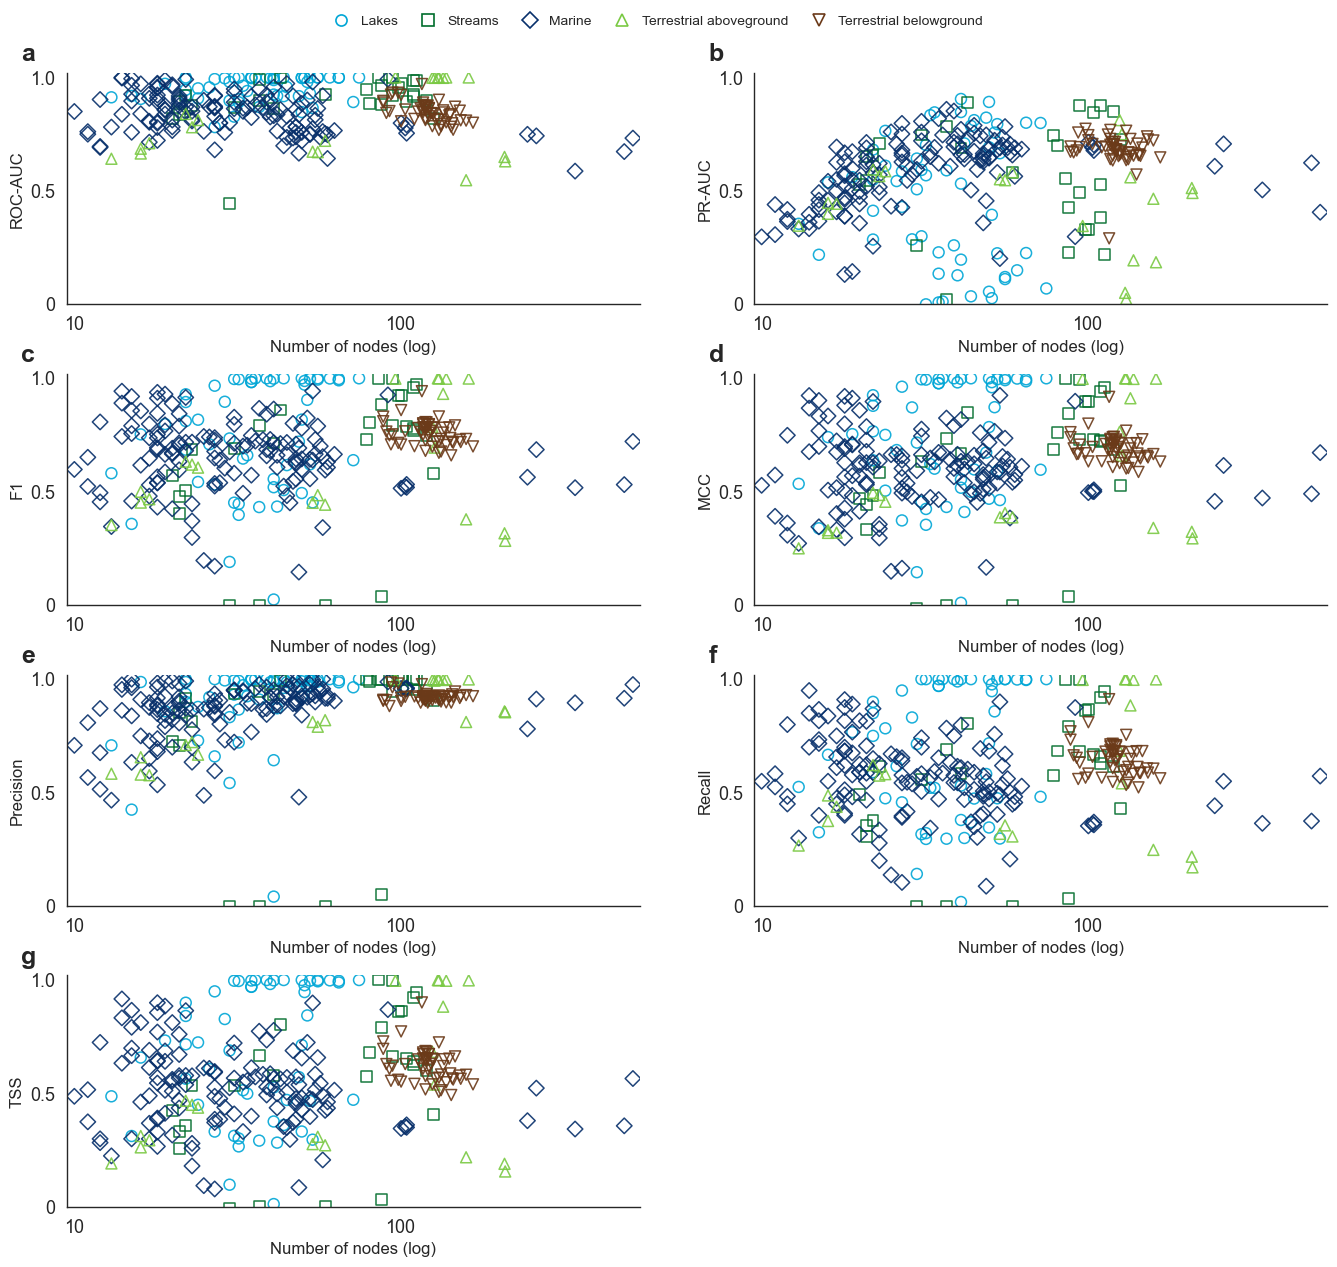

In [62]:
import os
import glob
import math
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "qmul_phd_framework_mplconfig"),
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, ScalarFormatter


sns.set_theme(style="white", context="paper", font_scale=1.2)

# ============================================================
# Config
# ============================================================

RESULTS_DIR = Path(
    "../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs"
)
ECOSYSTEM_FILE = Path(
    "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
)
RESULTS_PATTERN = "*_tax_mass_results_random_wlnm_dir_neg.csv"

TARGET_RATIO = 90.0
MIN_NODES = 0

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

ecosystem_palette = {
    "Lakes": "#00A6D6",
    "Streams": "#006D2C",
    "Marine": "#08306B",
    "Terrestrial aboveground": "#7AC943",
    "Terrestrial belowground": "#6B3A19",
    "Unknown": "#999999",
}

ecosystem_markers = {
    "Lakes": "o",
    "Streams": "s",
    "Marine": "D",
    "Terrestrial aboveground": "^",
    "Terrestrial belowground": "v",
    "Unknown": "x",
}

ECOSYSTEM_ORDER = [
    "Lakes",
    "Streams",
    "Marine",
    "Terrestrial aboveground",
    "Terrestrial belowground",
]

Y_MIN = 0.0
Y_MAX = 1.0
Y_PAD_TOP = 0.02
X_MAX = 550
N_COLS = 2


# ============================================================
# Helpers
# ============================================================

def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb_name(s: str) -> str:
    s = str(s).strip()
    s = s.replace(".mat", "")
    s = s.replace(".csv", "")
    s = s.replace(" ", "_")
    return "_".join(part for part in s.split("_") if part).lower()


def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}

    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]

    raise KeyError(f"Could not find any of these columns: {candidates}")


def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]


def normalize_train_ratio(series):
    values = pd.to_numeric(series, errors="coerce")
    return np.where(values <= 1.0, values * 100.0, values)


def format_ecosystem_label(name: str) -> str:
    name = str(name).strip().lower()

    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial aboveground",
        "terrestrial belowground": "Terrestrial belowground",
        "unknown": "Unknown",
    }

    return label_map.get(name, str(name).strip().capitalize())


def format_p_value(p_value: float) -> str:
    if pd.isna(p_value):
        return "P = NA"
    if p_value < 0.0001:
        return "P < 0.0001"
    return f"P = {p_value:.4f}"


def format_equation(intercept: float, slope: float) -> str:
    sign = "+" if slope >= 0 else "-"
    return f"y = {intercept:.6f} {sign} {abs(slope):.6f}x"


# ============================================================
# Regression helper
# ============================================================

def fit_linear_regression(
    data: pd.DataFrame,
    x_col: str,
    y_col: str,
    n_points: int = 100,
):
    """
    Fits an OLS linear regression:

        y_col ~ x_col

    For this figure:
        metric ~ Nodes

    The x-axis is linear, so Nodes are used directly without log transformation.
    """
    work = data[[x_col, y_col]].dropna().copy()

    if work.empty:
        return None

    work[x_col] = work[x_col].astype(float)
    work[y_col] = work[y_col].astype(float)

    if len(work) < 3 or work[x_col].nunique() < 2:
        return None

    x = work[[x_col]]
    y = work[y_col]

    x_model = sm.add_constant(x, has_constant="add")
    model = sm.OLS(y, x_model).fit()

    intercept = model.params["const"]
    slope = model.params[x_col]

    x_line = np.linspace(
        work[x_col].min(),
        work[x_col].max(),
        n_points,
    )

    x_line_model = pd.DataFrame({x_col: x_line})
    x_line_model = sm.add_constant(x_line_model, has_constant="add")
    y_line = model.predict(x_line_model)

    return {
        "x_line": x_line,
        "y_line": y_line,
        "intercept": intercept,
        "slope": slope,
        "f_value": model.fvalue,
        "df_model": int(model.df_model),
        "df_resid": int(model.df_resid),
        "p_value": model.pvalues[x_col],
        "r_squared": model.rsquared,
        "n": len(work),
        "model": model,
    }


# ============================================================
# Load ecosystem metadata
# ============================================================

df_ecosystem = pd.read_csv(ECOSYSTEM_FILE).copy()

foodweb_col = find_column(df_ecosystem, ["foodweb"])
ecosystem_col = find_column(
    df_ecosystem,
    ["ecosystemtype", "ecosystem", "ecosystem_type"],
)
nodes_col = find_column(
    df_ecosystem,
    ["nodes", "n_nodes", "num_nodes", "nodecount", "s"],
)

df_ecosystem = df_ecosystem.rename(
    columns={
        foodweb_col: "MetadataFoodweb",
        ecosystem_col: "EcosystemType",
        nodes_col: "Nodes",
    }
)

df_ecosystem = df_ecosystem[
    [
        "MetadataFoodweb",
        "EcosystemType",
        "Nodes",
    ]
].copy()

df_ecosystem["MetadataFoodweb"] = df_ecosystem["MetadataFoodweb"].astype(str)
df_ecosystem["FoodwebKey"] = df_ecosystem["MetadataFoodweb"].apply(
    normalize_foodweb_name
)
df_ecosystem["EcosystemType"] = df_ecosystem["EcosystemType"].astype(str).str.strip()
df_ecosystem["Nodes"] = pd.to_numeric(df_ecosystem["Nodes"], errors="coerce")

df_ecosystem = df_ecosystem.drop_duplicates(subset=["FoodwebKey"]).copy()


# ============================================================
# Load results
# ============================================================

csv_files = sorted(glob.glob(str(RESULTS_DIR / RESULTS_PATTERN)))

if not csv_files:
    raise RuntimeError(
        f"No result CSV found in {RESULTS_DIR} matching {RESULTS_PATTERN}"
    )

frames = []

for file in csv_files:
    df = pd.read_csv(file).copy()

    foodweb = extract_foodweb_name(file)
    foodweb_key = normalize_foodweb_name(foodweb)

    file_meta = pd.DataFrame(
        {
            "Foodweb": foodweb,
            "FoodwebKey": foodweb_key,
        },
        index=df.index,
    )

    df = pd.concat([df, file_meta], axis=1).copy()
    frames.append(df)

df_all = pd.concat(frames, ignore_index=True).copy()

if "ROC_AUC" not in df_all.columns and "AUC" in df_all.columns:
    df_all = df_all.rename(columns={"AUC": "ROC_AUC"}).copy()

if "TestMCC" not in df_all.columns and "MCC" in df_all.columns:
    df_all = df_all.rename(columns={"MCC": "TestMCC"}).copy()

missing_metrics = [m for m, _ in METRIC_SPECS if m not in df_all.columns]

if missing_metrics:
    raise RuntimeError(f"Missing required metric columns: {missing_metrics}")


# ============================================================
# Merge + filter
# ============================================================

df_merged = df_all.merge(
    df_ecosystem[["FoodwebKey", "EcosystemType", "Nodes"]],
    on="FoodwebKey",
    how="left",
).copy()

if "TrainRatio" not in df_merged.columns:
    raise RuntimeError("Column 'TrainRatio' not found in result CSVs.")

df_merged["TrainRatio"] = normalize_train_ratio(df_merged["TrainRatio"])
df_merged["Nodes"] = pd.to_numeric(df_merged["Nodes"], errors="coerce")
df_merged["EcosystemType"] = df_merged["EcosystemType"].fillna("Unknown")

numeric_cols = [
    "ROC_AUC",
    "PR_AUC",
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
    "TestTPR",
]

for col in numeric_cols:
    if col in df_merged.columns:
        df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")

before_rows = len(df_merged)
before_foodwebs = df_merged["Foodweb"].nunique()

df_tr = df_merged[
    np.isclose(df_merged["TrainRatio"], TARGET_RATIO, equal_nan=False)
    & (df_merged["Nodes"] >= MIN_NODES)
].copy()

after_rows = len(df_tr)
after_foodwebs = df_tr["Foodweb"].nunique()

print(
    f"Filtered data: TrainRatio = {TARGET_RATIO}, Nodes >= {MIN_NODES}. "
    f"Rows kept: {after_rows} / {before_rows}. "
    f"Food webs kept: {after_foodwebs} / {before_foodwebs}."
)

if df_tr.empty:
    raise RuntimeError(
        f"No rows left after filtering TrainRatio = {TARGET_RATIO} "
        f"and Nodes >= {MIN_NODES}."
    )


# ============================================================
# Mean per food web
# ============================================================

agg_dict = {metric_col: "mean" for metric_col, _ in METRIC_SPECS}

df_scatter = (
    df_tr
    .groupby(["Foodweb", "EcosystemType", "Nodes"], as_index=False)
    .agg(agg_dict)
    .copy()
)

df_scatter = df_scatter.dropna(subset=["Nodes"]).copy()

if df_scatter.empty:
    raise RuntimeError("No data left after grouping by food web.")

x_min = max(1, df_scatter["Nodes"].min() * 0.95)
x_max = min(X_MAX, df_scatter["Nodes"].max() * 1.05)


# ============================================================
# Ecosystem order + palette
# ============================================================

available_ecosystems = (
    df_scatter["EcosystemType"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

available_by_label = {
    format_ecosystem_label(eco): eco
    for eco in available_ecosystems
}

eco_order = [
    available_by_label[label]
    for label in ECOSYSTEM_ORDER
    if label in available_by_label
]

eco_order += [
    eco
    for eco in available_ecosystems
    if eco not in eco_order
]

df_scatter["EcosystemType"] = pd.Categorical(
    df_scatter["EcosystemType"],
    categories=eco_order,
    ordered=True,
)

eco_palette = {
    eco: ecosystem_palette.get(format_ecosystem_label(eco), "#999999")
    for eco in eco_order
}

eco_markers = {
    eco: ecosystem_markers.get(format_ecosystem_label(eco), "o")
    for eco in eco_order
}


# ============================================================
# Plot
# ============================================================

n_panels = len(METRIC_SPECS)
n_rows = math.ceil(n_panels / N_COLS)

fig, axes = plt.subplots(
    n_rows,
    N_COLS,
    figsize=(14, 14),
    sharex=False,
    sharey=False,
)

axes = np.array(axes).reshape(-1)
panel_letters = list("abcdefghijklmnopqrstuvwxyz")
total_foodwebs = df_scatter["Foodweb"].nunique()

print("\n=== OLS linear regression: metric ~ number of nodes ===")

for i, ((metric_col, metric_label), ax) in enumerate(zip(METRIC_SPECS, axes)):
    data = df_scatter.dropna(subset=["Nodes", metric_col]).copy()
    n_metric_foodwebs = data["Foodweb"].nunique()

    for eco in eco_order:
        sub = data[data["EcosystemType"] == eco]

        if sub.empty:
            continue

        ax.scatter(
            sub["Nodes"],
            sub[metric_col],
            marker=eco_markers[eco],
            facecolors="none",
            edgecolors=eco_palette[eco],
            linewidths=1.1,
            s=62,
            alpha=0.9,
            label=format_ecosystem_label(eco),
        )

    fit = fit_linear_regression(data, "Nodes", metric_col)

    if fit is not None:
        # ax.plot(
        #     fit["x_line"],
        #     fit["y_line"],
        #     color="black",
        #     linewidth=2.0,
        #     linestyle="-",
        #     zorder=5,
        # )

        equation = format_equation(fit["intercept"], fit["slope"])
        p_text = format_p_value(fit["p_value"])

        print(
            f"{panel_letters[i]}) {metric_label}: "
            f"{equation}; "
            f"F{fit['df_model']},{fit['df_resid']} = {fit['f_value']:.4f}; "
            f"R² = {fit['r_squared']:.4f}; "
            f"{p_text}; "
            f"n = {fit['n']}"
        )

    else:
        print(
            f"{panel_letters[i]}) {metric_label}: "
            "regression not fitted; insufficient data."
        )

    ax.set_ylabel(metric_label, fontsize=12)
    ax.set_xlabel("Number of nodes (log)", fontsize=12)

    ax.tick_params(axis="x", labelbottom=True, labelsize=13)
    ax.tick_params(axis="y", labelleft=True, labelsize=13)

    ax.set_xscale("log")
    ax.set_xlim(x_min, x_max)

    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(axis="x", style="plain")

    ax.set_ylim(Y_MIN, Y_MAX + Y_PAD_TOP)
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1.0"], fontsize=13)

    sns.despine(ax=ax)

    ax.text(
        -0.08,
        1.03,
        panel_letters[i],
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="bottom",
        ha="left",
        clip_on=False,
    )

for j in range(n_panels, len(axes)):
    axes[j].set_axis_off()


# ============================================================
# Figure-level legend
# ============================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        marker=eco_markers[eco],
        linestyle="",
        markersize=8,
        markerfacecolor="none",
        markeredgecolor=eco_palette[eco],
        markeredgewidth=1.2,
        label=format_ecosystem_label(eco),
    )
    for eco in eco_order
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),
    ncol=min(len(eco_order), 5),
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.4,
    fontsize=10,
)

fig.subplots_adjust(
    top=0.90,
    hspace=0.3,
    wspace=0.2,
    left=0.08,
    right=0.98,
    bottom=0.09,
)

plt.show()